# Robustness & XAI unter CMAPSS‑ähnlichen Störungen (CNN + RandomForest, Binary Classification)

Dieses Notebook ist für **dein eigenes Tabular-Setting** (Features wie `mittelwert_temp`, …; Label `fehler`), aber die **Störungen/Szenarien** sind **analog zu CMAPSS** aufgebaut:

## Szenarien (CMAPSS‑Style)
1. **baseline**: keine Störung (Train/Eval clean)
2. **covariance_shift**: Feature‑Skalierung auf Subset (nur **Eval** auf Shift; Modell bleibt clean)
3. **environmental_shift**: Feature‑Bias auf Subset (nur **Eval** auf Shift; Modell bleibt clean)
4. **model_drift**: zusätzliche Trainingsphase auf drifted Daten (CNN: weitertrainieren; RF: neu trainieren)
5. **catastrophic_forgetting**: Domain A train → Fine‑Tune/Train auf Domain B → Eval auf A und B
6. **underfitting / overfitting**: absichtlich zu simpel / zu komplex bzw. zu wenig Daten

## XAI pro Szenario & Modell
### CNN (Keras)
- Gradients (Batch‑Aggregat) via `tf.GradientTape` (robust, ohne TF‑Explain Abhängigkeit)
- optional: `tf-explain` Integrated Gradients / Vanilla / SmoothGrad (wenn installiert)
- PDP (global, p(y=1))
- LIME (lokal)
- DiCE (counterfactuals, desired_class='opposite') via sklearn‑Wrapper
- Surrogate Tree Rules

### RandomForest (sklearn Pipeline)
- PDP (global)
- LIME (lokal)
- DiCE (CFs) (mit robusten Checks)
- Surrogate Tree Rules

> **Wichtig:** Du musst unten nur `df_base`, `feature_cols`, `label_col` setzen und ggf. `prepare_df(...)` an deine Daten anpassen.


In [1]:
# ============================================================
# 0) Imports (einmal, ohne Redundanz)
#    (aus Diss_CM4B2C_Freshwater-Copy1.ipynb konsolidiert)
# ============================================================
import os
import glob
import re
from typing import Dict, Any, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (aktiviert 3D-Projektion)

from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

import tensorflow as tf
from keras import layers, optimizers, metrics, callbacks
from keras.models import Sequential

import shap
import shap.utils.transformers as shap_tr


C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 1) Config
# ============================================================
CONFIG = {
    "seed": 42,
    "id_col": "point_id",
    "local_point_ids": [398, 1996, 728],

    # Splits
    "train_frac": 0.7,
    "val_frac_within_train": 0.2,

    # CMAPSS-Style Störungen
    "cov_shift_scale": 1.3,
    "cov_shift_frac_features": 0.25,
    "env_shift_bias": 0.5,
    "env_shift_frac_features": 0.30,

    # Model drift
    "drift_extra_epochs": 20,   # CNN: weitertrainieren
    "rf_retrain_on_drift": True,

    # Catastrophic forgetting (Domain B = A + (cov+env shift))
    "forget_ft_epochs": 30,     # CNN fine-tune auf B
    "forget_rf_retrain": True,

    # Under/Overfitting
    "under_single_feature": None,   # z.B. "mittelwert_temp"
    "over_small_train_size": 500,

    # XAI
    # --- SHAP ---
    "shap_explainer": "auto",          # "auto" | "tree" | "kernel" | "deep"
    "shap_task": "classification",     # oder "regression"
    "shap_background_size_global": 1000,   # 1000 Hintergrundstichprobe (global)
    "shap_background_size_local": 200,     # Hintergrundstichprobe (lokal)
    "shap_max_display": 20,            # Top-N Features für globale Plots
    "shap_local_n_points": 20,         # wie viele lokale Punkte erklären (falls nicht über IDs vorgegeben)
    "shap_local_use_fixed_ids": False, # True, wenn du explizit IDs/Indices vorgibst
    "shap_local_id_col": "point_id",   # nur relevant wenn use_fixed_ids=True
    # optional: "shap_local_ids": [...],  # Liste von point_ids / Indices, wenn du fix erklären willst

    # KernelSHAP (nur falls explainer="kernel" bzw. nötig)
    "shap_kernel_nsamples": 200,       # Laufzeit/Qualität Tradeoff
    "shap_kernel_l1_reg": "num_features(10)",

    # --- Saliency Heatmap ---
    "saliency_method": "integrated_gradients",  # "vanilla_gradients" | "integrated_gradients" | "smoothgrad"
    "saliency_target_class": 1,          # bei binärer Klassifikation meist 1
    "saliency_normalize": "minmax",      # "minmax" | "zscore" | None
    "saliency_aggregate": "abs",         # "abs" | "raw" | "pos" (für Heatmap-Aufbereitung)
    "saliency_ig_steps": 32,             # nur IG
    "saliency_smoothgrad_samples": 20,   # nur SmoothGrad
    "saliency_smoothgrad_noise_sigma": 0.1,
    # in CONFIG["xai"] oder flach:
    "saliency_context_k": 5,              # +/- 5 Punkte um die ID
    "saliency_max_display_features": 40,  # Top-K Features pro Plot
    "saliency_max_fig_width": 18,
    "saliency_max_fig_height": 10,


    # --- Prototypes & Criticisms ---
    "proto_method": "kmedoids",          # "kmedoids" (robust, ohne Extra-Libs) oder "random"
    "proto_n_prototypes": 10,
    "proto_n_criticisms": 10,
    "proto_distance": "euclidean",       # "euclidean" | "cosine"
    "proto_candidate_pool_size": 5000,   # max. Kandidaten (subsample) für Geschwindigkeit
    "proto_use_stratified": True,        # bei Klassifikation pro Klasse/Label stratifizieren

    # Criticisms (wenn du MMD-/Kernel-basiert machst)
    "critic_kernel": "rbf",              # "rbf" | "linear"
    "critic_gamma": "scale",             # "scale" | float
}

def ensure_point_id(df: pd.DataFrame, id_col: str = "point_id") -> pd.DataFrame:
    """Adds a stable integer id column if missing. Keeps row order."""
    df = df.copy()
    if id_col not in df.columns:
        df[id_col] = np.arange(len(df), dtype=int)
    return df


def set_seeds(seed: int = 42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(CONFIG["seed"])


In [3]:
# <-- Dein Ordner (laut Ausgabe)
pfad = r"C:\User\OneDrive - fir.rwth-aachen.de\Diss\99_Schreibversionen\Model 4\Daten Fallstudien\Cm4B2C\pressure"

dateien = glob.glob(os.path.join(pfad, "*.txt"))
assert len(dateien) > 0, "Keine Dateien gefunden – Pfad/Endung prüfen."

alle = []
for datei in dateien:
    # 1) Roh einlesen, am ' - ' trennen
    df = pd.read_csv(
        datei,
        sep=r"\s-\s",            # Trennt exakt am " - "
        engine="python",
        header=None,
        names=["zeit", "druck_raw"],
        dtype=str,
        on_bad_lines="skip"
    )

    # 2) Druck als Float aus "... PSI" extrahieren
    df["druck"] = (
        df["druck_raw"]
        .str.extract(r"([0-9]+(?:\.[0-9]+)?)")   # 362.69 aus "362.69 PSI"
        .astype(float)
    )

    # 3) Zeit parsen (deutsches Datum wie 10.7.2025, 12:29:01)
    df["zeit"] = pd.to_datetime(df["zeit"], format="%d.%m.%Y, %H:%M:%S", errors="coerce")

    # 4) Aufräumen & Quelle anhängen
    df = df.dropna(subset=["zeit", "druck"]).copy()
    df["quelle"] = os.path.basename(datei)
    alle.append(df[["zeit", "druck", "quelle"]])

# Zusammenführen
df_press = pd.concat(alle, ignore_index=True)

# Druckfehler markieren und zählen
df_press["druckfehler"] = df_press["druck"] < 340

df_press
# Optional: speichern
# df_press.to_csv(os.path.join(pfad, "pressure_parsed.csv"), index=False)
df = df_press.copy()     # oder: df = df_temp.copy()
wert_col = "druck"       # oder "temp"

# --- 1️⃣ Zeitstempel auf volle Minute runden ---
df["minute"] = df["zeit"].dt.floor("T")

# --- 2️⃣ Gruppieren nach Minute ---
gruppen = df.groupby("minute")[wert_col]

# --- 3️⃣ Kennzahlen berechnen ---
agg_df_press = gruppen.agg([
    "count",           # Anzahl Messungen pro Minute
    "mean",            # Mittelwert
    "median",          # Median
    "std",             # Standardabweichung
    "min", "max",      # Minimum / Maximum
    "skew"             # Schiefe (Skewness)
]).rename(columns={
    "count": "anzahl",
    "mean": "mittelwert",
    "median": "median",
    "std": "stdabw",
    "min": "minimum",
    "max": "maximum",
    "skew": "schiefe"
})

# --- 4️⃣ Quartile separat berechnen und anhängen ---
quartiles = gruppen.quantile([0.25, 0.75]).unstack()
agg_df_press["Q1"] = quartiles[0.25]
agg_df_press["Q3"] = quartiles[0.75]
agg_df_press["IQR"] = agg_df_press["Q3"] - agg_df_press["Q1"]

# --- 5️⃣ Optional: Druckfehler- oder Temperaturfehlerquote pro Minute ---
if "druckfehler" in df.columns:
    fehler = df.groupby("minute")["druckfehler"].mean()
    agg_df_press["fehlerquote"] = fehler * 100
elif "tempfehler" in df.columns:
    fehler = df.groupby("minute")["tempfehler"].mean()
    agg_df_press["fehlerquote"] = fehler * 100

# --- 6️⃣ Ergebnis ---
agg_df_press = agg_df_press.reset_index()
print(agg_df_press.head(10))

agg_df_press["druckfehler"] = (
    (agg_df_press["median"] < 340) |
    (agg_df_press["maximum"] > 400) |
    (agg_df_press["Q3"] > 370)
)

C:\Temp\ipykernel_10768\1863590040.py:48: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df["minute"] = df["zeit"].dt.floor("T")


               minute  anzahl  mittelwert  median      stdabw  minimum  \
0 2025-07-10 12:29:00     117  278.481026   174.0  138.005851    174.0   
1 2025-07-10 12:30:00     120  285.851083   174.0  141.020684    174.0   
2 2025-07-10 12:31:00     120  275.051417   174.0  137.443918    174.0   
3 2025-07-10 12:32:00     120  280.717000   174.0  139.308206    174.0   
4 2025-07-10 12:33:00     119  289.290672   174.0  141.970082    174.0   
5 2025-07-10 12:34:00     120  277.164583   174.0  137.364221    174.0   
6 2025-07-10 12:35:00     120  276.211417   174.0  137.809784    174.0   
7 2025-07-10 12:36:00     120  281.007917   174.0  138.801365    174.0   
8 2025-07-10 12:37:00     119  282.189160   174.0  139.483394    174.0   
9 2025-07-10 12:38:00     120  279.272917   174.0  137.998185    174.0   

   maximum   schiefe     Q1        Q3       IQR  fehlerquote  
0    500.0  0.757341  174.0  439.5700  265.5700    66.666667  
1    500.0  0.649784  174.0  460.7825  286.7825    65.83333

## 2) Daten anschließen

**Du setzt hier deine Variablen:**
- `df_base`: DataFrame mit Features + Label
- `feature_cols`: Liste der Feature-Spalten
- `label_col`: Name der Label-Spalte (bei dir: `"fehler"`)


In [4]:
# ============================================================
# 2) DATA HOOKS: bitte anpassen
# ============================================================
df_base = agg_df_press   # <-- DEIN DataFrame

# exakt die Features, die du fürs NN nutzt
feature_cols = [
    "anzahl",
    "mittelwert",
    "median",
    "stdabw",
    "minimum",
    "maximum",
    "schiefe",
    "Q1",
    "Q3",
    "IQR",
    "fehlerquote",
    # falls du Q1, Q3, IQR usw. *nicht* im Modell hast, hier weglassen!
]

label_col = "druckfehler"



# ============================================================
# UNIVARIAT: genau *ein* Feature auswählen (Variante A)
# - df_base wird auf [point_id?, minute?, <Feature>, <Label>] reduziert
# - feature_cols wird auf genau dieses Feature gesetzt
# ============================================================
UNI_FEATURE_COL = "mittelwert"   # <-- HIER anpassen (z.B. "maximum", "mittelwert", ...)

# Fallback: erstes vorhandenes Feature aus feature_cols
if UNI_FEATURE_COL not in df_base.columns:
    _cands = [c for c in feature_cols if c in df_base.columns]
    if len(_cands) == 0:
        raise ValueError("Keines der feature_cols ist im df_base vorhanden.")
    UNI_FEATURE_COL = _cands[0]

print(f"[Univariat] Verwende Feature: {UNI_FEATURE_COL}")

ID_COL = CONFIG.get("id_col", "point_id")
_keep_cols = [c for c in [ID_COL, "minute", UNI_FEATURE_COL, label_col] if c in df_base.columns]
df_base = df_base[_keep_cols].copy()

# Feature-Liste fürs Modell überschreiben
feature_cols = [UNI_FEATURE_COL]

# ============================================================
# STABILE POINT_ID – MUSS GENAU EINMAL AUSGEFÜHRT WERDEN
# ============================================================
def ensure_point_id(df: pd.DataFrame, id_col="point_id"):
    df = df.copy()
    if id_col not in df.columns:
        df[id_col] = np.arange(len(df), dtype=int)
    return df

def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    """Minimal-Preprocessing. Passe es bei Bedarf an."""
    df = df.copy()
    if label_col in df.columns:
        df[label_col] = df[label_col].astype(int)
    return df
df_base = ensure_point_id(df_base, id_col=CONFIG.get("id_col", "point_id"))
# ============================================================
# FESTE VERGLEICHSPUNKTE (iloc → point_id)
# ============================================================
CONFIG["local_point_ilocs"] = [398, 1996, 728]

[Univariat] Verwende Feature: mittelwert


In [5]:
# ============================================================
# 3) Splits + Scaler (A: clean)
# ============================================================
def split_time_ordered(df: pd.DataFrame, train_frac: float):
    """Zeit-/Reihenfolge-Split (kein Shuffle)."""
    df = df.copy()
    split_idx = int(len(df) * train_frac)
    df_train = df.iloc[:split_idx].copy()
    df_test  = df.iloc[split_idx:].copy()
    return df_train, df_test

def make_train_val(df_train: pd.DataFrame, val_frac: float):
    n = len(df_train)
    split_idx = int(n * (1.0 - val_frac))
    return df_train.iloc[:split_idx].copy(), df_train.iloc[split_idx:].copy()

def make_scaler_from_train(df_train: pd.DataFrame, feature_cols) -> StandardScaler:
    X = df_train[feature_cols].to_numpy().astype("float32")
    scaler = StandardScaler()
    scaler.fit(X)
    return scaler


In [6]:
# ============================================================
# 4) CMAPSS-Style Störungen auf DataFrame (Tabular)
# ============================================================
def _rng(seed: int):
    return np.random.RandomState(seed)

def apply_covariance_shift_df(df: pd.DataFrame, feature_cols, scale=1.3, frac_features=0.25, seed=42):
    rng = _rng(seed)
    df_s = df.copy()
    d = len(feature_cols)
    k = max(1, int(frac_features * d))
    idx = rng.choice(d, size=k, replace=False)
    cols = [feature_cols[i] for i in idx]
    df_s[cols] = df_s[cols] * float(scale)
    return df_s, {"type":"covariance_shift", "scale": float(scale), "cols": cols}

def apply_environmental_shift_df(df: pd.DataFrame, feature_cols, bias=0.5, frac_features=0.30, seed=42):
    rng = _rng(seed)
    df_s = df.copy()
    d = len(feature_cols)
    k = max(1, int(frac_features * d))
    idx = rng.choice(d, size=k, replace=False)
    cols = [feature_cols[i] for i in idx]
    df_s[cols] = df_s[cols] + float(bias)
    return df_s, {"type":"environmental_shift", "bias": float(bias), "cols": cols}

def make_domain_B_from_A(df: pd.DataFrame, feature_cols, seed=42):
    df_b, meta_cov = apply_covariance_shift_df(
        df, feature_cols,
        scale=CONFIG['cov_shift_scale'],
        frac_features=CONFIG['cov_shift_frac_features'],
        seed=seed+1
    )
    df_b, meta_env = apply_environmental_shift_df(
        df_b, feature_cols,
        bias=CONFIG['env_shift_bias'],
        frac_features=CONFIG['env_shift_frac_features'],
        seed=seed+2
    )
    return df_b, {"cov": meta_cov, "env": meta_env}

In [7]:
# ============================================================
# 5) Modelle: DenseNN (Keras) + SVM Pipeline
# ============================================================
# --- Keras Imports robust (tf.keras falls vorhanden, sonst standalone keras) ---
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")  # wichtig, falls Keras 3 installiert ist

try:
    from tensorflow.keras import layers, optimizers, metrics, callbacks
    from tensorflow.keras.models import Sequential
    KERAS_API = "tf.keras"
except ModuleNotFoundError:
    import keras
    from keras import layers, optimizers, metrics, callbacks
    from keras.models import Sequential
    KERAS_API = "keras"

print("✅ Using:", KERAS_API)


def get_class_weight_dict(y: np.ndarray) -> Dict[int, float]:
    """Balanced class weights (für Klassendrift/Imbalance)."""
    y = np.asarray(y).astype(int)
    classes = np.unique(y)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, cw)}


# -------------------------
# DenseNN (Keras)
# -------------------------
def build_dense_model(n_features: int) -> tf.keras.Model:
    model = Sequential([
        layers.Input(shape=(n_features,)),
        layers.BatchNormalization(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[metrics.AUC(name="auc"), metrics.Precision(name="prec"), metrics.Recall(name="rec")],
    )
    return model


def train_dense_on_df(
    df_train: pd.DataFrame,
    scaler: StandardScaler,
    feature_cols,
    label_col: str,
    epochs: int = 200,
    batch_size: int = 32,
    seed: int = 42,
) -> tf.keras.Model:
    set_seeds(seed)

    X_raw = df_train[feature_cols].to_numpy().astype("float32")
    y = df_train[label_col].astype(int).to_numpy()

    X_scaled = scaler.transform(X_raw).astype("float32")

    class_weight_dict = get_class_weight_dict(y)

    model = build_dense_model(X_scaled.shape[1])
    cb = [
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=8, min_lr=1e-5),
    ]
    model.fit(
        X_scaled, y,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        class_weight=class_weight_dict,
        callbacks=cb,
        verbose=0,
    )
    return model


def continue_train_dense(
    model: tf.keras.Model,
    df_train: pd.DataFrame,
    scaler: StandardScaler,
    feature_cols,
    label_col: str,
    extra_epochs: int,
    batch_size: int = 32,
):
    X_raw = df_train[feature_cols].to_numpy().astype("float32")
    y = df_train[label_col].astype(int).to_numpy()
    X_scaled = scaler.transform(X_raw).astype("float32")

    class_weight_dict = get_class_weight_dict(y)

    model.fit(
        X_scaled, y,
        epochs=extra_epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        verbose=0,
    )
    return model


def eval_dense_on_df(
    model: tf.keras.Model,
    df_test: pd.DataFrame,
    scaler: StandardScaler,
    feature_cols,
    label_col: str,
) -> Dict[str, Any]:
    X_raw = df_test[feature_cols].to_numpy().astype("float32")
    y_true = df_test[label_col].astype(int).to_numpy()

    X_scaled = scaler.transform(X_raw).astype("float32")
    proba = model.predict(X_scaled, verbose=0).reshape(-1)
    y_pred = (proba >= 0.5).astype(int)

    return {
        "roc_auc": float(roc_auc_score(y_true, proba)) if len(np.unique(y_true)) > 1 else float("nan"),
        "confusion": confusion_matrix(y_true, y_pred).tolist(),
        "report": classification_report(y_true, y_pred, digits=3, output_dict=True),
        "proba": proba,  # optional: hilfreich für SHAP / Thresholding
    }


# -------------------------
# SVM Pipeline
# -------------------------
def train_svm_pipeline(df_train: pd.DataFrame, feature_cols, label_col: str):
    X = df_train[feature_cols].to_numpy().astype("float32")
    y = df_train[label_col].astype(int).to_numpy()

    svm = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        SVC(kernel="rbf", probability=False, class_weight="balanced", random_state=42),
    )
    svm.fit(X, y)
    return svm


def eval_svm_on_df(svm_pipeline, df_test: pd.DataFrame, feature_cols, label_col: str) -> Dict[str, Any]:
    X = df_test[feature_cols].to_numpy().astype("float32")
    y_true = df_test[label_col].astype(int).to_numpy()

    # Für ROC-AUC ohne probability=True: decision_function nutzen
    if hasattr(svm_pipeline, "decision_function"):
        score = svm_pipeline.decision_function(X)
        # score kann shape (n,) oder (n,2) sein -> bei binär meist (n,)
        score_1d = score.reshape(-1) if np.ndim(score) == 1 else score[:, -1]
    else:
        score_1d = None

    y_pred = svm_pipeline.predict(X)

    return {
        "roc_auc": float(roc_auc_score(y_true, score_1d)) if (score_1d is not None and len(np.unique(y_true)) > 1) else float("nan"),
        "confusion": confusion_matrix(y_true, y_pred).tolist(),
        "report": classification_report(y_true, y_pred, digits=3, output_dict=True),
        "decision_score": score_1d,  # optional: für SHAP / Ranking / Thresholding
    }


✅ Using: keras


In [8]:
# ============================================================
# 6) XAI Bausteine (PDP, LIME, DiCE, Gradients, Rules)
#    FIX: feste lokale Punkte + point_id über alle Szenarien
# ============================================================

# --- Konfiguration für feste lokale Punkte (überall gleich) ---
# Entweder per ilocs (Positionsindizes) ...
FIXED_LOCAL_ILOCS = CONFIG.get("fixed_local_ilocs", [398, 1996, 728])

# ... oder besser/stabiler per festen IDs (point_id), falls du das willst:
# FIXED_LOCAL_IDS = [10, 42, 1337]
FIXED_LOCAL_IDS = CONFIG.get("fixed_local_ids", None)

ID_COL = CONFIG.get("id_col", "point_id")


def _ensure_point_id(df: pd.DataFrame) -> pd.DataFrame:
    """
    Sorgt dafür, dass df einen stabilen point_id hat.
    - Wenn ID_COL schon existiert: behalten (nur casten)
    - Sonst: einmalig aus aktueller Reihenfolge erzeugen (reset_index nur dann)
    """
    df = df.copy()
    if ID_COL not in df.columns:
        df = df.reset_index(drop=True)
        df[ID_COL] = np.arange(len(df), dtype=int)
    else:
        df[ID_COL] = df[ID_COL].astype(int)
    return df


def _resolve_fixed_points(df: pd.DataFrame, label_col: str):
    """
    Liefert:
      - df: ggf. mit point_id
      - points: Liste von Dicts: {point_id, iloc, y_true, status}
      - pairs:  Liste von (point_id, iloc) NUR für gültige Punkte
    """
    df = _ensure_point_id(df)
    n = len(df)

    points = []
    pairs = []

    # --- Variante 1: fixed IDs (empfohlen, stabil bei Shuffle/Splits) ---
    if FIXED_LOCAL_IDS is not None:
        # schneller lookup: point_id -> iloc
        id_to_iloc = {int(pid): int(i) for i, pid in enumerate(df[ID_COL].to_numpy())}

        for pid in FIXED_LOCAL_IDS:
            pid = int(pid)
            if pid not in id_to_iloc:
                points.append({"point_id": pid, "status": "missing_id"})
                continue
            ix = id_to_iloc[pid]
            row = df.iloc[ix]
            y_true = int(row[label_col]) if label_col in df.columns else None
            points.append({"point_id": pid, "iloc": ix, "y_true": y_true, "status": "ok"})
            pairs.append((pid, ix))

        return df, points, pairs

    # --- Variante 2: fixed ilocs (Positionsindizes) ---
    for ix in FIXED_LOCAL_ILOCS:
        ix = int(ix)
        if ix < 0 or ix >= n:
            points.append({"iloc": ix, "status": "invalid_iloc"})
            continue
        row = df.iloc[ix]
        pid = int(row[ID_COL])
        y_true = int(row[label_col]) if label_col in df.columns else None
        points.append({"point_id": pid, "iloc": ix, "y_true": y_true, "status": "ok"})
        pairs.append((pid, ix))

    return df, points, pairs

df_source = df_base        # oder df_base
name = "baseline"
df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)
# ============================================================
# Predict-Wrapper (angepasst auf DenseNN + SVM)
# ============================================================

def nn_predict_proba_raw(model, scaler: StandardScaler, X_raw_2d: np.ndarray) -> np.ndarray:
    """
    DenseNN: erwartet i.d.R. (n, f). Falls das Modell doch 3D erwartet,
    reshapen wir automatisch.
    Rückgabe: (n, 2) mit [P(class0), P(class1)]
    """
    X_scaled = scaler.transform(X_raw_2d.astype("float32")).astype("float32")

    # Auto-reshape falls Modell 3D erwartet (z.B. CNN)
    in_shape = getattr(model, "input_shape", None)
    X_in = X_scaled
    if in_shape is not None and len(in_shape) == 3:
        X_in = X_scaled.reshape(-1, X_scaled.shape[1], 1)

    # Keras predict kompatibel (verbose optional)
    try:
        out = model.predict(X_in, verbose=0)
    except TypeError:
        out = model.predict(X_in)

    out = np.asarray(out)

    # binär: (n,1) -> proba1
    if out.ndim == 2 and out.shape[1] == 1:
        p1 = out.reshape(-1)
    # manchmal (n,) -> proba1
    elif out.ndim == 1:
        p1 = out
    # falls schon (n,2)
    elif out.ndim == 2 and out.shape[1] == 2:
        p0 = out[:, 0]
        p1 = out[:, 1]
        return np.vstack([p0, p1]).T
    else:
        raise ValueError(f"Unerwartete Model-Output-Shape: {out.shape}")

    p1 = np.clip(p1, 0.0, 1.0)
    return np.vstack([1.0 - p1, p1]).T


def svm_predict_proba_raw(svm_pipeline, X_raw_2d: np.ndarray) -> np.ndarray:
    """
    SVM-Pipeline:
    - wenn predict_proba vorhanden: nutzen
    - sonst decision_function -> sigmoid als *Pseudo*-Proba (nicht kalibriert)
    Rückgabe: (n, 2)
    """
    X = X_raw_2d.astype("float32")

    if hasattr(svm_pipeline, "predict_proba"):
        p1 = svm_pipeline.predict_proba(X)[:, 1]
        return np.vstack([1.0 - p1, p1]).T

    if hasattr(svm_pipeline, "decision_function"):
        score = svm_pipeline.decision_function(X)
        score = np.asarray(score).reshape(-1)
        p1 = 1.0 / (1.0 + np.exp(-score))  # sigmoid (pseudo-proba)
        return np.vstack([1.0 - p1, p1]).T

    # Fallback: nur harte Klassen (0/1)
    y_pred = svm_pipeline.predict(X).astype(int)
    p1 = y_pred.astype("float32")
    return np.vstack([1.0 - p1, p1]).T


# -----------------------------
# 0) Config helper
# -----------------------------
def _xai_cfg() -> dict:
    # unterstützt CONFIG["xai"] oder flache Keys
    if "CONFIG" in globals() and isinstance(CONFIG, dict):
        return CONFIG.get("xai", CONFIG)
    return {}

def xget(key: str, default):
    cfg = _xai_cfg()
    return cfg.get(key, default)


def _safe_figsize(n_features_shown: int,
                 base_w=10, base_h=3.5, h_per_feat=0.22,
                 max_w=14, max_h=10):
    """
    Wichtig: Breite NICHT mit Feature-Anzahl skalieren.
    Höhe moderat mit Anzahl (bis 60) skalieren, dann deckeln.
    """
    h = base_h + h_per_feat * min(int(n_features_shown), 60)
    return (min(max_w, base_w), min(max_h, h))


def _topk_feature_indices_from_shap(shap_values, max_display: int):
    vals = shap_values.values if hasattr(shap_values, "values") else shap_values
    vals = np.asarray(vals)
    if vals.ndim == 3:
        vals = vals[..., 0]
    mean_abs = np.mean(np.abs(vals), axis=0)
    k = int(min(max_display, mean_abs.shape[0]))
    idx = np.argsort(-mean_abs)[:k]
    idx = np.sort(idx)
    return idx
# -----------------------------
# 1) Utilities
# -----------------------------
def _subsample_rows(X: np.ndarray, max_n: Optional[int], seed: int) -> np.ndarray:
    if max_n is None or len(X) <= int(max_n):
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=int(max_n), replace=False)
    return X[idx]

def _maybe_model_input(model, X_scaled_2d: np.ndarray) -> np.ndarray:
    """
    DenseNN: (n,d) -> (n,d)
    Falls doch 3D erwartet (CNN): (n,d) -> (n,d,1)
    """
    in_shape = getattr(model, "input_shape", None)
    if in_shape is not None and len(in_shape) == 3:
        return X_scaled_2d.reshape(-1, X_scaled_2d.shape[1], 1)
    return X_scaled_2d


# ============================================================
# 2) SHAP (global + lokal) via KernelExplainer
# ============================================================
def _plot_shap_global_safe(shap_values, X_explain, feature_names, title: str, max_display: int = 30):
    """
    Safe SHAP summary plot:
      - nur Top-K Features
      - subsample bei vielen Samples
      - show=False + close()
    """
    import shap

    max_display = int(max_display)
    idx = _topk_feature_indices_from_shap(shap_values, max_display=max_display)

    X_small = np.asarray(X_explain)[:, idx]
    names_small = [feature_names[i] for i in idx]
    shap_small = shap_values[:, idx] if hasattr(shap_values, "__getitem__") else np.asarray(shap_values)[:, idx]

    if X_small.shape[0] > 800:
        take = np.random.RandomState(0).choice(X_small.shape[0], 800, replace=False)
        X_small = X_small[take]
        shap_small = shap_small[take]

    fig_w, fig_h = _safe_figsize(len(names_small))
    plt.figure(figsize=(fig_w, fig_h), dpi=110)

    try:
        shap.summary_plot(
            shap_small, X_small,
            feature_names=names_small,
            max_display=len(names_small),
            show=False,
            plot_type="dot",
        )
    except Exception:
        plt.clf()
        shap.summary_plot(
            shap_small, X_small,
            feature_names=names_small,
            max_display=len(names_small),
            show=False,
            plot_type="bar",
        )

    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close()


def _plot_shap_local_waterfall_safe(shap_exp_one, title: str, max_display: int = 20):
    import shap

    max_display = int(max_display)
    fig_w, fig_h = _safe_figsize(max_display, base_w=10, base_h=3.5, h_per_feat=0.25)
    plt.figure(figsize=(fig_w, fig_h), dpi=110)

    shap.plots.waterfall(shap_exp_one, max_display=max_display, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close()

# ============================================================
# 2) SHAP (global + lokal) via KernelExplainer  [PATCHED]
# ============================================================
# ============================================================
# PATCH: SHAP plots robust machen (Summary/Dependence/Local)
#  - harte Feature-Caps (unabhängig von CONFIG)
#  - feste plot_size (SHAP skaliert sonst manchmal "auto" riesig)
#  - subsampling (Samples + background)
#  - keine display()-Tabelle, wenn zu groß (oder nur Top-K)
#  - tight_layout vermeiden -> subplots_adjust
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, Dict, Optional

# ============================================================
# FIX: SHAP-Plots stabil für Baseline UND Shifts
# Problem bei Covariance/Environmental Shift:
#   - oft werden Feature-Namen extrem lang / Labels zu viele
#   - SHAP summary/dependence/waterfall erzeugt dann riesige Render-Bounding-Boxes
#   -> Matplotlib: "Image size ... too large"
#
# Maßnahmen (hier direkt eingebaut):
#  1) IMMER harte Caps (Top-K) unabhängig von CONFIG
#  2) Feature-Namen TRUNCATEN (sonst explodiert die Plot-Breite)
#  3) Für Shifts: nur BAR-PLOTS (keine beeswarm/dependence), die sind am stabilsten
#  4) Local: KEIN shap.plots.waterfall mehr, sondern eigenes barh-Plot (Top-K)
#  5) X-Matrix immer über reindex(feature_cols, fill_value=0) -> keine leeren Spalten/KeyErrors
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, Dict, Optional

# ---------- HARD CAPS ----------
SHAP_MAX_DISPLAY_HARD = 20          # global Top-K (baseline)
SHAP_MAX_DISPLAY_SHIFT_HARD = 15    # global Top-K (shift)
SHAP_LOCAL_TOPK_HARD = 12           # local Top-K
SHAP_MAX_SAMPLES_PLOT = 600         # nur fürs plotten
SHAP_PLOT_SIZE = (10, 5)            # feste Figurgröße
SHAP_LOCAL_PLOT_SIZE = (10, 5.5)
SHAP_LOCAL_MAX_DISPLAY_HARD = 20
SHAP_DPI = 110

# ---------- Helpers ----------
def _is_shift_title(title: str) -> bool:
    t = (title or "").lower()
    keys = ["shift", "covariance", "environmental", "model_drift", "catastrophic", "under", "over"]
    return any(k in t for k in keys)

def _safe_feature_names(feature_cols, max_len: int = 45):
    out = []
    for c in feature_cols:
        s = str(c)
        if len(s) > max_len:
            s = s[: max_len - 1] + "…"
        out.append(s.replace("\n", " ").replace("\r", " "))
    return out

def _subsample_rows(X: np.ndarray, max_n: Optional[int], seed: int) -> np.ndarray:
    if max_n is None or len(X) <= int(max_n):
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=int(max_n), replace=False)
    return X[idx]

def _get_X_raw(df_source: pd.DataFrame, feature_cols, fill_value: float = 0.0) -> np.ndarray:
    # WICHTIG: reindex sorgt dafür, dass bei Shifts fehlende Spalten NICHT "leer" bleiben
    Xdf = df_source.reindex(columns=list(feature_cols), fill_value=fill_value)
    return Xdf.to_numpy().astype("float32")

def _topk_idx_from_shap_vals(shap_vals_2d: np.ndarray, k: int) -> np.ndarray:
    imp = np.mean(np.abs(shap_vals_2d), axis=0)
    k = int(min(k, imp.shape[0]))
    idx = np.argsort(-imp)[:k]
    return idx

def _plot_barh_safe(names, values, title: str, figsize, dpi=SHAP_DPI, xlabel=""):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.barh(names[::-1], values[::-1])
    plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    # KEIN tight_layout -> kann bei langen Labels eskalieren
    plt.subplots_adjust(left=0.35, right=0.98, top=0.90, bottom=0.20)
    plt.show()
    plt.close()


# ============================================================
# SHAP GLOBAL (SAFE): nur BAR (Top-K), summary/beeswarm optional AUS
# ============================================================
def run_shap_global(
    predict_proba_raw_fn,
    df_source: pd.DataFrame,
    feature_cols,
    title: str,
    class_index: int = 1,
    seed: int = 42,
) -> Dict[str, Any]:
    import shap

    if feature_cols is None or len(feature_cols) == 0:
        return {"status": "skipped", "reason": "feature_cols empty"}

    is_shift = _is_shift_title(title)
    max_display = SHAP_MAX_DISPLAY_SHIFT_HARD if is_shift else SHAP_MAX_DISPLAY_HARD

    # Sample sizes (bei Shifts konservativer)
    bg_n = int(xget("shap_background_size_global", 200))
    ex_n = int(xget("shap_explain_size_global", 300))
    nsamples = int(xget("shap_kernel_nsamples", 150))
    if is_shift:
        bg_n = min(bg_n, 80)
        ex_n = min(ex_n, 150)

    X_raw = _get_X_raw(df_source, feature_cols, fill_value=0.0)
    X_bg = _subsample_rows(X_raw, bg_n, seed)
    X_ex = _subsample_rows(X_raw, ex_n, seed + 1)

    # Modellfunktion -> p(class_index)
    f = lambda X: np.asarray(predict_proba_raw_fn(np.asarray(X, dtype="float32")))[:, class_index]

    print(f"\n### SHAP GLOBAL SAFE: {title} | shift={is_shift} | bg={len(X_bg)} explain={len(X_ex)} nsamples={nsamples} topK={max_display}")

    explainer = shap.KernelExplainer(f, X_bg)
    shap_vals = np.asarray(explainer.shap_values(X_ex, nsamples=nsamples)).astype("float32")  # (n,d)

    # Top-K Auswahl
    idx = _topk_idx_from_shap_vals(shap_vals, max_display)
    feature_names_safe = _safe_feature_names(feature_cols)
    top_names = [feature_names_safe[i] for i in idx]
    top_vals = np.mean(np.abs(shap_vals[:, idx]), axis=0)

    # Plot: stabiler Bar-Plot
    _plot_barh_safe(
        names=top_names,
        values=top_vals,
        title=f"{title} | SHAP mean(|value|) Top-{len(top_names)}",
        figsize=(9, 5),
        xlabel="mean(|SHAP|)",
    )

    # OPTIONAL: Beeswarm nur in Baseline (wenn du es wirklich willst)
    do_beeswarm = bool(xget("shap_do_beeswarm", False)) and (not is_shift)
    if do_beeswarm:
        # nur Top-K und subsample fürs Plot
        Xp = X_ex[:, idx]
        SVp = shap_vals[:, idx]
        if Xp.shape[0] > SHAP_MAX_SAMPLES_PLOT:
            take = np.random.default_rng(0).choice(Xp.shape[0], SHAP_MAX_SAMPLES_PLOT, replace=False)
            Xp = Xp[take]
            SVp = SVp[take]

        plt.figure(figsize=SHAP_PLOT_SIZE, dpi=SHAP_DPI)
        try:
            shap.summary_plot(
                SVp, Xp,
                feature_names=top_names,
                max_display=len(top_names),
                plot_size=SHAP_PLOT_SIZE,
                show=False,
                plot_type="dot",
            )
            plt.title(f"{title} | SHAP summary (Top-{len(top_names)})")
            plt.subplots_adjust(left=0.32, right=0.98, top=0.90, bottom=0.18)
            plt.show()
        finally:
            plt.close()

    # Speicher nur kompakt (Top-K), sonst bläht das Ergebnis unnötig auf
    imp_df = pd.DataFrame({"feature": top_names, "mean_abs_shap": top_vals}).sort_values("mean_abs_shap", ascending=False)

    return {
        "status": "ok",
        "explainer_type": "KernelExplainer",
        "expected_value": float(np.asarray(explainer.expected_value).reshape(-1)[0]),
        "X_bg_shape": tuple(X_bg.shape),
        "X_ex_shape": tuple(X_ex.shape),
        "meta": {"shift": bool(is_shift), "top_k": int(len(top_names)), "nsamples": int(nsamples)},
        "topk_index": idx.tolist(),
        "importance_df": imp_df.reset_index(drop=True),
        # wenn du SHAP-Werte speichern willst: nur Top-K
        "shap_values_topk": shap_vals[:, idx],
    }


# ============================================================
# SHAP LOCAL (SAFE): eigenes barh Plot (Top-K), KEIN waterfall
# ============================================================
def run_shap_local_fixed_points(
    predict_proba_raw_fn,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    title: str,
    class_index: int = 1,
    seed: int = 42,
) -> Dict[str, Any]:
    import shap

    df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)
    if not pairs:
        return {"status": "skipped", "reason": "no valid fixed points", "local_points": local_points}

    if feature_cols is None or len(feature_cols) == 0:
        return {"status": "skipped", "reason": "feature_cols empty", "local_points": local_points}

    is_shift = _is_shift_title(title)

    bg_n = int(xget("shap_background_size_local", 120))
    nsamples = int(xget("shap_kernel_nsamples", 150))
    if is_shift:
        bg_n = min(bg_n, 60)

    # X immer sauber über reindex holen
    X_raw = _get_X_raw(df_source, feature_cols, fill_value=0.0)

    X_bg = _subsample_rows(X_raw, bg_n, seed)
    f = lambda X: np.asarray(predict_proba_raw_fn(np.asarray(X, dtype="float32")))[:, class_index]
    explainer = shap.KernelExplainer(f, X_bg)
    base = float(np.asarray(explainer.expected_value).reshape(-1)[0])

    feature_names_safe = _safe_feature_names(feature_cols)

    out = {"status": "ok", "title": title, "local_points": local_points, "per_point": {}}
    print(f"\n### SHAP LOCAL SAFE: {title} | shift={is_shift} | bg={len(X_bg)} nsamples={nsamples} topK={SHAP_LOCAL_TOPK_HARD}")

    for pid, ix in pairs:
        x = X_raw[ix:ix+1]  # (1,d)
        sv = np.asarray(explainer.shap_values(x, nsamples=nsamples)).reshape(-1).astype("float32")

        # Top-K lokale Beiträge
        abs_sv = np.abs(sv)
        k = int(min(SHAP_LOCAL_TOPK_HARD, len(abs_sv)))
        top_idx = np.argsort(-abs_sv)[:k]

        names = [feature_names_safe[i] for i in top_idx]
        vals = sv[top_idx]
        values = x.reshape(-1)[top_idx]

        # stabiles lokales Plot: barh nach Betrag sortiert
        order = np.argsort(np.abs(vals))  # klein->groß
        names_o = [names[i] for i in order]
        vals_o = vals[order]

        _plot_barh_safe(
            names=names_o,
            values=vals_o,
            title=f"{title} | Local SHAP (pid={pid}, iloc={ix}) | base={base:.3f}",
            figsize=SHAP_LOCAL_PLOT_SIZE,
            xlabel="SHAP value (signed)",
        )

        # kompakte Tabelle (Top-K) — keine riesige display()-Ausgabe
        contrib = pd.DataFrame({
            "feature": [names[i] for i in range(k)],
            "x_value": values.tolist(),
            "shap": vals.tolist(),
            "abs_shap": np.abs(vals).tolist(),
        }).sort_values("abs_shap", ascending=False).reset_index(drop=True)

        out["per_point"][pid] = {
            "iloc": int(ix),
            "point_id": int(pid),
            "y_true": int(df_source.iloc[ix][label_col]) if label_col in df_source.columns else None,
            "base_value": float(base),
            "top_contrib": contrib,
        }

    return out


# ============================================================
# SHAP LOCAL (fixed points)
# ============================================================
def run_shap_local_fixed_points(
    predict_proba_raw_fn,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    title: str,
    class_index: int = 1,
    seed: int = 42,
) -> Dict[str, Any]:
    import shap

    df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)
    X_raw = df_source[feature_cols].to_numpy().astype("float32")

    bg_n = int(xget("shap_background_size_local", 120))
    nsamples = int(xget("shap_kernel_nsamples", 150))

    # harte Caps
    max_display = int(xget("shap_max_display", 20))
    max_display = int(min(max_display, SHAP_LOCAL_MAX_DISPLAY_HARD))

    top_k = int(xget("shap_local_top_k", 10))
    top_k = int(min(top_k, max_display))

    # WICHTIG: lokale Tabellen nie riesig anzeigen
    show_tables = bool(xget("shap_local_show_tables", False))  # default False

    X_bg = _subsample_rows(X_raw, bg_n, seed)
    f = lambda X: predict_proba_raw_fn(np.asarray(X, dtype="float32"))[:, class_index]

    explainer = shap.KernelExplainer(f, X_bg)
    base = float(np.asarray(explainer.expected_value).reshape(-1)[0])

    out = {"status": "ok", "title": title, "local_points": local_points, "per_point": {}}
    print(f"\n### SHAP LOCAL: {title} | bg={len(X_bg)} nsamples={nsamples} max_display={max_display} top_k={top_k}")

    for pid, ix in pairs:
        x = X_raw[ix:ix+1]

        sv = np.asarray(explainer.shap_values(x, nsamples=nsamples)).reshape(-1).astype(np.float32)

        contrib = (
            pd.DataFrame({
                "feature": list(feature_cols),
                "value": x.reshape(-1),
                "shap": sv,
                "abs_shap": np.abs(sv),
            })
            .sort_values("abs_shap", ascending=False)
            .head(top_k)
            .reset_index(drop=True)
        )

        out["per_point"][pid] = {
            "iloc": int(ix),
            "point_id": int(pid),
            "y_true": int(df_source.iloc[ix][label_col]) if label_col in df_source.columns else None,
            "top_contrib": contrib,  # Top-K only
        }

        if show_tables:
            print(f"\n--- point_id={pid} | iloc={ix} ---")
            display(contrib)

        exp = shap.Explanation(
            values=sv,
            base_values=base,
            data=x.reshape(-1),
            feature_names=list(feature_cols),
        )

        _plot_shap_local_waterfall_safe(
            exp,
            title=f"{title} | SHAP local | pid={pid} (iloc={ix})",
            max_display=max_display,
        )


    # ============================================================
# FIX: Parameter-Mismatch in _plot_shap_local_waterfall_safe
# Ursache:
#   Du hast irgendwo noch den alten Call:
#     _plot_shap_local_waterfall_safe(exp_one=exp, ...)
#   aber die Funktion ist (oder wurde) anders definiert, z.B.:
#     def _plot_shap_local_waterfall_safe(shap_exp_one, ...)
# oder umgekehrt.
#
# Lösung:
#   Definiere eine Wrapper-Funktion, die BEIDE Keyword-Namen akzeptiert.
#   -> Dann ist es egal, welche Version irgendwo aufgerufen wird.
# ============================================================

import matplotlib.pyplot as plt

def _plot_shap_local_waterfall_safe(*args, **kwargs):
    """
    Kompatibilitäts-Wrapper: akzeptiert sowohl exp_one=... als auch shap_exp_one=...
    und ruft dann den eigentlichen Plotter auf.
    """
    # nimm das Explanation-Objekt aus möglichen Keys
    exp = None
    if "exp_one" in kwargs:
        exp = kwargs.pop("exp_one")
    elif "shap_exp_one" in kwargs:
        exp = kwargs.pop("shap_exp_one")
    elif len(args) >= 1:
        exp = args[0]
        args = args[1:]

    if exp is None:
        raise TypeError("Missing SHAP Explanation: provide exp_one=... or shap_exp_one=...")

    # title / max_display
    title = kwargs.pop("title", "SHAP local")
    max_display = int(kwargs.pop("max_display", 20))

    # harte Caps (falls noch nicht existieren)
    hard = globals().get("SHAP_LOCAL_MAX_DISPLAY_HARD", 20)
    max_display = min(max_display, int(hard))

    # Safe plot (ohne tight_layout)
    try:
        import shap
        plt.figure(figsize=(10, 6), dpi=110)
        shap.plots.waterfall(exp, max_display=max_display, show=False)
        plt.title(title)
        plt.subplots_adjust(left=0.25, right=0.98, top=0.90, bottom=0.20)
        plt.show()
    finally:
        plt.close()

    return {"status": "ok", "max_display_used": int(max_display)}

    return out




# ============================================================
# 3) Saliency (Vanilla / IG / SmoothGrad) + Heatmap (für DenseNN)
# ============================================================
def _saliency_vanilla(model, X_in: np.ndarray) -> np.ndarray:
    import tensorflow as tf
    X = tf.convert_to_tensor(X_in, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X)
        p = model(X, training=False)
        p = tf.reshape(p, (-1,))  # p(y=1)
    grads = tape.gradient(p, X)  # same shape as X
    return grads.numpy()

def _saliency_integrated_gradients(model, X_in: np.ndarray, steps: int = 32) -> np.ndarray:
    """
    Integrated Gradients, robust für DenseNN (2D) UND CNN (3D).
    Fix: wir flatten (steps+1, n, ...) -> ((steps+1)*n, ...) bevor wir model() aufrufen,
    damit Dense-Modelle kein 3D Input bekommen.
    """

    X = tf.convert_to_tensor(X_in, dtype=tf.float32)
    baseline = tf.zeros_like(X)

    alphas = tf.linspace(0.0, 1.0, steps + 1)

    # (steps+1, n, d) oder (steps+1, n, d, 1)
    X_interp = baseline[None, ...] + alphas[:, None, None] * (X[None, ...] - baseline[None, ...])

    # ---- FIX: flatten (steps+1, n, ...) -> ((steps+1)*n, ...)
    shp = tf.shape(X_interp)
    s = shp[0]  # steps+1
    n = shp[1]  # batch size (n points)
    rest = X_interp.shape[2:]  # statischer Tail (d) oder (d,1)

    X_flat = tf.reshape(X_interp, (s * n,) + tuple(rest))

    with tf.GradientTape() as tape:
        tape.watch(X_flat)
        p = model(X_flat, training=False)
        p = tf.reshape(p, (s * n,))  # 1D

    grads = tape.gradient(p, X_flat)            # (s*n, ...)
    grads = tf.reshape(grads, (s, n) + tuple(rest))  # zurück: (steps+1, n, ...)

    # trapezoidal mean über steps
    avg_grads = tf.reduce_mean((grads[:-1] + grads[1:]) / 2.0, axis=0)  # (n, ...)
    ig = (X - baseline) * avg_grads
    return ig.numpy()

def _saliency_smoothgrad(model, X_in: np.ndarray, n_samples: int = 20, sigma: float = 0.1) -> np.ndarray:
    rng = np.random.default_rng(42)
    acc = None
    for _ in range(int(n_samples)):
        noise = rng.normal(0.0, sigma, size=X_in.shape).astype("float32")
        g = _saliency_vanilla(model, X_in + noise)
        acc = g if acc is None else (acc + g)
    return acc / float(n_samples)

def run_saliency_context_heatmaps_for_fixed_points(
    model,
    scaler: StandardScaler,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    title: str,
    context_k: int = 5,              # <-- genau "5 davor und 5 danach"
    id_col: str = "point_id",
) -> Dict[str, Any]:
    """
    Saliency für Fixed Points MIT Kontext (±context_k Zeilen).
    Heatmap pro Fixed Point: rows=context rows (davor..center..danach), cols=features.

    Nutzt deine vorhandenen Methoden:
      - vanilla_gradients / smoothgrad / integrated_gradients
      - Aggregation + Normalize + Top-K wie in deiner Originalfunktion
    """
    df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)
    if not pairs:
        return {"status": "skipped", "reason": "no valid fixed points", "local_points": local_points}

    # --- Config (wie bei dir)
    method = str(xget("saliency_method", "integrated_gradients")).lower()
    agg = str(xget("saliency_aggregate", "abs")).lower()
    normalize = xget("saliency_normalize", "minmax")

    max_feat = int(xget("saliency_max_display_features", 40))
    max_fig_w = float(xget("saliency_max_fig_width", 18))
    max_fig_h = float(xget("saliency_max_fig_height", 10))

    # --- gesamte Matrix einmal vorbereiten (schneller)
    X_raw_all = df_source[feature_cols].to_numpy().astype("float32")
    X_scaled_all = scaler.transform(X_raw_all).astype("float32")

    per_point = {}

    for pid, ix in pairs:
        lo = max(0, ix - int(context_k))
        hi = min(len(df_source) - 1, ix + int(context_k))
        ctx_idx = list(range(lo, hi + 1))
        center_pos = int(ix - lo)

        # --- Kontext-Batch (rows=context, cols=features)
        X_ctx = X_scaled_all[ctx_idx, :]
        X_in = _maybe_model_input(model, X_ctx)

        # --- Saliency berechnen (Batch)
        if method == "vanilla_gradients":
            sal = _saliency_vanilla(model, X_in)
        elif method == "smoothgrad":
            sal = _saliency_smoothgrad(
                model,
                X_in,
                n_samples=int(xget("saliency_smoothgrad_samples", 20)),
                sigma=float(xget("saliency_smoothgrad_noise_sigma", 0.1)),
            )
        else:
            sal = _saliency_integrated_gradients(
                model,
                X_in,
                steps=int(xget("saliency_ig_steps", 32)),
            )

        sal = np.asarray(sal)
        if sal.ndim == 3 and sal.shape[-1] == 1:
            sal = sal[..., 0]  # (context_len, d)

        # --- Aggregation
        if agg == "abs":
            sal = np.abs(sal)
        elif agg == "pos":
            sal = np.maximum(sal, 0.0)

        # --- Normalize per row (wie bei dir)
        H = sal.copy()
        if normalize == "minmax":
            mn = H.min(axis=1, keepdims=True)
            mx = H.max(axis=1, keepdims=True)
            H = (H - mn) / (mx - mn + 1e-9)
        elif normalize == "zscore":
            mu = H.mean(axis=1, keepdims=True)
            sd = H.std(axis=1, keepdims=True) + 1e-9
            H = (H - mu) / sd

        # --- Top-K Features (pro Fixed Point, basierend auf Kontext)
        if H.shape[1] > max_feat:
            feat_score = H.mean(axis=0)
            top_idx = np.argsort(-feat_score)[:max_feat]
            top_idx = np.sort(top_idx)  # optional: Originalreihenfolge
            H_plot = H[:, top_idx]
            feat_plot = [feature_cols[i] for i in top_idx]
        else:
            H_plot = H
            feat_plot = list(feature_cols)

        # --- y-Labels: du siehst davor/danach sofort
        y_labels = []
        context_pairs = []
        for jpos, j in enumerate(ctx_idx):
            rel = int(j - ix)  # negativ = davor, positiv = danach
            ctx_pid = int(df_source[id_col].iloc[j]) if id_col in df_source.columns else int(j)
            y_labels.append(f"{rel:+d} | pid={ctx_pid} (iloc={j})")
            context_pairs.append({"rel_offset": rel, "point_id": int(ctx_pid), "iloc": int(j)})

        # --- Plot
        w = min(max_fig_w, max(8, 0.35 * len(feat_plot)))
        h = min(max_fig_h, max(3, 2.5 + 0.35 * len(ctx_idx)))

        plt.figure(figsize=(w, h), dpi=100)
        plt.imshow(H_plot, aspect="auto")
        plt.colorbar(label="saliency (normalized)")
        plt.title(f"{title} | pid={pid} (iloc={ix}) | context ±{int(context_k)} | {method}")

        plt.yticks(np.arange(len(ctx_idx)), y_labels)

        step = max(1, len(feat_plot) // 40)
        xt = np.arange(len(feat_plot))
        plt.xticks(xt[::step], [feat_plot[i] for i in xt[::step]], rotation=90)

        # Center-Zeile markieren (damit "0" sofort sichtbar ist)
        plt.axhline(y=center_pos, linewidth=2)

        plt.tight_layout()
        plt.show()
        plt.close()

        per_point[int(pid)] = {
            "status": "ok",
            "method": method,
            "point_id": int(pid),
            "iloc": int(ix),
            "context_k": int(context_k),
            "center_pos": int(center_pos),
            "context_pairs": context_pairs,     # <-- davor/danach explizit
            "y_labels": y_labels,               # <-- Labels wie im Plot
            "heatmap": H_plot.tolist(),         # serialisierbar
            "features_shown": feat_plot,
            "n_features_total": int(len(feature_cols)),
        }

    return {
        "status": "ok",
        "method": method,
        "aggregate": agg,
        "normalize": normalize,
        "pairs": pairs,
        "local_points": local_points,
        "per_point": per_point,  # <-- pro Fixed Point eine Kontext-Heatmap
    }

import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict

def _get_final_estimator_from_pipeline(pipe):
    if hasattr(pipe, "named_steps"):
        return list(pipe.named_steps.values())[-1]
    return pipe

def run_svm_saliency_context_heatmaps_for_fixed_points(
    svm_pipeline,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    title: str,
    context_k: int = 5,
    id_col: str = "point_id",
    top_k: int = 40,
) -> Dict[str, Any]:
    """
    SVM-"Saliency" mit Kontext (±context_k Zeilen) für Fixed Points.

    - Linear-SVM: echte Saliency pro Zeile = |w * x_scaled|  (oder |w| * |x|)
      Heatmap: rows=context rows, cols=top_k Features
    - Nicht-linear (z.B. RBF): skipped (kein direktes Feature-Gradienten-Saliency)

    Erwartet: df_source ist bereits prepare_df()ed und _resolve_fixed_points() kompatibel.
    """

    # fixed points wie bei NN
    df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)
    if not pairs:
        return {"status": "skipped", "reason": "no valid fixed points", "local_points": local_points}

    # final estimator + check linear
    est = _get_final_estimator_from_pipeline(svm_pipeline)
    if not hasattr(est, "coef_"):
        # z.B. RBF SVC -> keine lineare Gewichtung
        return {
            "status": "skipped",
            "reason": "SVM ist nicht linear (kein coef_). Für RBF gibt es keine echte Saliency; nutze SHAP/Permutation.",
            "kernel": getattr(est, "kernel", None),
            "local_points": local_points,
            "pairs": pairs,
        }

    # w: (1,d) oder (k,d) -> binär nehmen wir class 0
    w = np.asarray(est.coef_)
    if w.ndim == 2 and w.shape[0] >= 1:
        w = w[0]
    w = w.reshape(-1).astype(np.float32)

    # Pipeline-Transform: wir möchten in "Model space" arbeiten
    # Falls Pipeline einen Scaler enthält, nutzen wir pipe[:-1].transform
    if hasattr(svm_pipeline, "named_steps") and len(svm_pipeline.named_steps) > 1:
        # alles außer estimator
        pre = list(svm_pipeline.named_steps.values())[:-1]
        # baue eine transform-chain
        def transform(X):
            Xt = X
            for step in pre:
                if hasattr(step, "transform"):
                    Xt = step.transform(Xt)
            return np.asarray(Xt, dtype=np.float32)
    else:
        def transform(X):
            return np.asarray(X, dtype=np.float32)

    X_raw_all = df_source[feature_cols].to_numpy().astype(np.float32)
    X_all = transform(X_raw_all)

    per_point = {}

    for pid, ix in pairs:
        lo = max(0, ix - int(context_k))
        hi = min(len(df_source) - 1, ix + int(context_k))
        ctx_idx = list(range(lo, hi + 1))
        center_pos = int(ix - lo)

        # (context_len, d)
        X_ctx = X_all[ctx_idx, :]

        # lokale saliency je Zeile: |w * x|
        H = np.abs(X_ctx * w[None, :])

        # row-wise normalize (wie NN) für Lesbarkeit
        normalize = str(xget("saliency_normalize", "minmax")).lower()
        Hn = H.copy()
        if normalize == "minmax":
            mn = Hn.min(axis=1, keepdims=True)
            mx = Hn.max(axis=1, keepdims=True)
            Hn = (Hn - mn) / (mx - mn + 1e-9)
        elif normalize == "zscore":
            mu = Hn.mean(axis=1, keepdims=True)
            sd = Hn.std(axis=1, keepdims=True) + 1e-9
            Hn = (Hn - mu) / sd

        # top_k Features nach mean über Kontext
        top_k_eff = int(min(top_k, Hn.shape[1]))
        feat_score = Hn.mean(axis=0)
        top_idx = np.argsort(-feat_score)[:top_k_eff]
        top_idx = np.sort(top_idx)

        H_plot = Hn[:, top_idx]
        feat_plot = [feature_cols[i] for i in top_idx]

        # y-labels: davor/danach sichtbar
        y_labels = []
        context_pairs = []
        for j in ctx_idx:
            rel = int(j - ix)
            ctx_pid = int(df_source[id_col].iloc[j]) if id_col in df_source.columns else int(j)
            y_labels.append(f"{rel:+d} | pid={ctx_pid} (iloc={j})")
            context_pairs.append({"rel_offset": rel, "point_id": int(ctx_pid), "iloc": int(j)})

        # plot (capped)
        max_fig_w = float(xget("saliency_max_fig_width", 18))
        max_fig_h = float(xget("saliency_max_fig_height", 10))
        w_fig = min(max_fig_w, max(8, 0.35 * len(feat_plot)))
        h_fig = min(max_fig_h, max(3, 2.5 + 0.35 * len(ctx_idx)))

        plt.figure(figsize=(w_fig, h_fig), dpi=100)
        plt.imshow(H_plot, aspect="auto")
        plt.colorbar(label="SVM saliency (normalized) = |w*x|")
        plt.title(f"{title} | pid={pid} (iloc={ix}) | context ±{int(context_k)} | linear SVM")
        plt.yticks(np.arange(len(ctx_idx)), y_labels)

        step = max(1, len(feat_plot) // 40)
        xt = np.arange(len(feat_plot))
        plt.xticks(xt[::step], [feat_plot[i] for i in xt[::step]], rotation=90)

        plt.axhline(y=center_pos, linewidth=2)
        plt.tight_layout()
        plt.show()
        plt.close()

        per_point[int(pid)] = {
            "status": "ok",
            "point_id": int(pid),
            "iloc": int(ix),
            "context_k": int(context_k),
            "center_pos": int(center_pos),
            "context_pairs": context_pairs,
            "y_labels": y_labels,
            "features_shown": feat_plot,
            "heatmap": H_plot.tolist(),
            "saliency_type": "linear_|w*x|",
            "kernel": getattr(est, "kernel", "linear/unknown"),
        }

    return {
        "status": "ok",
        "method": "SVM_Saliency",
        "saliency_type": "linear_|w*x|",
        "pairs": pairs,
        "local_points": local_points,
        "per_point": per_point,
    }

# ============================================================
# 4) Prototypes & Criticisms (ohne Extra-Libs)
# ============================================================
def _farthest_first_prototypes(X: np.ndarray, k: int, seed: int = 42) -> List[int]:
    """
    Greedy diverse Prototypes:
      - start random
      - iteratively add point with max distance to nearest selected
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    if k <= 0 or n == 0:
        return []
    k = min(k, n)
    first = int(rng.integers(0, n))
    sel = [first]

    # distances to nearest selected
    d2 = np.sum((X - X[first]) ** 2, axis=1)

    for _ in range(1, k):
        nxt = int(np.argmax(d2))
        sel.append(nxt)
        # update nearest distance
def _farthest_first_prototypes(X: np.ndarray, k: int, seed: int = 42) -> List[int]:
    """
    Greedy diverse Prototypes:
      - start random
      - iteratively add point with max distance to nearest selected
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    if k <= 0 or n == 0:
        return []
    k = min(k, n)

    first = int(rng.integers(0, n))
    sel = [first]

    # squared distance to nearest selected
    d2 = np.sum((X - X[first]) ** 2, axis=1)

    for _ in range(1, k):
        nxt = int(np.argmax(d2))
        sel.append(nxt)
        new_d2 = np.sum((X - X[nxt]) ** 2, axis=1)
        d2 = np.minimum(d2, new_d2)

    return sel


def run_prototypes_criticisms(
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    scaler: Optional[StandardScaler] = None,
    title: str = "Prototypes/Criticisms",
    seed: int = 42,
) -> Dict[str, Any]:
    """
    Prototypes: diverse points (farthest-first) im skalierten Feature-Space.
    Criticisms: Punkte mit größter Distanz zum nächstgelegenen Prototyp.

    Erwartet eine stabile ID-Spalte (ID_COL = CONFIG.get("id_col","point_id")).
    """
    # --- config helper
    def _xai_cfg():
        if "CONFIG" in globals() and isinstance(CONFIG, dict):
            return CONFIG.get("xai", CONFIG)
        return {}
    cfg = _xai_cfg()

    ID_COL = cfg.get("shap_local_id_col", None)  # falls du das so nutzt
    if "CONFIG" in globals() and isinstance(CONFIG, dict):
        ID_COL = CONFIG.get("id_col", ID_COL or "point_id")
    ID_COL = ID_COL or "point_id"

    # ensure id
    df = df_source.copy()
    if ID_COL not in df.columns:
        df = df.reset_index(drop=True)
        df[ID_COL] = np.arange(len(df), dtype=int)
    else:
        df[ID_COL] = df[ID_COL].astype(int)

    X_raw = df[feature_cols].to_numpy().astype("float32")
    y = df[label_col].astype(int).to_numpy() if label_col in df.columns else None

    pool_n = int(cfg.get("proto_candidate_pool_size", 5000))
    use_strat = bool(cfg.get("proto_use_stratified", True))
    n_proto = int(cfg.get("proto_n_prototypes", 10))
    n_crit = int(cfg.get("proto_n_criticisms", 10))

    rng = np.random.default_rng(seed)
    idx_pool = np.arange(len(X_raw))
    if len(idx_pool) > pool_n:
        idx_pool = rng.choice(idx_pool, size=pool_n, replace=False)

    X_pool = X_raw[idx_pool]

    # scaler: wenn nicht gegeben -> fit auf pool
    if scaler is None:
        scaler = StandardScaler().fit(X_pool)

    Xs_pool = scaler.transform(X_pool).astype("float32")

    def pack_indices(global_idx: np.ndarray, sel_local: List[int]) -> List[int]:
        return [int(global_idx[i]) for i in sel_local]

    # --- prototypes
    proto_indices: List[int] = []
    if use_strat and (y is not None) and (len(np.unique(y[idx_pool])) > 1):
        classes = np.unique(y[idx_pool])
        per = max(1, n_proto // len(classes))
        for c in classes:
            mask = (y[idx_pool] == c)
            gidx = idx_pool[mask]
            Xc = Xs_pool[mask]
            if len(Xc) == 0:
                continue
            sel_local = _farthest_first_prototypes(Xc, min(per, len(Xc)), seed + int(c))
            proto_indices.extend(pack_indices(gidx, sel_local))

        # auffüllen falls zu wenig
        if len(proto_indices) < n_proto:
            need = n_proto - len(proto_indices)
            sel_local = _farthest_first_prototypes(Xs_pool, need, seed)
            proto_indices.extend(pack_indices(idx_pool, sel_local))

        proto_indices = proto_indices[:n_proto]
    else:
        sel_local = _farthest_first_prototypes(Xs_pool, n_proto, seed)
        proto_indices = pack_indices(idx_pool, sel_local)

    # --- criticisms: farthest from nearest prototype
    X_all = scaler.transform(X_raw).astype("float32")
    P = X_all[proto_indices]
    nearest_d2 = np.full(len(X_all), np.inf, dtype="float32")
    for p in P:
        d2 = np.sum((X_all - p) ** 2, axis=1)
        nearest_d2 = np.minimum(nearest_d2, d2)

    crit_order = np.argsort(-nearest_d2)
    crit_indices = [int(i) for i in crit_order[:n_crit]]

    def to_records(indices: List[int]) -> List[Dict[str, Any]]:
        recs = []
        for ix in indices:
            row = df.iloc[ix]
            recs.append({
                "point_id": int(row[ID_COL]),
                "iloc": int(ix),
                "y_true": int(row[label_col]) if label_col in df.columns else None,
            })
        return recs

    print(f"\n### {title} | protos={len(proto_indices)} crits={len(crit_indices)} pool={len(idx_pool)}")
    return {
        "status": "ok",
        "prototypes": to_records(proto_indices),
        "criticisms": to_records(crit_indices),
        "proto_indices": proto_indices,
        "crit_indices": crit_indices,
        "meta": {"pool_n": int(len(idx_pool)), "id_col": ID_COL},
    }
# ---------------------------
# Under/Overfitting helpers (CMAPSS-analog)
# ---------------------------
def make_underfitting_view(df: pd.DataFrame, feature_cols, single_feature: str, ref_df: pd.DataFrame) -> pd.DataFrame:
    """Alle Features bleiben, aber nur single_feature variiert; Rest konstant (Mittelwert aus ref_df)."""
    df_u = df.copy()
    means = ref_df[feature_cols].mean(numeric_only=True)
    for c in feature_cols:
        if c != single_feature:
            df_u[c] = means[c]
    return df_u

def get_under_over_train_val(
    df: pd.DataFrame,
    feature_cols,
    label_col: str,
    train_frac: float = 0.7,
    small_train_size: int = 500,
    single_feature: Optional[str] = None,
    min_per_class: int = 1,
) -> Dict[str, Any]:
    """Erzeugt Under-/Overfitting-Splits im CMAPSS-Stil (zeitliche Reihenfolge),
    aber robust gegen das typische Problem: Wenn in Train oder Test nur eine Klasse
    vorkommt, ist ROC-AUC undefiniert und wird NaN.

    Rückgabe:
      {
        "under": (df_train_under, df_test_under, single_feature),
        "over":  (df_train_over,  df_test_over,  single_feature)
      }
    """
    df = df.reset_index(drop=True)
    y = df[label_col].astype(int).to_numpy()
    n = len(df)

    def _has_both_classes(y_arr: np.ndarray) -> bool:
        if y_arr.size == 0:
            return False
        vals, cnts = np.unique(y_arr, return_counts=True)
        if len(vals) < 2:
            return False
        return all(int(c) >= int(min_per_class) for c in cnts)

    def _find_split_near(target_idx: int, max_shift: int) -> int:
        target_idx = int(np.clip(target_idx, 1, n - 1))
        max_shift = int(max(1, min(max_shift, n - 2)))
        for d in range(0, max_shift + 1):
            for cand in (target_idx - d, target_idx + d):
                if cand <= 1 or cand >= n - 1:
                    continue
                if _has_both_classes(y[:cand]) and _has_both_classes(y[cand:]):
                    return int(cand)
        return int(target_idx)

    # 1) Zeitlicher Split, so dass beide Seiten beide Klassen enthalten
    split0 = int(n * float(train_frac))
    split = _find_split_near(split0, max_shift=max(1000, int(0.1 * n)))

    df_train_base = df.iloc[:split].copy()
    df_test_base  = df.iloc[split:].copy()

    # 2) Underfitting: nur 1 Feature variiert (rest konstant aus Train-Statistiken)
    if single_feature is None:
        single_feature = CONFIG.get("under_single_feature", feature_cols[0])

    df_train_under = make_underfitting_view(
        df_train_base, feature_cols, single_feature=single_feature, ref_df=df_train_base
    )
    df_test_under = make_underfitting_view(
        df_test_base, feature_cols, single_feature=single_feature, ref_df=df_train_base
    )

    # 3) Overfitting: sehr kleines Trainset, aber falls nötig erweitern bis beide Klassen drin sind
    train_end = int(min(max(2, small_train_size), len(df_train_base)))
    while train_end < len(df_train_base) and not _has_both_classes(y[:train_end]):
        train_end += 1
    while train_end < n - 1 and not _has_both_classes(y[:train_end]):
        train_end += 1

    df_train_over = df.iloc[:train_end].copy()
    df_test_over  = df.iloc[train_end:].copy()

    return {
        "under": (df_train_under, df_test_under, single_feature),
        "over":  (df_train_over,  df_test_over,  single_feature),
    }
    
def make_scenarios_like_cmapss(df_train_A: pd.DataFrame, df_test_A: pd.DataFrame, feature_cols) -> Dict[str, Dict[str, Any]]:
    scenarios = {"baseline": {"train": df_train_A, "test": df_test_A, "meta": {}}}

    # ---------------------------
    # Covariance shift (eval-only)
    # ---------------------------
    df_test_cov, meta_cov = apply_covariance_shift_df(
        df_test_A, feature_cols,
        scale=CONFIG["cov_shift_scale"],
        frac_features=CONFIG["cov_shift_frac_features"],
        seed=CONFIG["seed"] + 10
    )
    scenarios["covariance_shift"] = {"train": df_train_A, "test": df_test_cov, "meta": meta_cov}

    # ---------------------------
    # Environmental shift (eval-only)
    # ---------------------------
    df_test_env, meta_env = apply_environmental_shift_df(
        df_test_A, feature_cols,
        bias=CONFIG["env_shift_bias"],
        frac_features=CONFIG["env_shift_frac_features"],
        seed=CONFIG["seed"] + 20
    )
    scenarios["environmental_shift"] = {"train": df_train_A, "test": df_test_env, "meta": meta_env}

    # ---------------------------
    # Model drift (MODEL-only: drifted TRAIN, baseline TEST)
    # ---------------------------
    df_train_drift, meta_cov_tr = apply_covariance_shift_df(
        df_train_A, feature_cols,
        scale=CONFIG["cov_shift_scale"],
        frac_features=CONFIG["cov_shift_frac_features"],
        seed=CONFIG["seed"] + 30
    )
    df_train_drift, meta_env_tr = apply_environmental_shift_df(
        df_train_drift, feature_cols,
        bias=CONFIG["env_shift_bias"],
        frac_features=CONFIG["env_shift_frac_features"],
        seed=CONFIG["seed"] + 31
    )

    # TEST bleibt bewusst unverändert -> wir testen das *Modell* (drifted weights), nicht das Dataset
    scenarios["model_drift"] = {
        "train": df_train_drift,
        "test":  df_test_A,
        "meta": {
            "train": {"cov": meta_cov_tr, "env": meta_env_tr},
            "test":  {"note": "baseline test (no data drift)"},
        },
    }

    # ---------------------------
    # Catastrophic forgetting (Domain B)
    # ---------------------------
    df_train_B, meta_B_tr = make_domain_B_from_A(df_train_A, feature_cols, seed=CONFIG["seed"] + 40)
    df_test_B,  meta_B_te = make_domain_B_from_A(df_test_A,  feature_cols, seed=CONFIG["seed"] + 41)

    scenarios["catastrophic_forgetting"] = {
        "train_A": df_train_A, "test_A": df_test_A,
        "train_B": df_train_B, "test_B": df_test_B,
        "meta": {"B_train": meta_B_tr, "B_test": meta_B_te},
    }

    # ============================================================
    # Underfitting / Overfitting → MODEL-ONLY
    # ============================================================
    df_full_A = pd.concat([df_train_A, df_test_A], axis=0).reset_index(drop=True)

    splits = get_under_over_train_val(
        df=df_full_A,
        feature_cols=feature_cols,
        label_col=label_col,
        train_frac=CONFIG.get("train_frac", 0.7),
        small_train_size=CONFIG.get("over_small_train_size", 500),
        single_feature=CONFIG.get("under_single_feature", None),
    )

    df_train_under, _, sf = splits["under"]
    df_train_over,  _, _  = splits["over"]

    # TESTSET BLEIBT BASELINE!
    scenarios["underfitting"] = {
        "train": df_train_under,
        "test":  df_test_A,
        "meta": {"model_only": True, "single_feature": sf},
    }

    scenarios["overfitting"] = {
        "train": df_train_over,
        "test":  df_test_A,
        "meta": {"model_only": True, "small_train_size": len(df_train_over)},
    }


    return scenarios


In [9]:
# ============================================================
# FINAL "Covariance-Shift safe" SHAP patch
# - verhindert "Image size ... too large" im Inline-Renderer
#   (typisch bei sehr langen Feature-Namen / bbox_inches='tight')
# - erzwingt gekappte Feature-Namen + harte Top-K
# - versucht Summary/Waterfall; fällt bei Render-Fehlern auf Bar-Plots zurück
# ============================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# 1) Inline-Renderer NICHT mit tight-bbox arbeiten lassen (wichtig!)
mpl.rcParams["savefig.bbox"] = "standard"
mpl.rcParams["savefig.pad_inches"] = 0.1

try:
    # Jupyter inline backend: print_figure_kwargs überschreiben
    from matplotlib_inline.backend_inline import InlineBackend
    InlineBackend.instance().print_figure_kwargs = {"bbox_inches": None}
except Exception:
    pass

# 2) Harte Caps
SHAP_MAX_DISPLAY_HARD = 20
SHAP_LOCAL_MAX_DISPLAY_HARD = 15
SHAP_MAX_SAMPLES_PLOT = 600
SHAP_PLOT_SIZE = (10, 5)
SHAP_LOCAL_PLOT_SIZE = (10, 5.5)
SHAP_DPI = 110

def _is_shift_name(name_or_title: str) -> bool:
    t = (name_or_title or "").lower()
    return any(k in t for k in ["covariance", "environmental", "shift", "drift", "catastrophic", "under", "over"])

def _truncate_names(names, max_len: int = 32):
    out=[]
    for s in names:
        s=str(s).replace("\n"," ").replace("\r"," ")
        if len(s) > max_len:
            s = s[:max_len-1] + "…"
        out.append(s)
    return out

def _safe_show():
    try:
        plt.show()
        return True
    except ValueError as e:
        # Matplotlib inline Renderer: extrem große bbox
        if "Image size" in str(e) and "too large" in str(e):
            print("⚠️ SHAP-Plot zu groß für Inline-Renderer -> Fallback auf kompakteren Plot.")
            return False
        raise

def _subsample_rows(X: np.ndarray, max_n: int, seed: int) -> np.ndarray:
    if max_n is None or len(X) <= int(max_n):
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=int(max_n), replace=False)
    return X[idx]

def _get_X_raw(df_source: pd.DataFrame, feature_cols, fill_value: float = 0.0) -> np.ndarray:
    Xdf = df_source.reindex(columns=list(feature_cols), fill_value=fill_value)
    return Xdf.to_numpy().astype("float32")

def _topk_idx(shap_vals_2d: np.ndarray, k: int) -> np.ndarray:
    imp = np.mean(np.abs(shap_vals_2d), axis=0)
    k = int(min(k, imp.shape[0]))
    return np.argsort(-imp)[:k]

def _barh(names, values, title: str, xlabel: str):
    plt.figure(figsize=SHAP_PLOT_SIZE, dpi=SHAP_DPI)
    plt.barh(names[::-1], values[::-1])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.yticks(fontsize=8)
    plt.subplots_adjust(left=0.35, right=0.98, top=0.90, bottom=0.18)
    ok = _safe_show()
    plt.close()
    return ok

def run_shap_global(
    predict_proba_raw_fn,
    df_source: pd.DataFrame,
    feature_cols,
    title: str,
    class_index: int = 1,
    seed: int = 42,
):
    import shap

    is_shift = _is_shift_name(title)
    max_display = SHAP_MAX_DISPLAY_HARD if not is_shift else min(SHAP_MAX_DISPLAY_HARD, 15)

    bg_n = int(xget("shap_background_size_global", 200))
    ex_n = int(xget("shap_explain_size_global", 300))
    nsamples = int(xget("shap_kernel_nsamples", 150))
    if is_shift:
        bg_n = min(bg_n, 80)
        ex_n = min(ex_n, 150)

    X_raw = _get_X_raw(df_source, feature_cols, fill_value=0.0)
    X_bg = _subsample_rows(X_raw, bg_n, seed)
    X_ex = _subsample_rows(X_raw, ex_n, seed + 1)

    f = lambda X: np.asarray(predict_proba_raw_fn(np.asarray(X, dtype="float32")))[:, class_index]

    print(f"\n### SHAP GLOBAL (final safe): {title} | shift={is_shift} | bg={len(X_bg)} explain={len(X_ex)} nsamples={nsamples} topK={max_display}")
    explainer = shap.KernelExplainer(f, X_bg)
    shap_vals = np.asarray(explainer.shap_values(X_ex, nsamples=nsamples)).astype("float32")

    idx = _topk_idx(shap_vals, max_display)
    safe_names = _truncate_names(list(feature_cols), max_len=28 if is_shift else 34)
    top_names = [safe_names[i] for i in idx]
    top_imp = np.mean(np.abs(shap_vals[:, idx]), axis=0)

    # Immer: stabiler Bar-Plot
    _barh(top_names, top_imp, f"{title} | SHAP mean(|value|) Top-{len(top_names)}", "mean(|SHAP|)")

    # Optional: Summary-Plot nur wenn möglich (und NICHT bei Shifts standardmäßig)
    do_summary = bool(xget("shap_do_beeswarm", False)) and (not is_shift)
    if do_summary:
        Xp = X_ex[:, idx]
        SVp = shap_vals[:, idx]
        if Xp.shape[0] > SHAP_MAX_SAMPLES_PLOT:
            take = np.random.default_rng(0).choice(Xp.shape[0], SHAP_MAX_SAMPLES_PLOT, replace=False)
            Xp = Xp[take]
            SVp = SVp[take]

        plt.figure(figsize=SHAP_PLOT_SIZE, dpi=SHAP_DPI)
        try:
            shap.summary_plot(
                SVp, Xp,
                feature_names=top_names,
                max_display=len(top_names),
                plot_size=SHAP_PLOT_SIZE,
                show=False,
                plot_type="dot",
            )
            plt.title(f"{title} | SHAP summary (Top-{len(top_names)})")
            plt.subplots_adjust(left=0.32, right=0.98, top=0.90, bottom=0.18)
            ok = _safe_show()
            if not ok:
                plt.close()
                # fallback: nichts weiter (Bar war schon da)
            plt.close()
        except Exception as e:
            plt.close()
            print("⚠️ Summary-Plot übersprungen:", repr(e))

    imp_df = pd.DataFrame({"feature": top_names, "mean_abs_shap": top_imp}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    return {
        "status": "ok",
        "explainer_type": "KernelExplainer",
        "expected_value": float(np.asarray(explainer.expected_value).reshape(-1)[0]),
        "X_bg_shape": tuple(X_bg.shape),
        "X_ex_shape": tuple(X_ex.shape),
        "importance_df": imp_df,
        "topk_index": idx.tolist(),
        "meta": {"shift": bool(is_shift), "top_k": int(len(top_names)), "nsamples": int(nsamples)},
    }


def run_shap_local_fixed_points(
    predict_proba_raw_fn,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    title: str,
    class_index: int = 1,
    seed: int = 42,
):
    import shap

    df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)
    if not pairs:
        return {"status": "skipped", "reason": "no valid fixed points", "local_points": local_points}

    is_shift = _is_shift_name(title)
    max_display = SHAP_LOCAL_MAX_DISPLAY_HARD

    bg_n = int(xget("shap_background_size_local", 120))
    nsamples = int(xget("shap_kernel_nsamples", 150))
    if is_shift:
        bg_n = min(bg_n, 60)

    X_raw = _get_X_raw(df_source, feature_cols, fill_value=0.0)
    X_bg = _subsample_rows(X_raw, bg_n, seed)

    f = lambda X: np.asarray(predict_proba_raw_fn(np.asarray(X, dtype="float32")))[:, class_index]
    explainer = shap.KernelExplainer(f, X_bg)
    base = float(np.asarray(explainer.expected_value).reshape(-1)[0])

    safe_names = _truncate_names(list(feature_cols), max_len=28 if is_shift else 34)

    out = {"status": "ok", "title": title, "local_points": local_points, "per_point": {}}
    print(f"\n### SHAP LOCAL (final safe): {title} | shift={is_shift} | bg={len(X_bg)} nsamples={nsamples} topK={max_display}")

    for pid, ix in pairs:
        x = X_raw[ix:ix+1]
        sv = np.asarray(explainer.shap_values(x, nsamples=nsamples)).reshape(-1).astype("float32")

        # Top-K lokal
        abs_sv = np.abs(sv)
        k = int(min(max_display, abs_sv.shape[0]))
        top_idx = np.argsort(-abs_sv)[:k]

        names = [safe_names[i] for i in top_idx]
        vals = sv[top_idx]

        # Erst versuchen: SHAP waterfall (kann bei langen Labels trotzdem explodieren)
        exp = shap.Explanation(values=sv, base_values=base, data=x.reshape(-1), feature_names=safe_names)
        plt.figure(figsize=SHAP_LOCAL_PLOT_SIZE, dpi=SHAP_DPI)
        try:
            shap.plots.waterfall(exp, max_display=k, show=False)
            plt.title(f"{title} | SHAP local | pid={pid} (iloc={ix})")
            plt.subplots_adjust(left=0.28, right=0.98, top=0.90, bottom=0.22)
            ok = _safe_show()
            plt.close()
            if not ok:
                # Fallback: eigenes Bar-Plot
                order = np.argsort(np.abs(vals))
                names_o = [names[i] for i in order]
                vals_o = vals[order]
                _barh(names_o, vals_o, f"{title} | Local SHAP (fallback) | pid={pid} (iloc={ix})", "SHAP value (signed)")
        except Exception as e:
            plt.close()
            # Fallback: eigenes Bar-Plot
            order = np.argsort(np.abs(vals))
            names_o = [names[i] for i in order]
            vals_o = vals[order]
            _barh(names_o, vals_o, f"{title} | Local SHAP (fallback) | pid={pid} (iloc={ix})", "SHAP value (signed)")
            print("⚠️ Waterfall übersprungen:", repr(e))

        contrib = pd.DataFrame({
            "feature": names,
            "shap": vals,
            "abs_shap": np.abs(vals),
        }).sort_values("abs_shap", ascending=False).reset_index(drop=True)

        out["per_point"][pid] = {
            "iloc": int(ix),
            "point_id": int(pid),
            "y_true": int(df_source.iloc[ix][label_col]) if label_col in df_source.columns else None,
            "base_value": float(base),
            "top_contrib": contrib,
        }

    return out

print("✅ Final SHAP safety patch active: run_shap_global / run_shap_local_fixed_points overridden.")

✅ Final SHAP safety patch active: run_shap_global / run_shap_local_fixed_points overridden.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Any, Dict, Sequence, Callable, Union
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def fit_surrogate_svm_2d_from_model(
    predict_proba_raw_fn: Callable[[np.ndarray], Union[np.ndarray, list]],
    df_source: pd.DataFrame,
    feature_cols: Sequence[str],
    title: str,
    class_index: int = 1,
    seed: int = 42,
) -> Dict[str, Any]:
    """
    Trainiert einen 2D-SVM-Surrogate auf Model-Predictions.
    - PCA auf (standardisierten) Features -> 2D
    - SVM in 2D lernt y_hat (aus Originalmodell: p>=threshold)
    - Plottet Decision Boundary in 2D

    PATCH / Robustheit:
      - robust gegen "nur 1 Klasse" in y_hat (skip statt ValueError)
      - robust gegen zu wenige Samples
      - robust gegen univariate Feature-Sets (n_features<2): skip
      - robust gegen fehlende Feature-Spalten / NaNs / Inf
      - plt.close() nach show()
    """

    # ---- Config lesen: CONFIG["xai"] oder CONFIG flach oder Defaults
    def _xai_cfg() -> Dict[str, Any]:
        if "CONFIG" in globals() and isinstance(globals().get("CONFIG"), dict):
            cfg0 = globals()["CONFIG"]
            return cfg0.get("xai", cfg0)
        return {}

    cfg = _xai_cfg()

    sample_n = int(cfg.get("surrogate_sample_size", 5000))
    C = float(cfg.get("surrogate_svm_C", 5.0))
    gamma = cfg.get("surrogate_svm_gamma", "scale")
    grid_n = int(cfg.get("surrogate_grid_resolution", 200))
    pad = float(cfg.get("surrogate_plot_padding", 0.8))
    threshold = float(cfg.get("surrogate_label_threshold", 0.5))
    do_plot = bool(cfg.get("surrogate_plot", True))

    # ---- Validierung
    if df_source is None or len(df_source) == 0:
        return {"status": "skipped", "reason": "df_source empty"}

    if not feature_cols:
        return {"status": "skipped", "reason": "feature_cols empty"}

    missing = [c for c in feature_cols if c not in df_source.columns]
    if missing:
        return {"status": "error", "error": f"Missing feature columns in df_source: {missing}"}

    # ---- Daten ziehen + NaN/Inf robust machen
    X_df = df_source.loc[:, list(feature_cols)].copy()
    X_df = X_df.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

    if len(X_df) == 0:
        return {"status": "skipped", "reason": "No rows left after dropping NaN/Inf in features"}

    X_raw = X_df.to_numpy(dtype=np.float32)
    n = X_raw.shape[0]

    # ---- Sampling
    rng = np.random.default_rng(seed)
    idx_all = np.arange(n)
    if n > sample_n:
        idx_used = rng.choice(idx_all, size=sample_n, replace=False)
    else:
        idx_used = idx_all

    Xs = X_raw[idx_used]
    if Xs.shape[0] < 2:
        return {
            "status": "skipped",
            "reason": f"too few samples after sampling: n={Xs.shape[0]}",
            "idx_used": idx_used,
        }

    # ---- Originalmodell -> pseudo labels
    proba = np.asarray(predict_proba_raw_fn(Xs))

    if proba.ndim == 2:
        if proba.shape[1] <= class_index:
            return {
                "status": "error",
                "error": f"class_index={class_index} out of bounds for proba shape {proba.shape}",
                "idx_used": idx_used,
            }
        p1 = proba[:, class_index]
    elif proba.ndim == 1:
        p1 = proba
    else:
        return {
            "status": "error",
            "error": f"predict_proba_raw_fn returned unexpected shape: {proba.shape}",
            "idx_used": idx_used,
        }

    p1 = np.asarray(p1, dtype=np.float32).ravel()
    if p1.shape[0] != Xs.shape[0]:
        return {
            "status": "error",
            "error": f"predict_proba_raw_fn length mismatch: len(p1)={p1.shape[0]} vs n_samples={Xs.shape[0]}",
            "idx_used": idx_used,
        }

    y_hat = (p1 >= threshold).astype(int)

    # ---- PATCH: wenn y_hat nur eine Klasse hat -> skip
    uniq = np.unique(y_hat)
    if uniq.size < 2:
        return {
            "status": "skipped",
            "reason": f"surrogate needs >=2 classes, got {int(uniq.size)} class (uniq={uniq.tolist()})",
            "idx_used": idx_used,
            "p1_min": float(np.min(p1)),
            "p1_max": float(np.max(p1)),
            "threshold": float(threshold),
        }

    # ---- Scale
    sc = StandardScaler().fit(Xs)
    Xs_sc = sc.transform(Xs).astype(np.float32)

    # ---- Univariater Sonderfall: für eine 2D-PCA braucht es >=2 Features
    if Xs_sc.shape[1] < 2:
        return {
            "status": "skipped",
            "reason": "Univariates Feature-Set (n_features<2): 2D-PCA/SVM-Surrogate wird übersprungen.",
            "n_features": int(Xs_sc.shape[1]),
            "idx_used": idx_used,
            "p1_min": float(np.min(p1)),
            "p1_max": float(np.max(p1)),
            "threshold": float(threshold),
        }

    # ---- PCA2D
    pca = PCA(n_components=2, random_state=seed)
    Z = pca.fit_transform(Xs_sc).astype(np.float32)

    # ---- 2D SVM surrogate
    svm2d = SVC(
        kernel="rbf",
        C=C,
        gamma=gamma,
        class_weight="balanced",
        probability=True,
        random_state=seed,
    )
    svm2d.fit(Z, y_hat)

    # ---- Decision boundary plot
    if do_plot:
        x_min, x_max = float(Z[:, 0].min() - pad), float(Z[:, 0].max() + pad)
        y_min, y_max = float(Z[:, 1].min() - pad), float(Z[:, 1].max() + pad)

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, grid_n, dtype=np.float32),
            np.linspace(y_min, y_max, grid_n, dtype=np.float32),
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = svm2d.predict_proba(grid)[:, 1].reshape(xx.shape)

        plt.figure(figsize=(7, 5))
        plt.contourf(xx, yy, zz, levels=20, alpha=0.7)
        plt.colorbar(label="surrogate p(y=1)")
        plt.scatter(Z[:, 0], Z[:, 1], c=y_hat, s=12)
        plt.title(f"{title} | 2D SVM surrogate (trained on model preds)")
        plt.xlabel("PCA1")
        plt.ylabel("PCA2")
        plt.tight_layout()
        plt.show()
        plt.close()

    return {
        "status": "ok",
        "idx_used": idx_used,
        "y_hat": y_hat,
        "Z": Z,
        "n_classes_y_hat": int(uniq.size),
        "explained_variance_ratio": pca.explained_variance_ratio_.tolist(),
        "scaler": sc,
        "pca": pca,
        "svm2d": svm2d,
        "config_used": {
            "surrogate_sample_size": sample_n,
            "surrogate_svm_C": C,
            "surrogate_svm_gamma": gamma,
            "surrogate_grid_resolution": grid_n,
            "surrogate_plot_padding": pad,
            "surrogate_label_threshold": threshold,
            "surrogate_plot": do_plot,
        },
    }


In [11]:
def run_xai_bundle_for_df(
    name: str,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    scaler_A: StandardScaler,
    nn_model,         # dein Keras DenseNN Modell
    svm_pipeline,     # sklearn Pipeline (Imputer->Scaler->SVC)
) -> Dict[str, Any]:
    """
    XAI-Bundle mit festen lokalen Punkten:
      - SHAP global + lokal
      - Saliency inkl. Heatmap (nur NN)
      - Prototypes & Criticisms
      - 2D SVM Surrogate (PCA2D + SVM) trainiert auf Model-Predictions

    PATCH:
      - Surrogate 2D crasht nicht mehr bei "1 class" -> gibt status=skipped zurück
      - SHAP constants sind oben definiert (verhindert NameError in run_shap_*)
    """

    # ------------------------------------------------------------
    # (1) Daten vorbereiten + feste Punkte auflösen
    # ------------------------------------------------------------
    df_source = prepare_df(df_source)
    df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)

    # ------------------------------------------------------------
    # (2) Predict-Funktionen (RAW → Modell) => (n,2) Proba
    # ------------------------------------------------------------
    def nn_pred(X_raw_2d: np.ndarray) -> np.ndarray:
        return nn_predict_proba_raw(nn_model, scaler_A, X_raw_2d)

    def svm_pred(X_raw_2d: np.ndarray) -> np.ndarray:
        return svm_predict_proba_raw(svm_pipeline, X_raw_2d)

    # ------------------------------------------------------------
    # (3) Output-Container
    # ------------------------------------------------------------
    out: Dict[str, Any] = {
        "name": name,
        "local_points": local_points,   # inkl. invalid/missing
        "nn": {},
        "svm": {},
        "proto_crit": {},
    }

    def _safe(tag: str, fn, *args, **kwargs):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            print(f"❌ XAI Fehler bei {tag}: {repr(e)}")
            return {"status": "error", "error": repr(e)}

    seed = int(CONFIG.get("seed", 42)) if "CONFIG" in globals() and isinstance(CONFIG, dict) else 42
    class_index = int(xget("saliency_target_class", 1))  # bei binär meist 1

    # ------------------------------------------------------------
    # (4) DenseNN – XAI
    # ------------------------------------------------------------
    out["nn"]["shap_global"] = _safe(
        f"NN SHAP global ({name})",
        run_shap_global,
        nn_pred,
        df_source,
        feature_cols,
        title=f"NN {name} | SHAP global",
        class_index=class_index,
        seed=seed,
    )

    out["nn"]["shap_local"] = _safe(
        f"NN SHAP local ({name})",
        run_shap_local_fixed_points,
        nn_pred,
        df_source,
        feature_cols,
        label_col,
        title=f"NN {name} | SHAP local (fixed points)",
        class_index=class_index,
        seed=seed,
    )

    out["nn"]["saliency_heatmap"] = _safe(
        f"NN Saliency context heatmaps ({name})",
        run_saliency_context_heatmaps_for_fixed_points,
        nn_model,
        scaler_A,
        df_source,
        feature_cols,
        label_col,
        title=f"NN {name} | Saliency (context ±5)",
        context_k=5,
    )

    out["nn"]["surrogate_svm_2d"] = _safe(
        f"NN surrogate 2D ({name})",
        fit_surrogate_svm_2d_from_model,   # <-- gepatcht (skip bei 1 class)
        nn_pred,
        df_source,
        feature_cols,
        title=f"NN {name} | 2D SVM surrogate",
        class_index=class_index,
        seed=seed,
    )

    # ------------------------------------------------------------
    # (5) SVM – XAI
    # ------------------------------------------------------------
    out["svm"]["shap_global"] = _safe(
        f"SVM SHAP global ({name})",
        run_shap_global,
        svm_pred,
        df_source,
        feature_cols,
        title=f"SVM {name} | SHAP global",
        class_index=class_index,
        seed=seed,
    )

    out["svm"]["shap_local"] = _safe(
        f"SVM SHAP local ({name})",
        run_shap_local_fixed_points,
        svm_pred,
        df_source,
        feature_cols,
        label_col,
        title=f"SVM {name} | SHAP local (fixed points)",
        class_index=class_index,
        seed=seed,
    )
    out["svm"]["saliency_heatmap"] = _safe(
        f"SVM Saliency context heatmaps ({name})",
        run_svm_saliency_context_heatmaps_for_fixed_points,
        svm_pipeline,
        df_source,
        feature_cols,
        label_col,
        title=f"SVM {name} | Saliency (context ±5)",
        context_k=5,
        top_k=int(xget("saliency_max_display_features", 40)),
    )
    out["svm"]["surrogate_svm_2d"] = _safe(
        f"SVM surrogate 2D ({name})",
        fit_surrogate_svm_2d_from_model,   # <-- gepatcht (skip bei 1 class)
        svm_pred,
        df_source,
        feature_cols,
        title=f"SVM {name} | 2D SVM surrogate",
        class_index=class_index,
        seed=seed,
    )

    # ------------------------------------------------------------
    # (6) Prototypes & Criticisms (einmal pro df_source)
    #     -> nutze scaler_A, damit die Auswahl im selben Raum wie das NN ist
    # ------------------------------------------------------------
    out["proto_crit"] = _safe(
        f"Proto/Crit ({name})",
        run_prototypes_criticisms,
        df_source,
        feature_cols,
        label_col,
        scaler=scaler_A,
        title=f"{name} | Prototypes & Criticisms",
        seed=seed,
    )

    return out

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



### SHAP GLOBAL (final safe): NN baseline | SHAP global | shift=False | bg=1000 explain=300 nsamples=200 topK=20


100%|██████████| 300/300 [00:17<00:00, 17.58it/s]


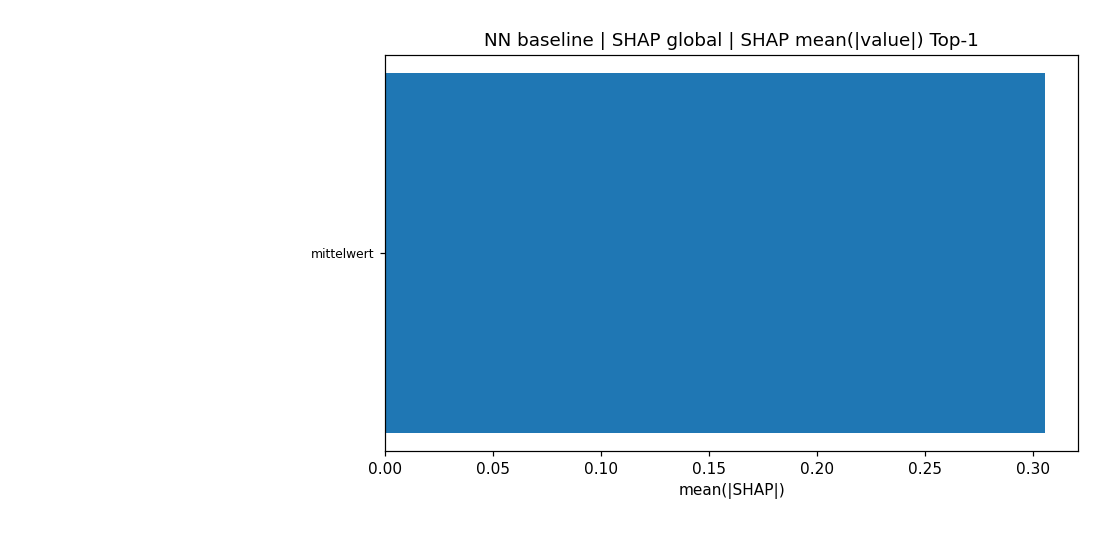

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



### SHAP LOCAL (final safe): NN baseline | SHAP local (fixed points) | shift=False | bg=200 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 16.94it/s]



### SHAP GLOBAL (final safe): NN environmental_shift | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:08<00:00, 18.50it/s]


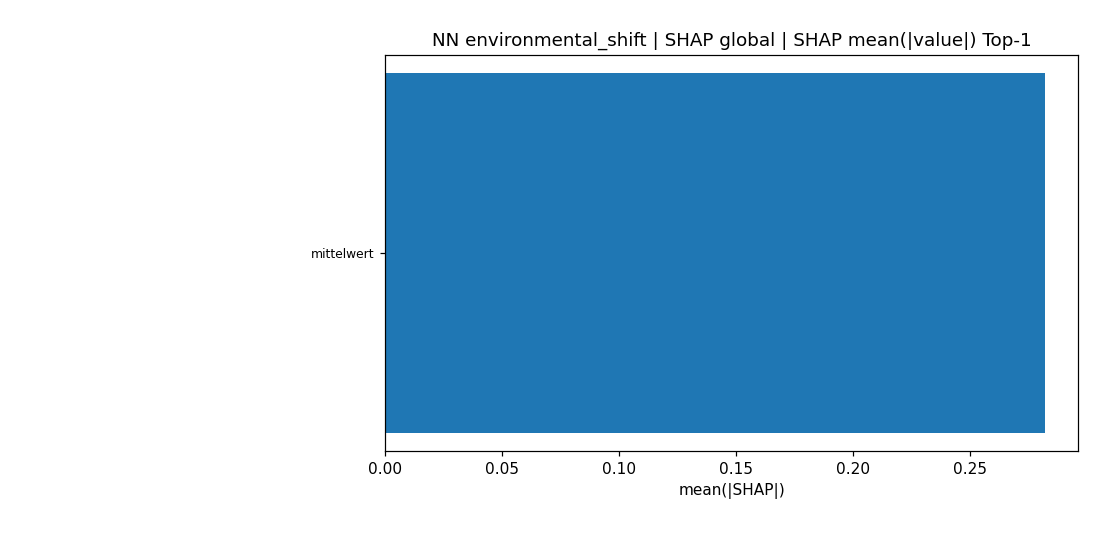


### SHAP LOCAL (final safe): NN environmental_shift | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 19.24it/s]


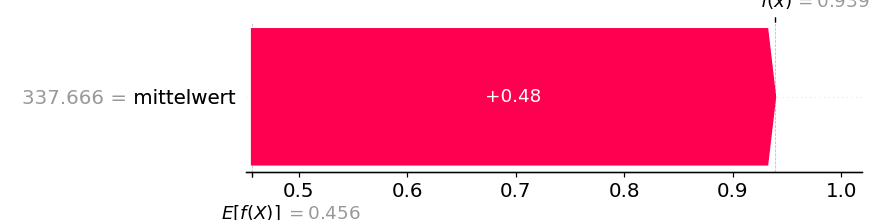

100%|██████████| 1/1 [00:00<00:00, 20.41it/s]


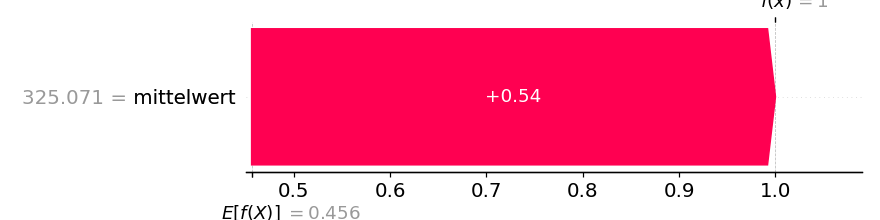

100%|██████████| 1/1 [00:00<00:00, 19.60it/s]


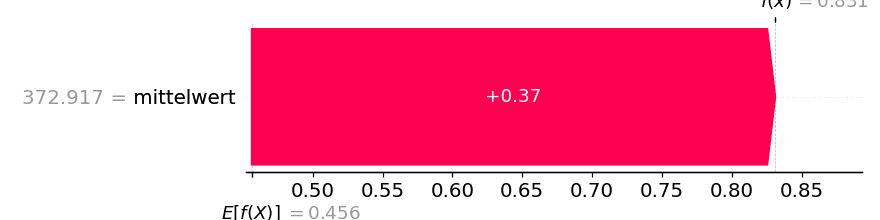

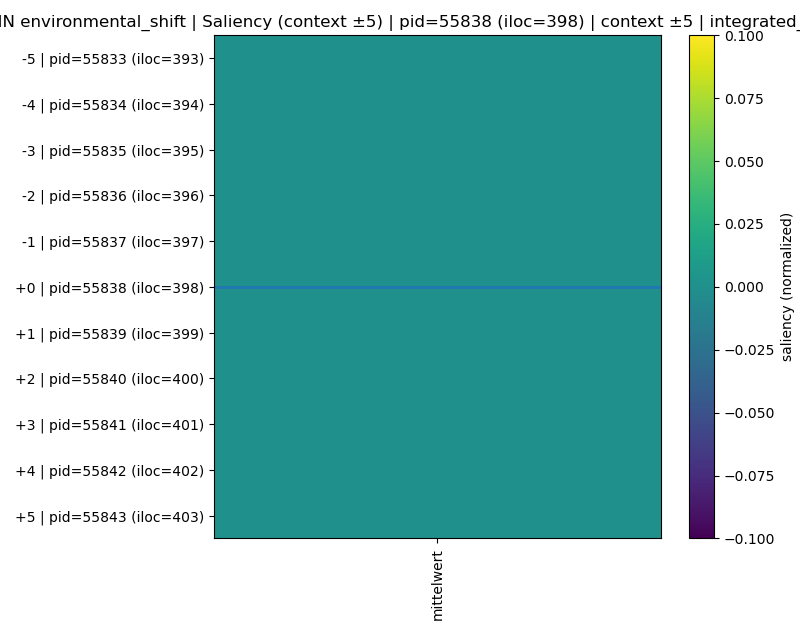

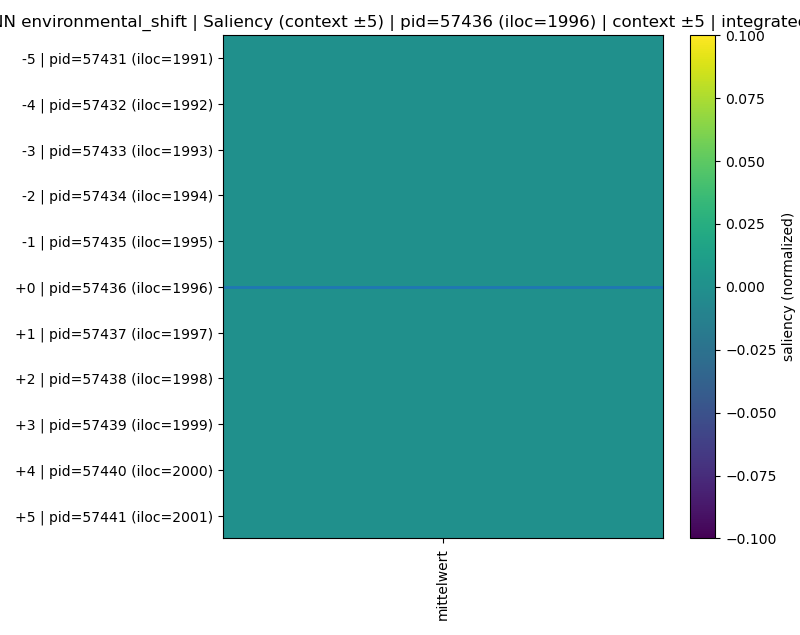

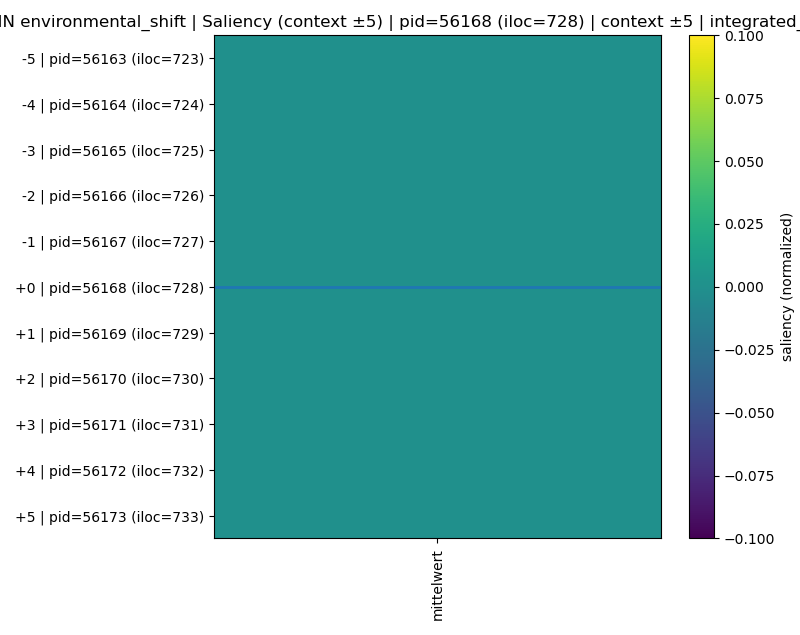


### SHAP GLOBAL (final safe): SVM environmental_shift | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:00<00:00, 1161.95it/s]


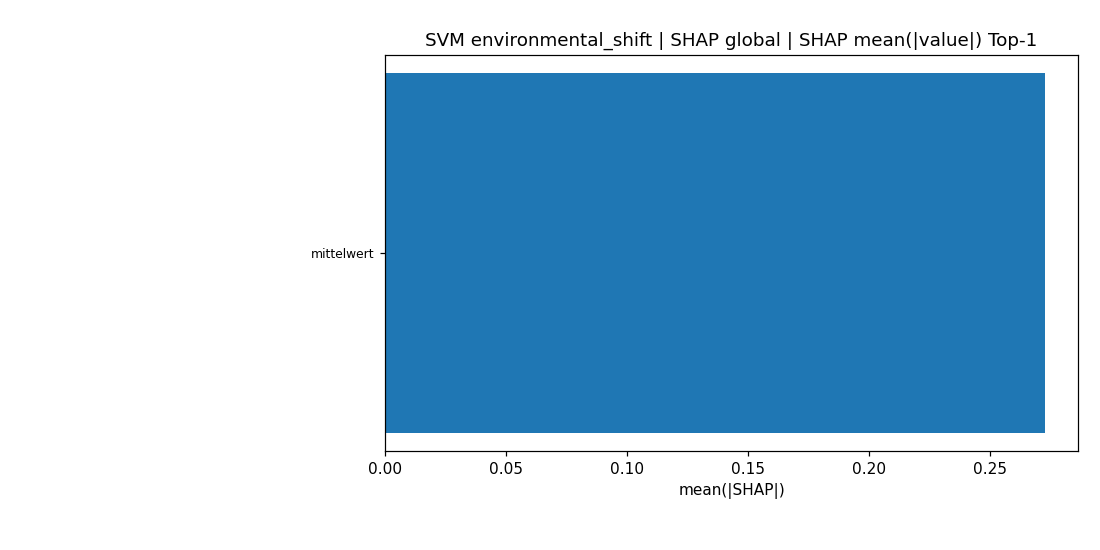


### SHAP LOCAL (final safe): SVM environmental_shift | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 997.69it/s]


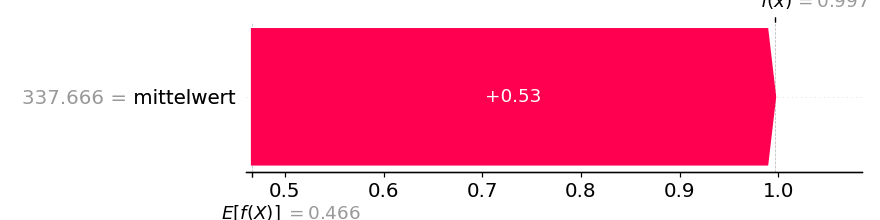

100%|██████████| 1/1 [00:00<00:00, 491.48it/s]


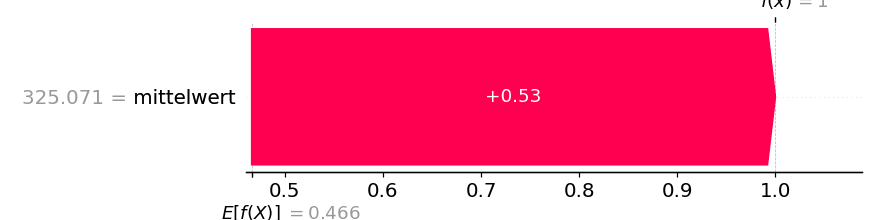

100%|██████████| 1/1 [00:00<00:00, 1000.31it/s]


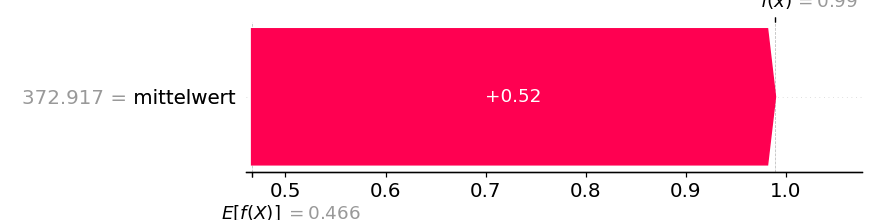


### environmental_shift | Prototypes & Criticisms | protos=10 crits=10 pool=5000


C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anacond


### SHAP GLOBAL (final safe): NN model_drift | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:07<00:00, 19.47it/s]


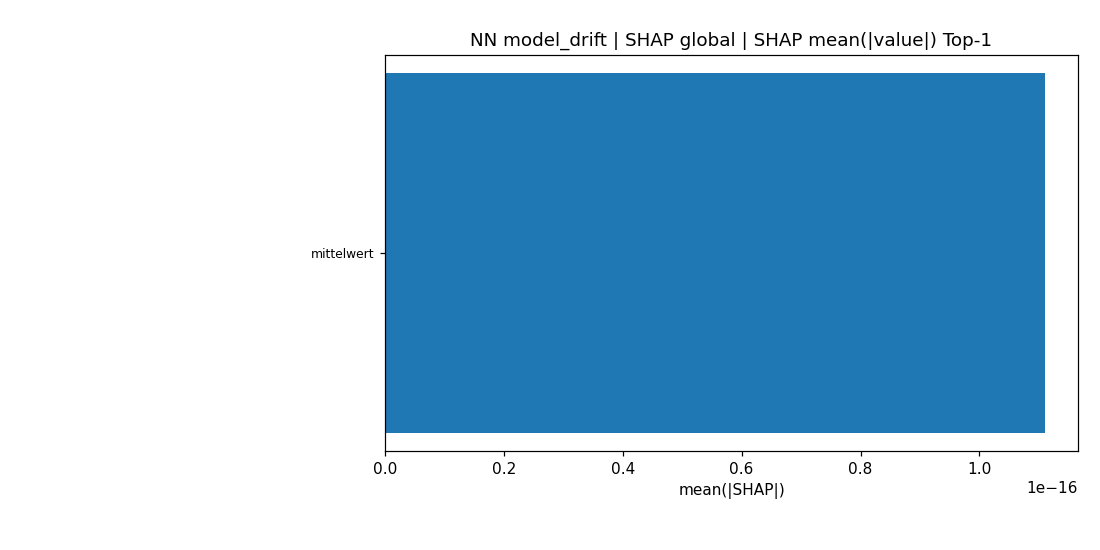


### SHAP LOCAL (final safe): NN model_drift | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 20.43it/s]


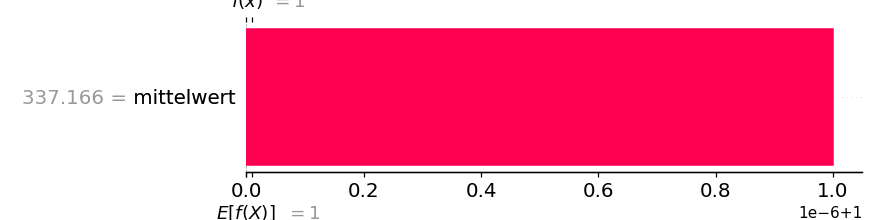

100%|██████████| 1/1 [00:00<00:00, 20.83it/s]


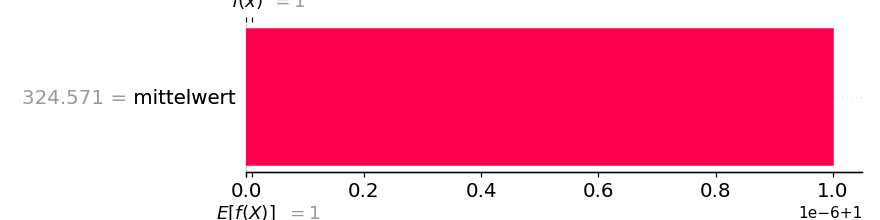

100%|██████████| 1/1 [00:00<00:00, 19.24it/s]


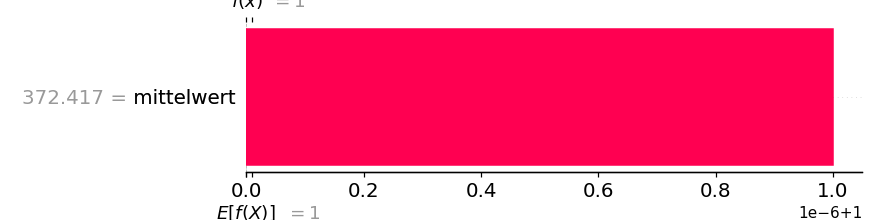

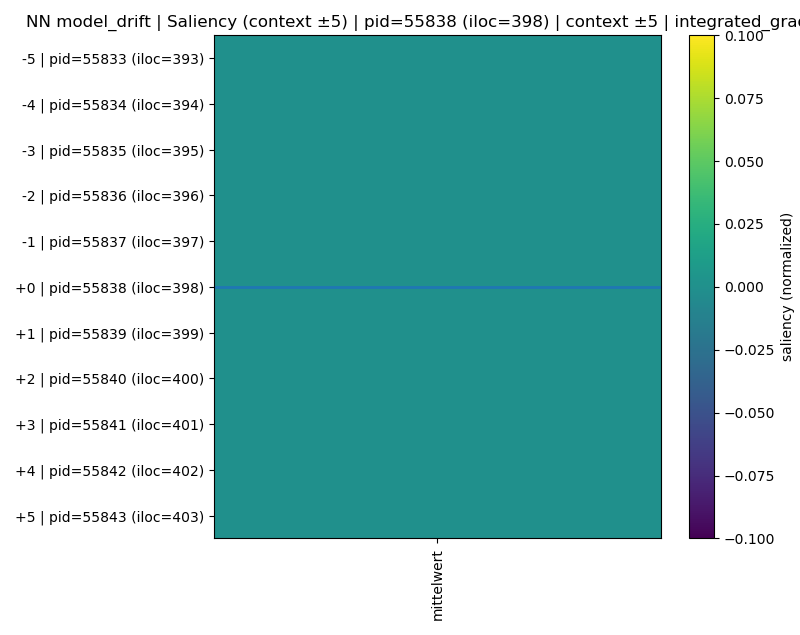

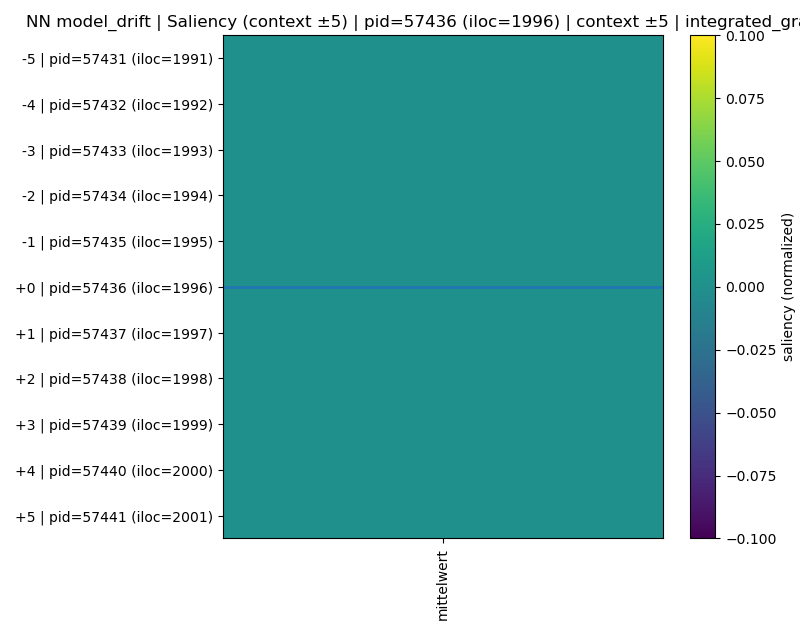

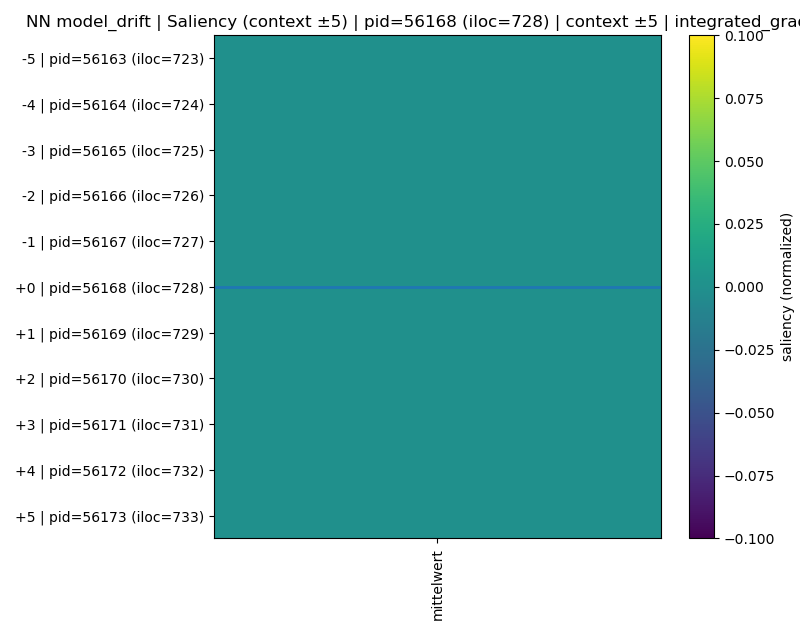


### SHAP GLOBAL (final safe): SVM model_drift | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:00<00:00, 1199.92it/s]


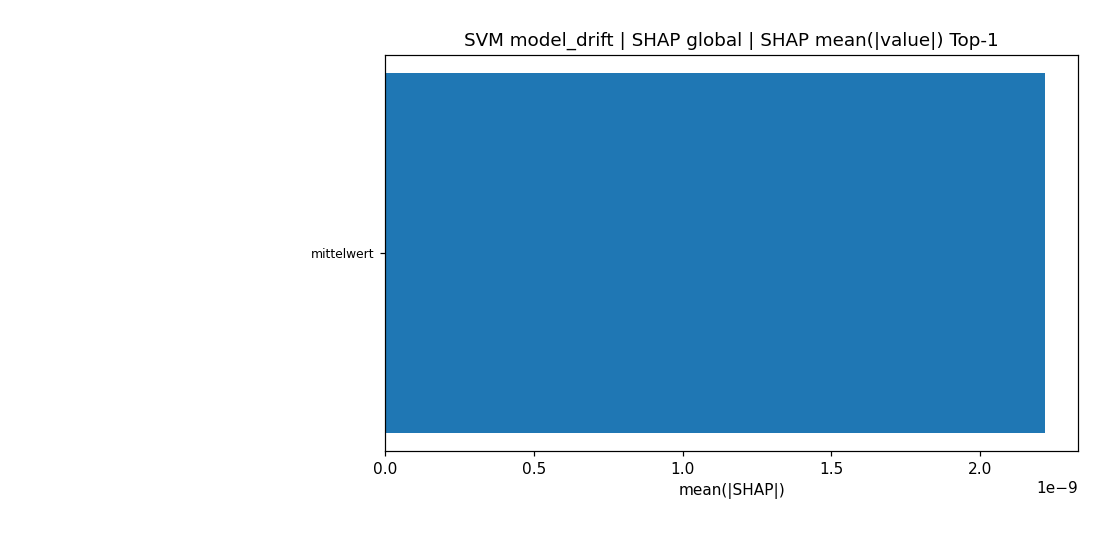


### SHAP LOCAL (final safe): SVM model_drift | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 999.36it/s]


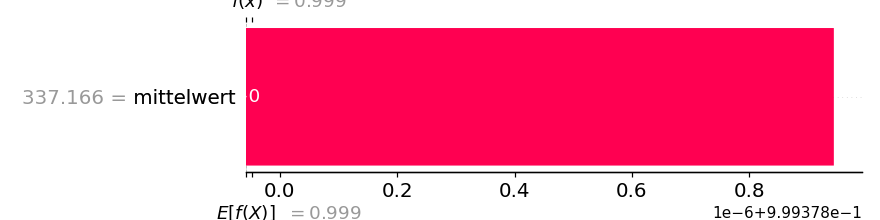

100%|██████████| 1/1 [00:00<00:00, 496.07it/s]


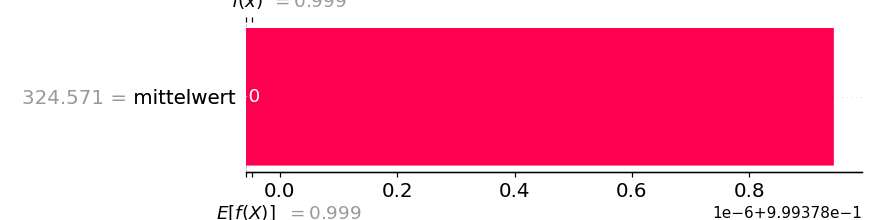

100%|██████████| 1/1 [00:00<00:00, 965.54it/s]


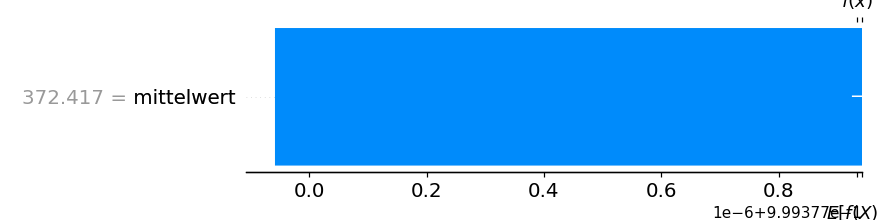


### model_drift | Prototypes & Criticisms | protos=10 crits=10 pool=5000


C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anacond


### SHAP GLOBAL (final safe): NN forgetting_A(onA) | SHAP global | shift=False | bg=80 explain=150 nsamples=200 topK=20


100%|██████████| 150/150 [00:07<00:00, 20.17it/s]


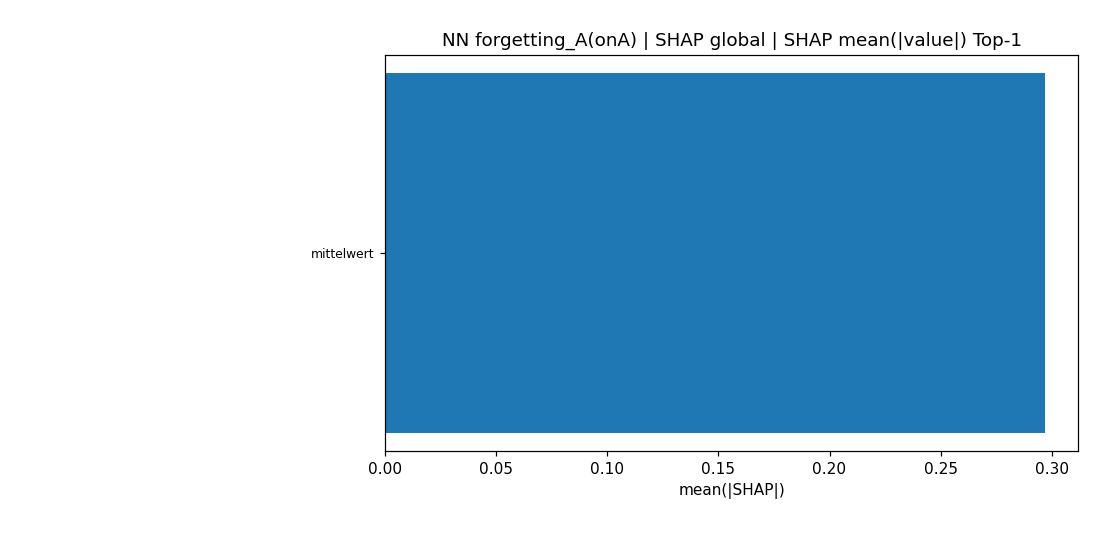


### SHAP LOCAL (final safe): NN forgetting_A(onA) | SHAP local (fixed points) | shift=False | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 22.22it/s]


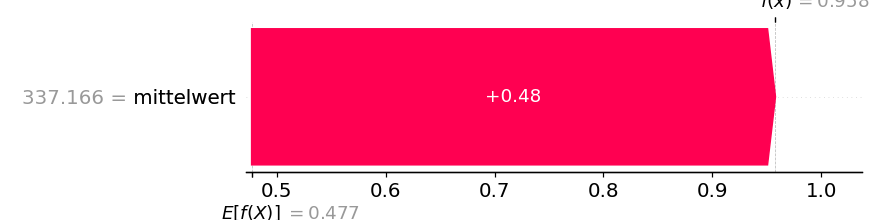

100%|██████████| 1/1 [00:00<00:00, 21.28it/s]


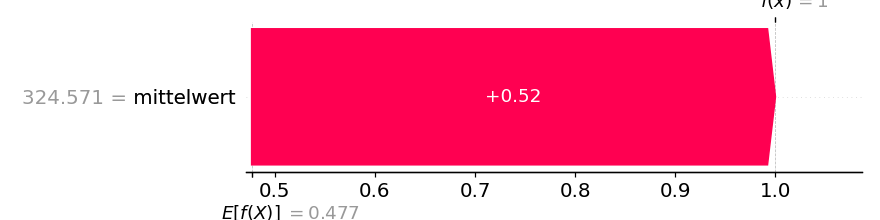

100%|██████████| 1/1 [00:00<00:00, 19.19it/s]


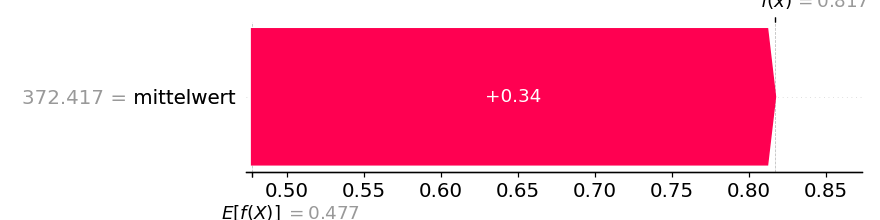

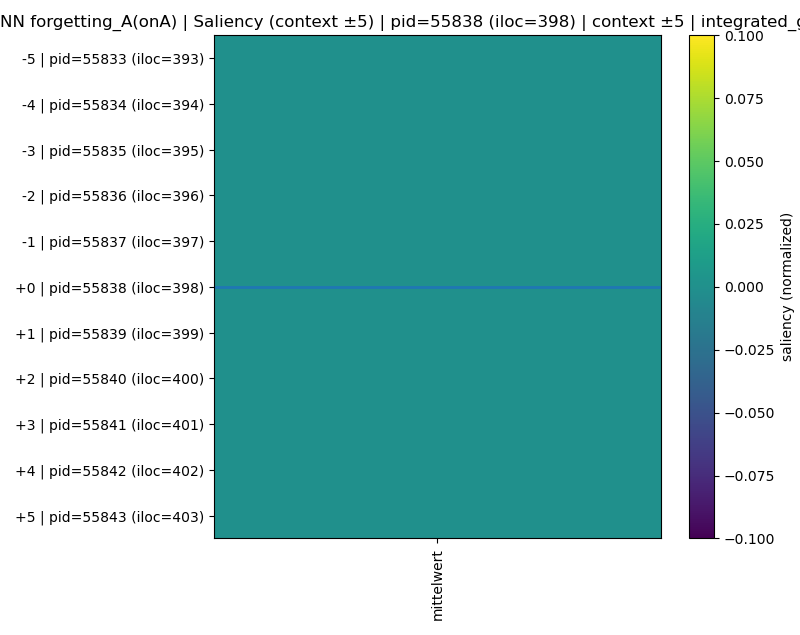

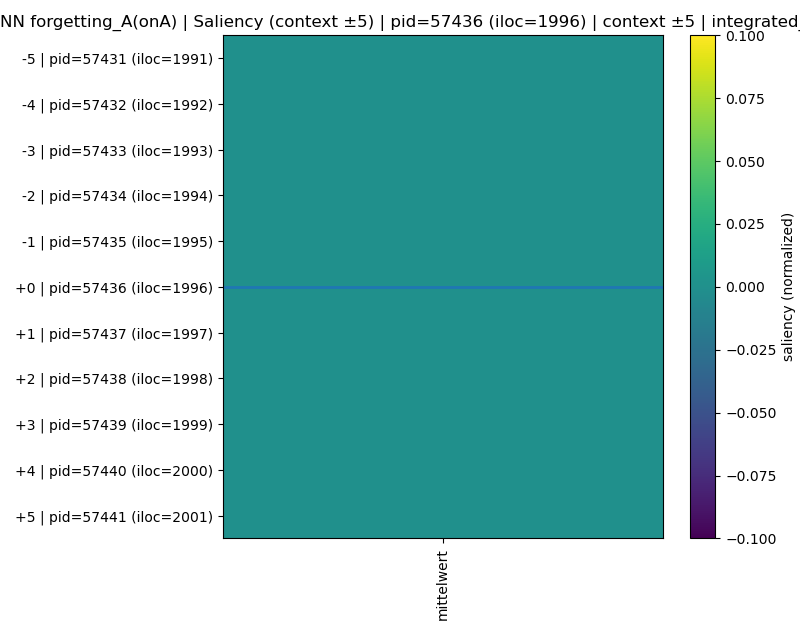

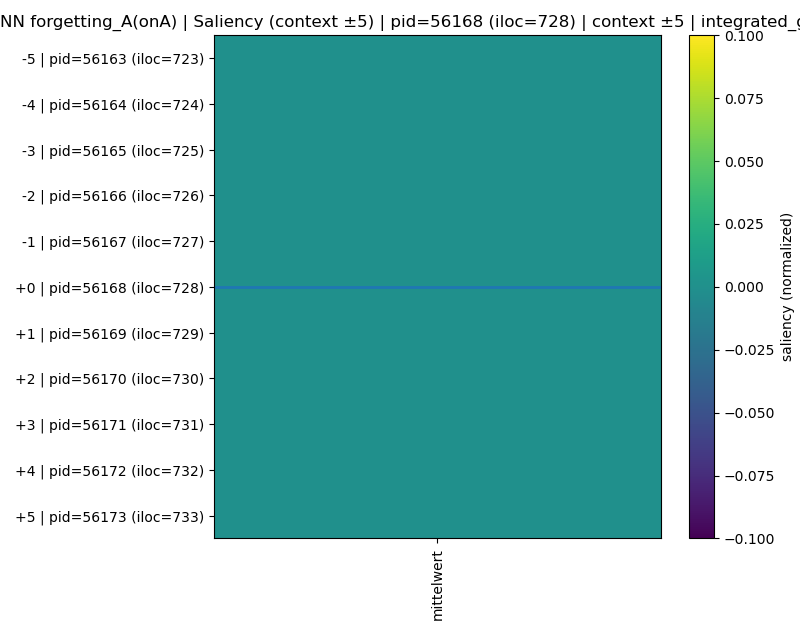


### SHAP GLOBAL (final safe): SVM forgetting_A(onA) | SHAP global | shift=False | bg=80 explain=150 nsamples=200 topK=20


100%|██████████| 150/150 [00:00<00:00, 1239.44it/s]


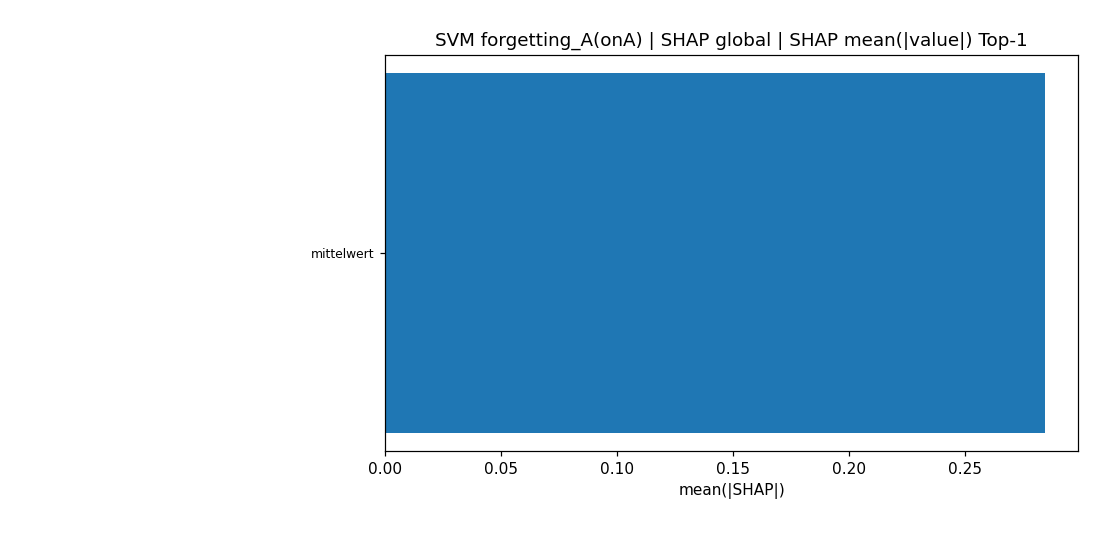


### SHAP LOCAL (final safe): SVM forgetting_A(onA) | SHAP local (fixed points) | shift=False | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 913.00it/s]


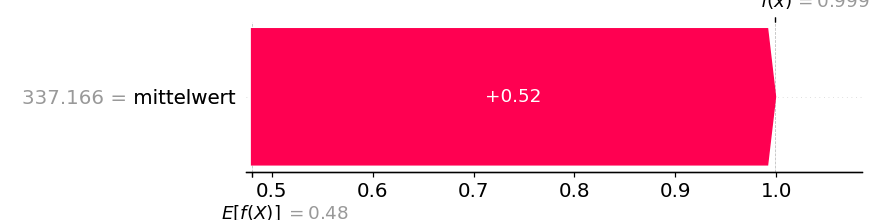

100%|██████████| 1/1 [00:00<00:00, 498.97it/s]


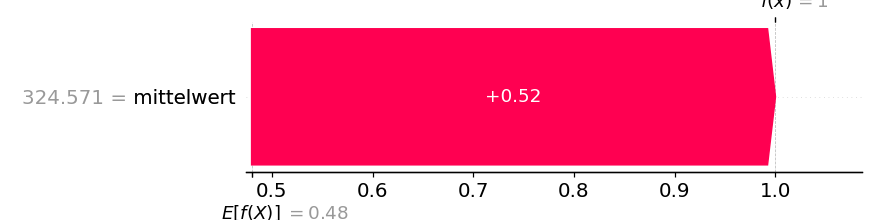

100%|██████████| 1/1 [00:00<00:00, 997.46it/s]


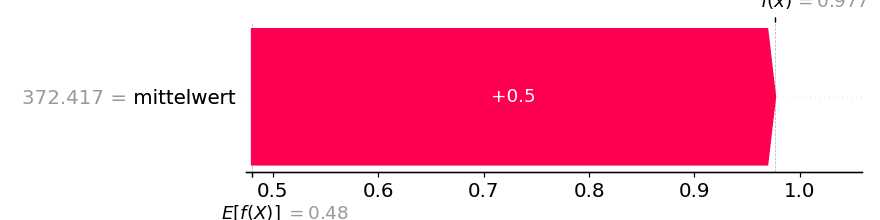


### forgetting_A(onA) | Prototypes & Criticisms | protos=10 crits=10 pool=5000

### SHAP GLOBAL (final safe): NN forgetting_B(onA) | SHAP global | shift=False | bg=80 explain=150 nsamples=200 topK=20


100%|██████████| 150/150 [00:07<00:00, 21.07it/s]


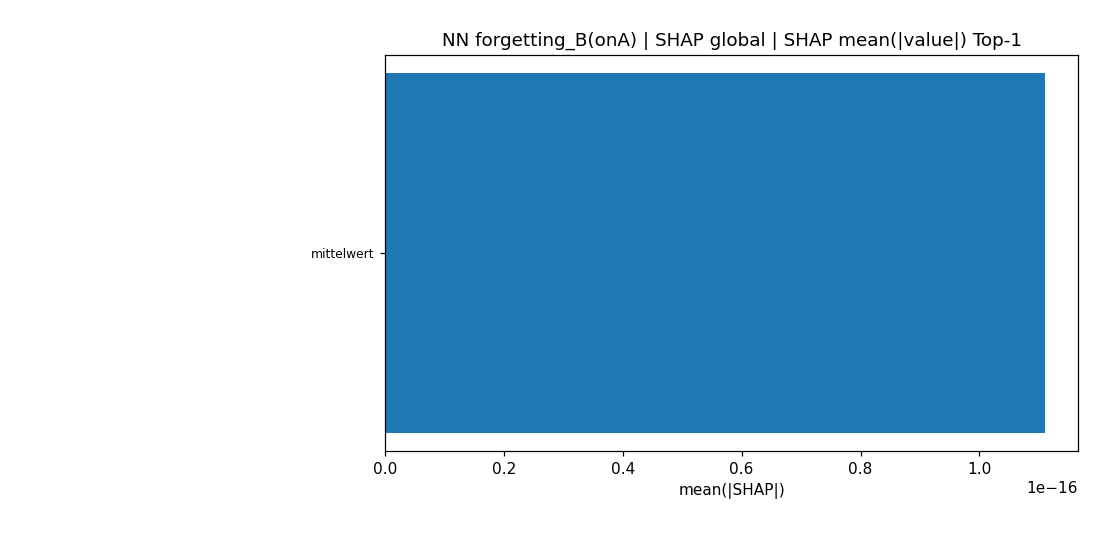


### SHAP LOCAL (final safe): NN forgetting_B(onA) | SHAP local (fixed points) | shift=False | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 22.22it/s]


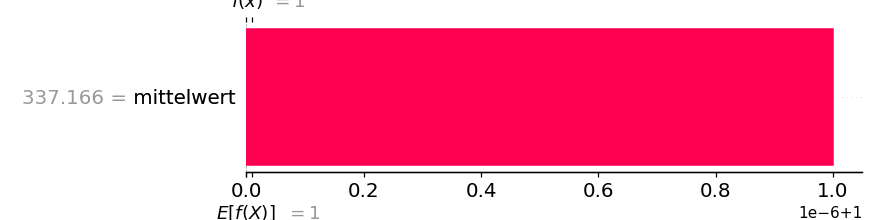

100%|██████████| 1/1 [00:00<00:00, 20.00it/s]


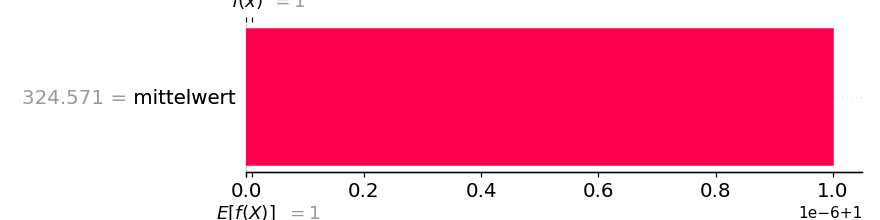

100%|██████████| 1/1 [00:00<00:00, 22.22it/s]


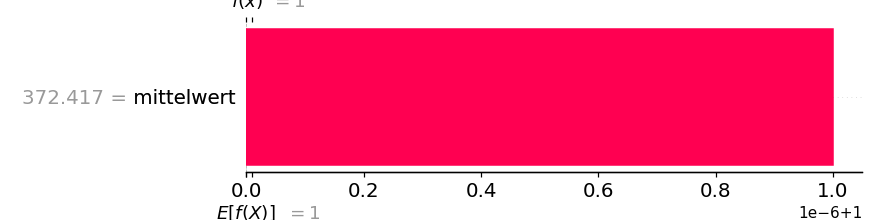

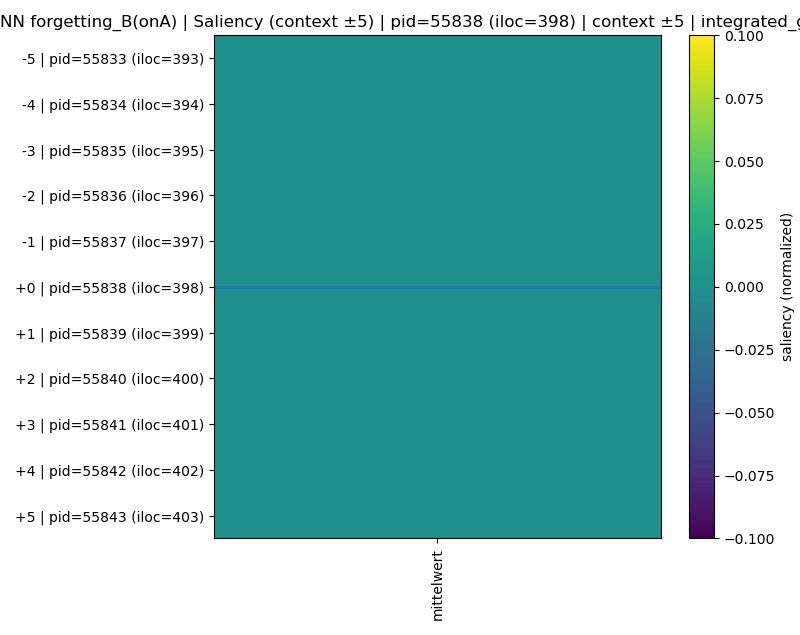

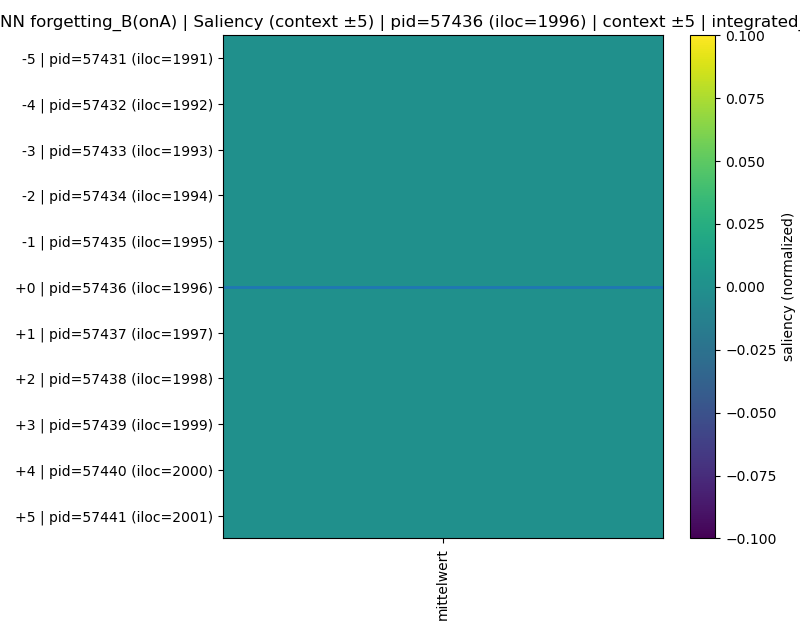

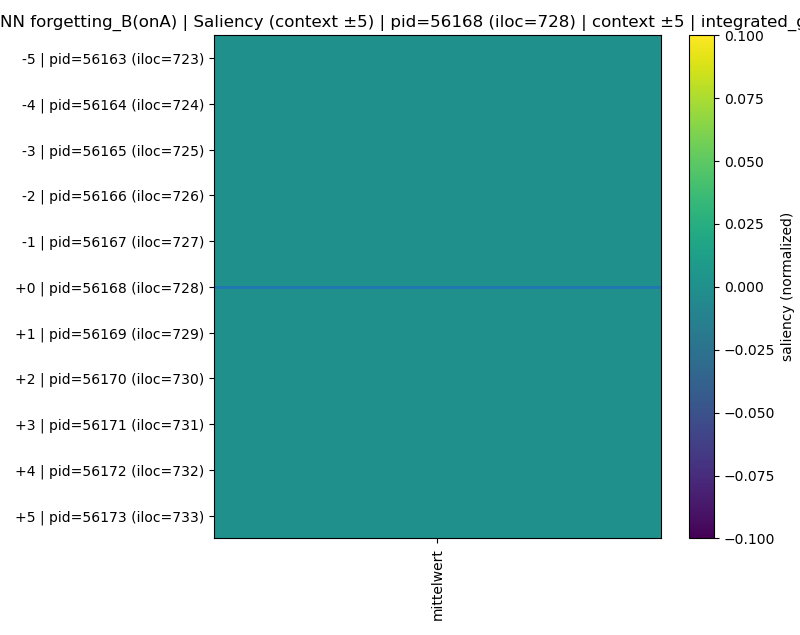


### SHAP GLOBAL (final safe): SVM forgetting_B(onA) | SHAP global | shift=False | bg=80 explain=150 nsamples=200 topK=20


100%|██████████| 150/150 [00:00<00:00, 1223.67it/s]


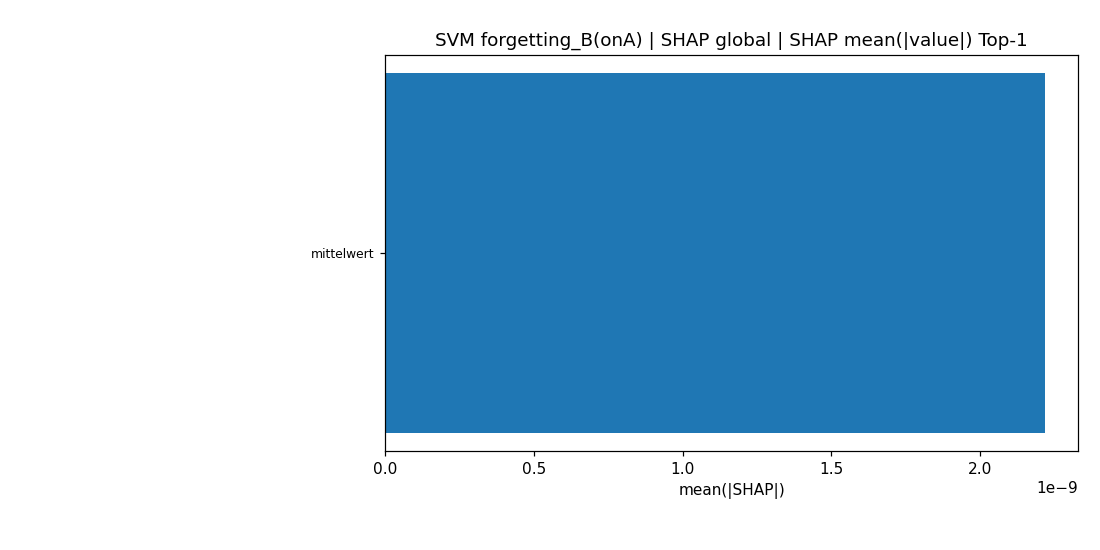


### SHAP LOCAL (final safe): SVM forgetting_B(onA) | SHAP local (fixed points) | shift=False | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 999.83it/s]


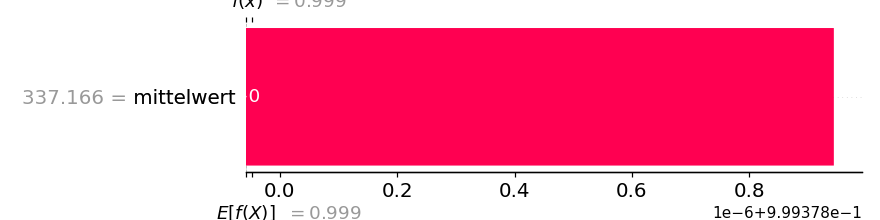

100%|██████████| 1/1 [00:00<00:00, 995.80it/s]


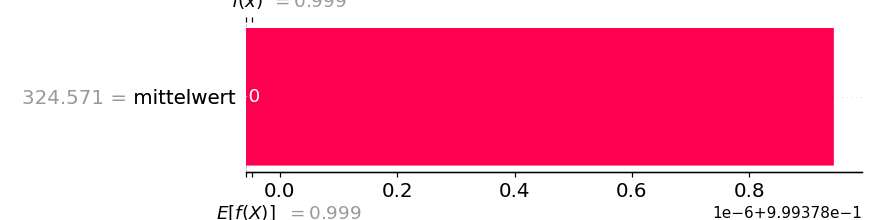

100%|██████████| 1/1 [00:00<00:00, 1001.03it/s]


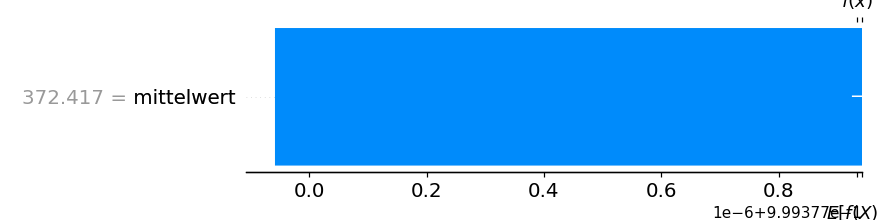


### forgetting_B(onA) | Prototypes & Criticisms | protos=10 crits=10 pool=5000

### SHAP GLOBAL (final safe): NN forgetting_B(onB) | SHAP global | shift=False | bg=80 explain=150 nsamples=200 topK=20


100%|██████████| 150/150 [00:07<00:00, 20.85it/s]


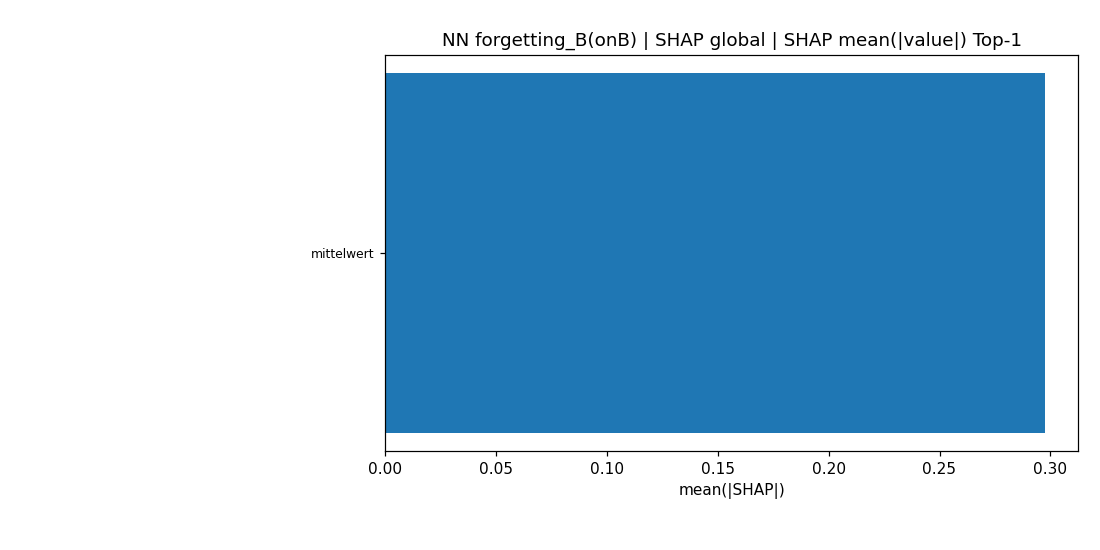


### SHAP LOCAL (final safe): NN forgetting_B(onB) | SHAP local (fixed points) | shift=False | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 21.28it/s]


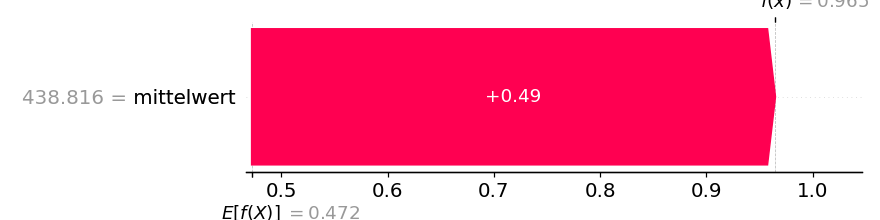

100%|██████████| 1/1 [00:00<00:00, 22.22it/s]


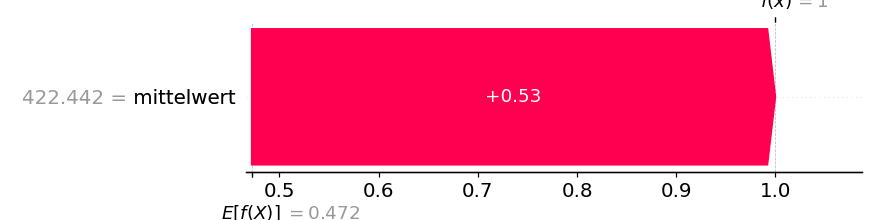

100%|██████████| 1/1 [00:00<00:00, 22.23it/s]


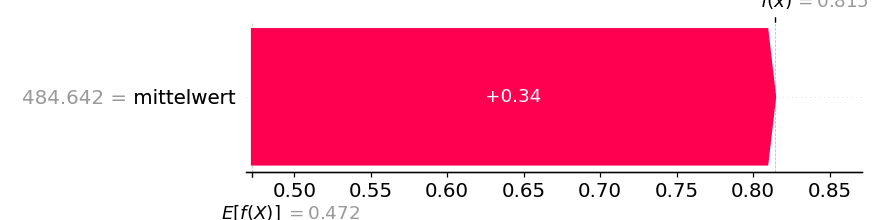

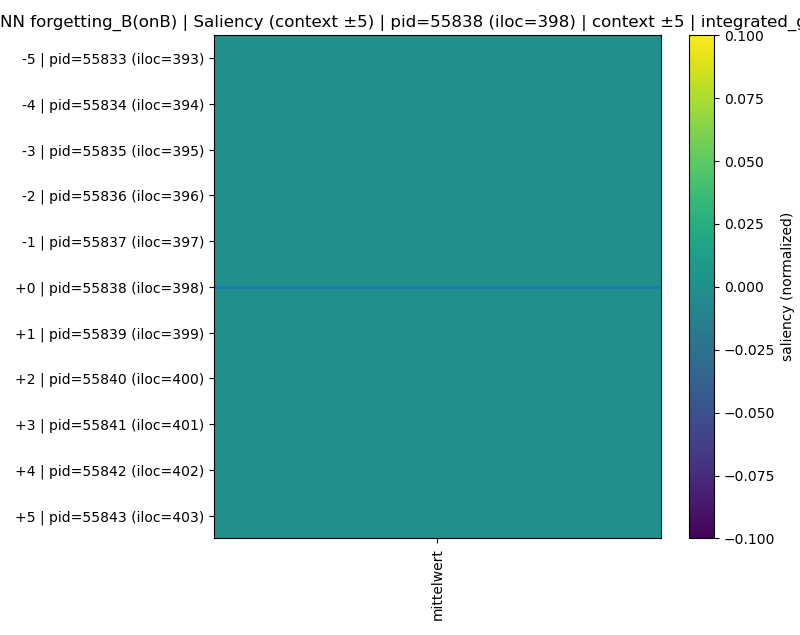

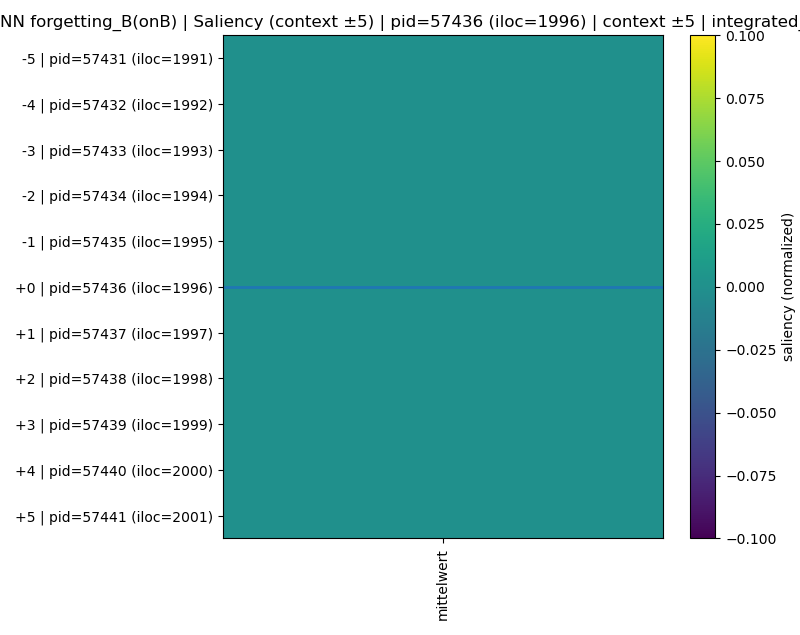

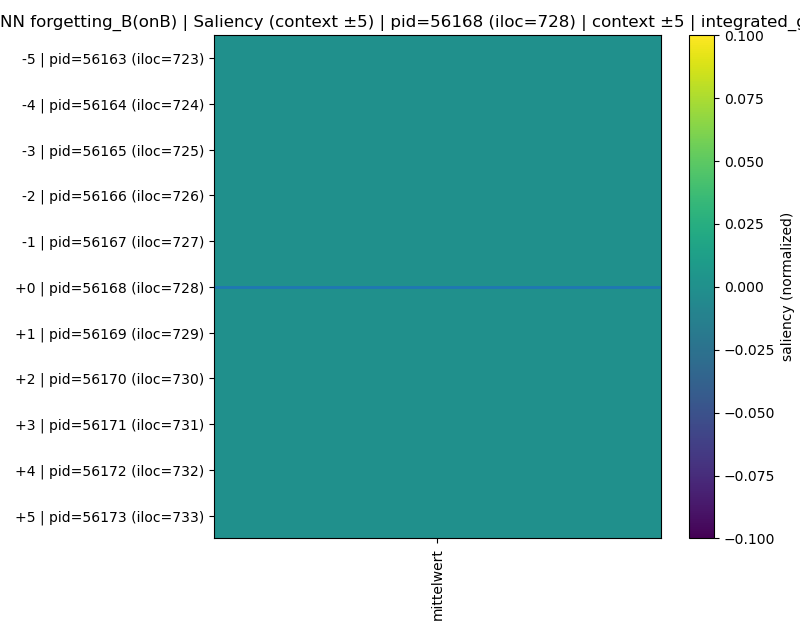


### SHAP GLOBAL (final safe): SVM forgetting_B(onB) | SHAP global | shift=False | bg=80 explain=150 nsamples=200 topK=20


100%|██████████| 150/150 [00:00<00:00, 1238.77it/s]


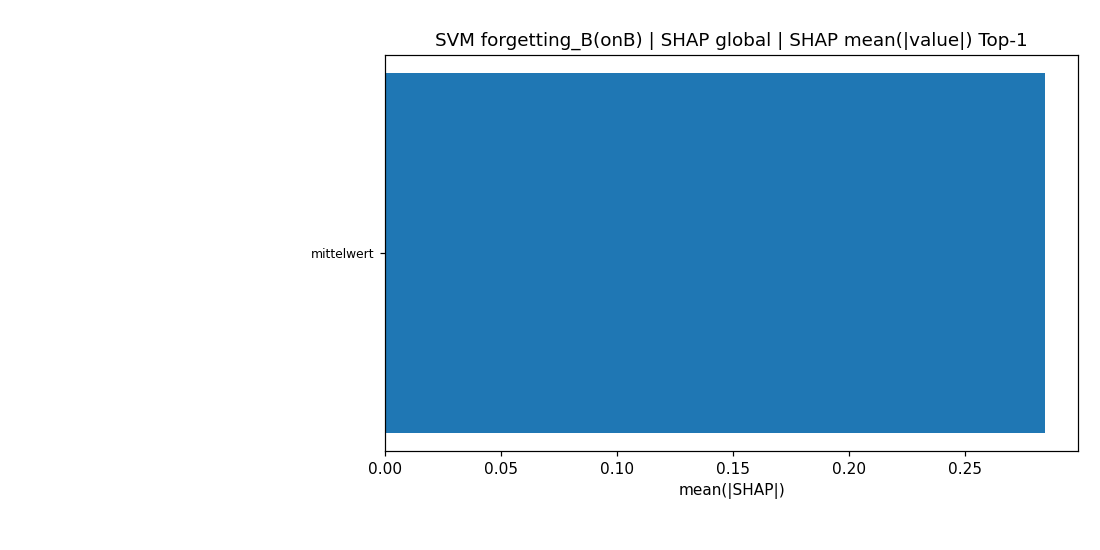


### SHAP LOCAL (final safe): SVM forgetting_B(onB) | SHAP local (fixed points) | shift=False | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 910.62it/s]


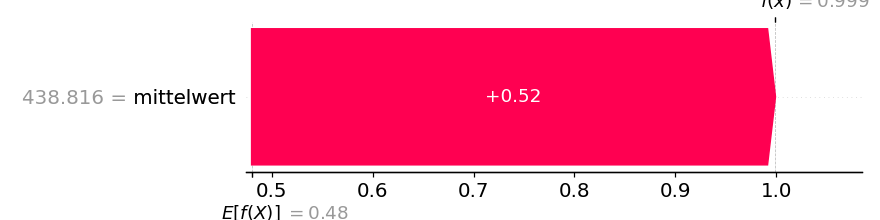

100%|██████████| 1/1 [00:00<00:00, 953.03it/s]


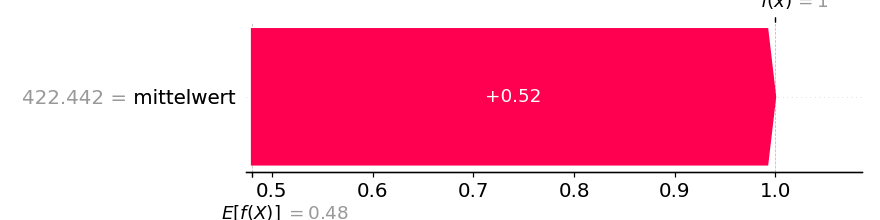

100%|██████████| 1/1 [00:00<00:00, 916.99it/s]


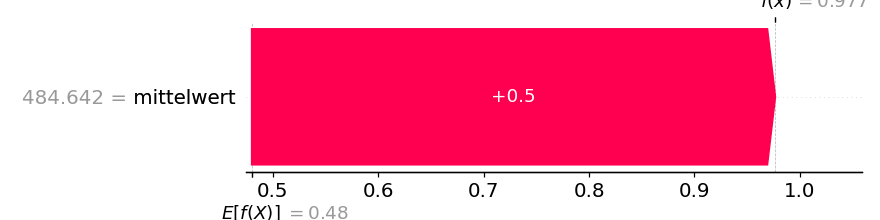


### forgetting_B(onB) | Prototypes & Criticisms | protos=10 crits=10 pool=5000


C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anaconda3\envs\Diss_Shap\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ko\Anacond


### SHAP GLOBAL (final safe): NN underfitting | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:07<00:00, 20.01it/s]


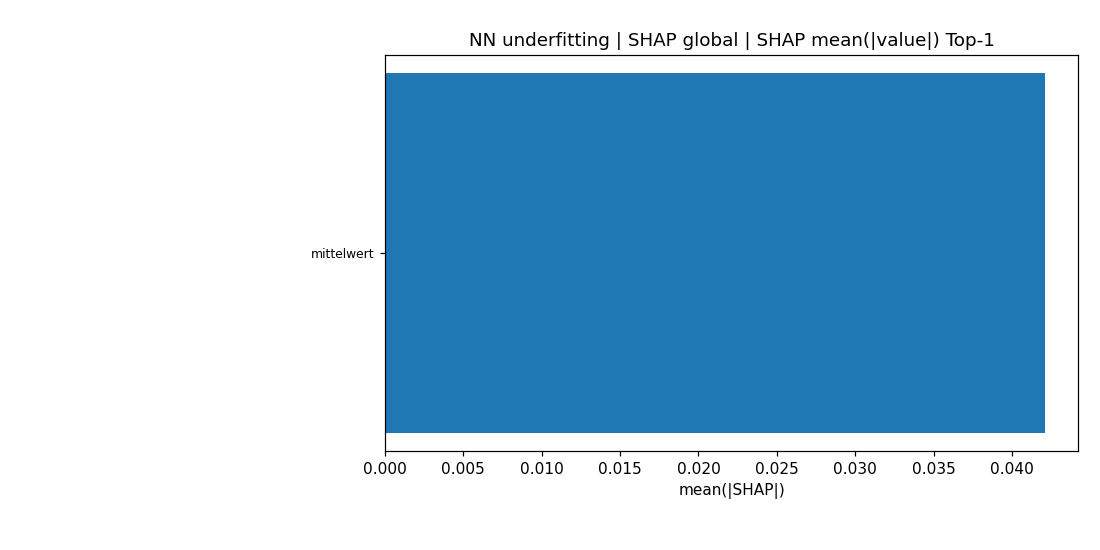


### SHAP LOCAL (final safe): NN underfitting | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 18.53it/s]


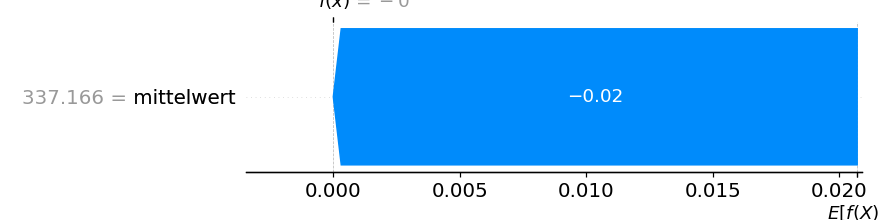

100%|██████████| 1/1 [00:00<00:00, 21.31it/s]


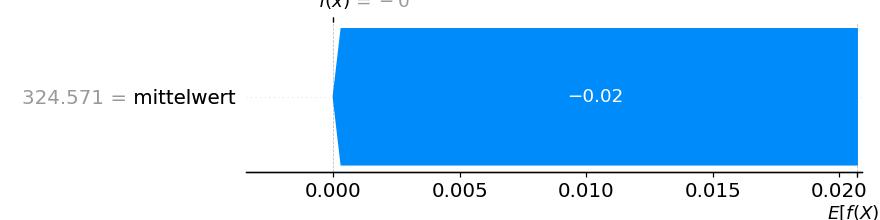

100%|██████████| 1/1 [00:00<00:00, 20.81it/s]


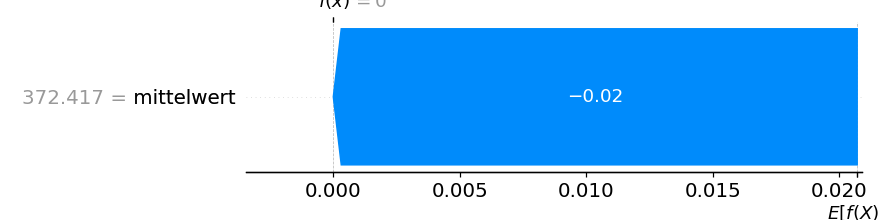

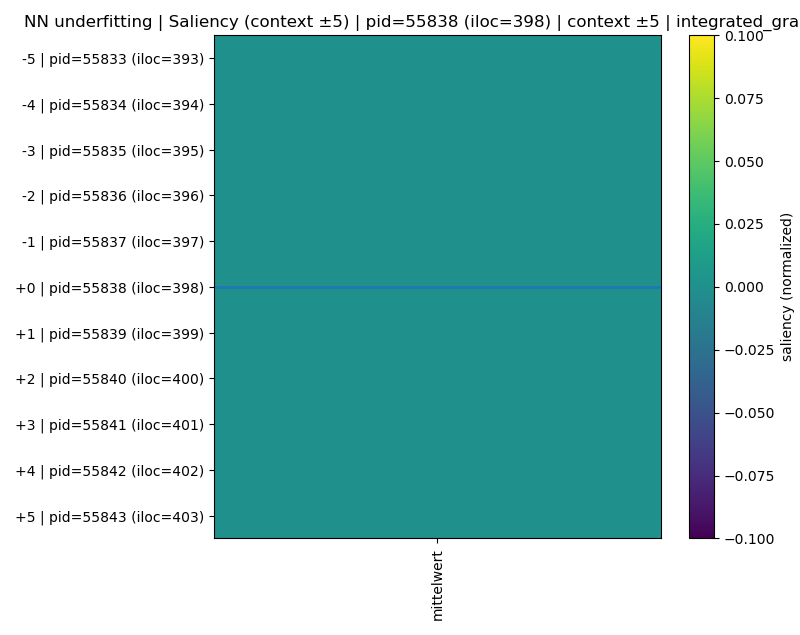

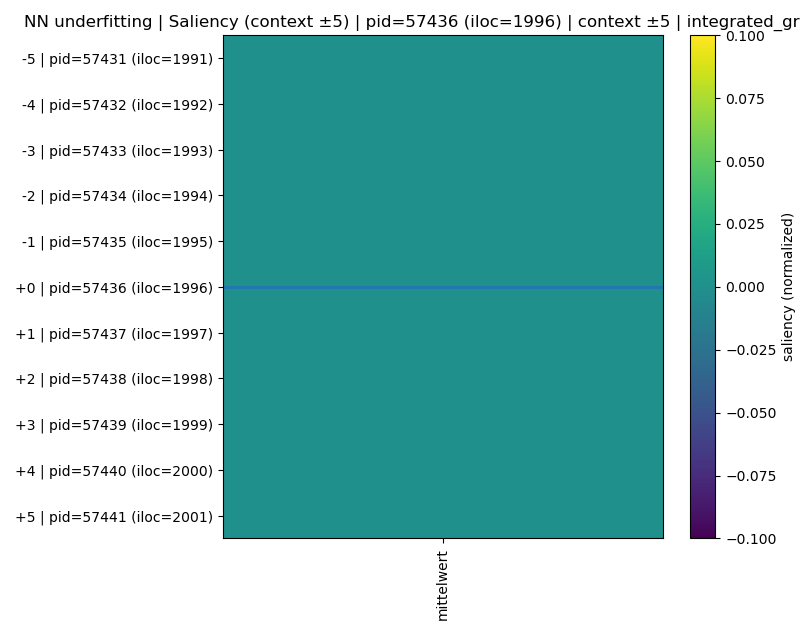

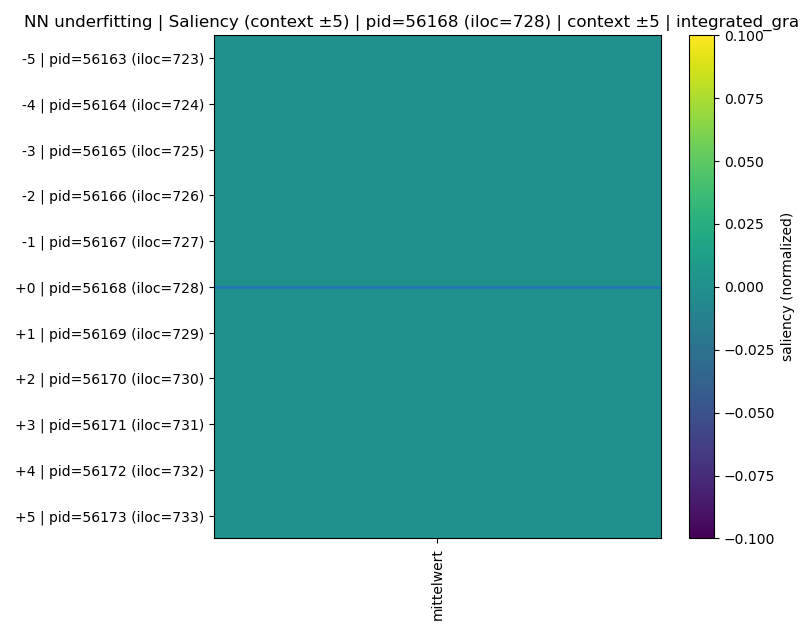


### SHAP GLOBAL (final safe): SVM underfitting | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:00<00:00, 215.82it/s]


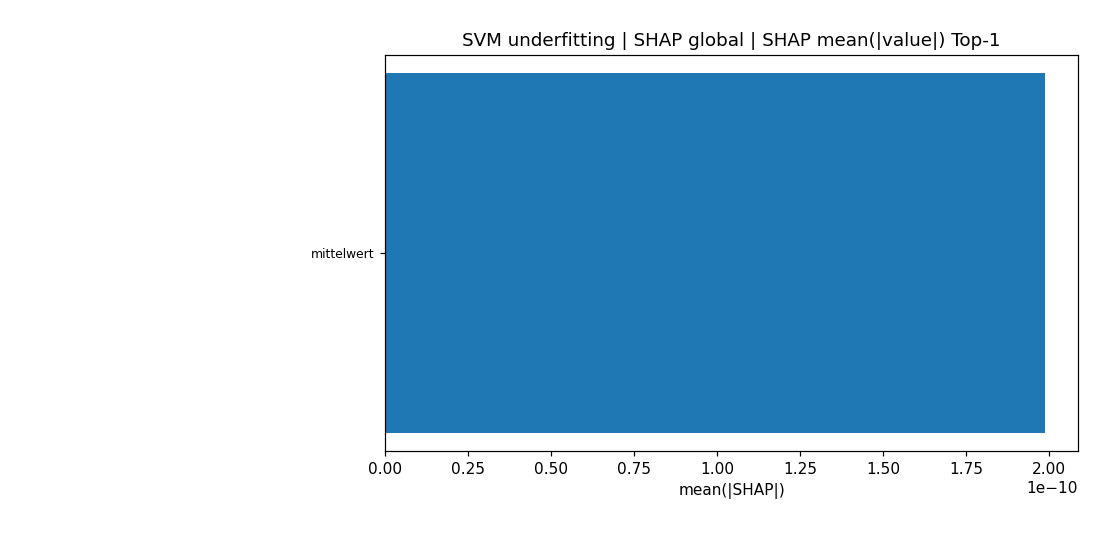


### SHAP LOCAL (final safe): SVM underfitting | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 199.42it/s]


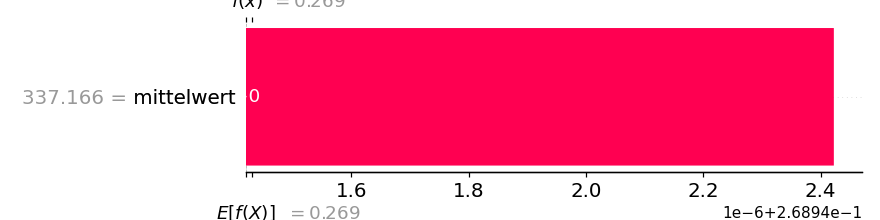

100%|██████████| 1/1 [00:00<00:00, 196.65it/s]


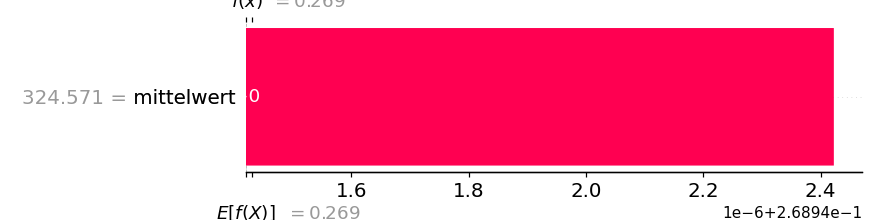

100%|██████████| 1/1 [00:00<00:00, 195.64it/s]


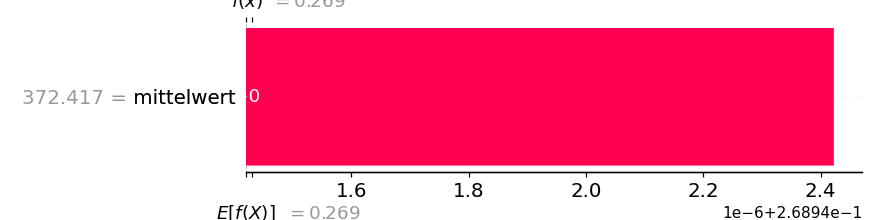


### underfitting | Prototypes & Criticisms | protos=10 crits=10 pool=5000

### SHAP GLOBAL (final safe): NN overfitting | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:07<00:00, 20.58it/s]


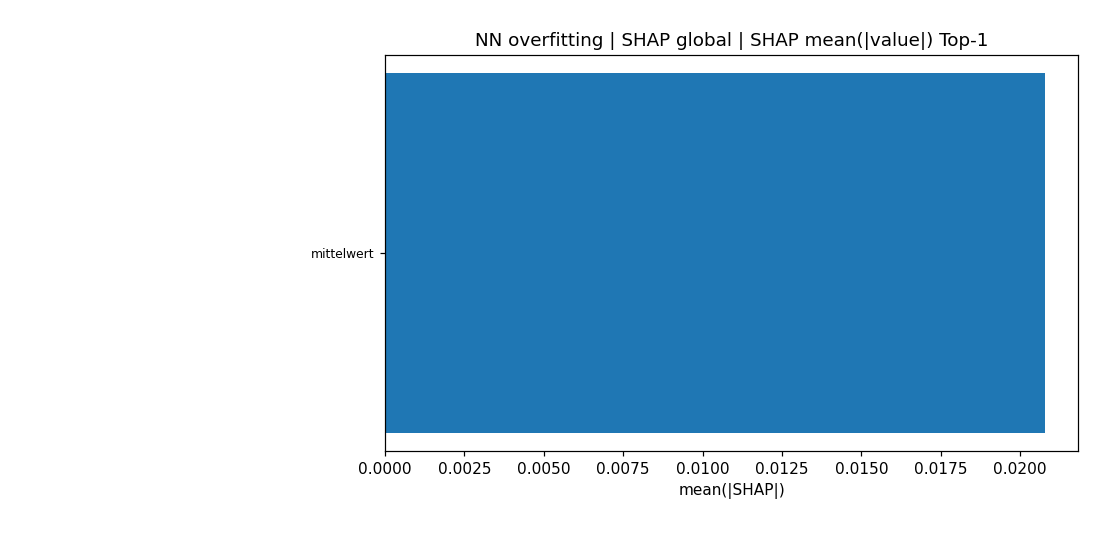


### SHAP LOCAL (final safe): NN overfitting | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<00:00, 21.31it/s]


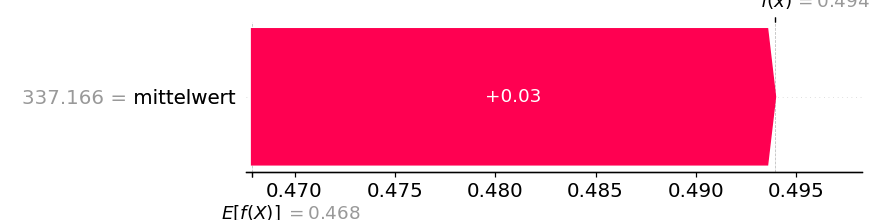

100%|██████████| 1/1 [00:00<00:00, 20.82it/s]


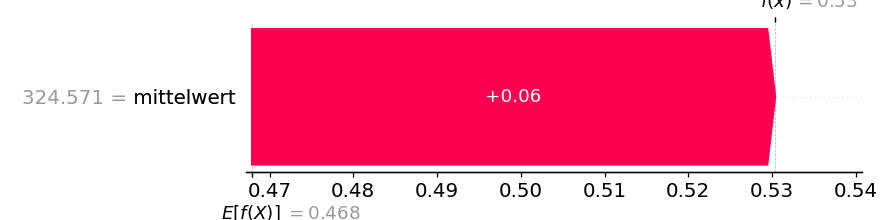

100%|██████████| 1/1 [00:00<00:00, 21.74it/s]


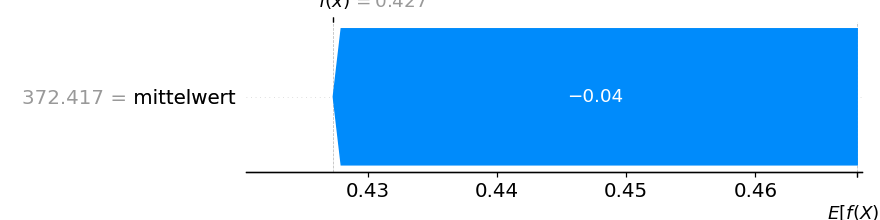

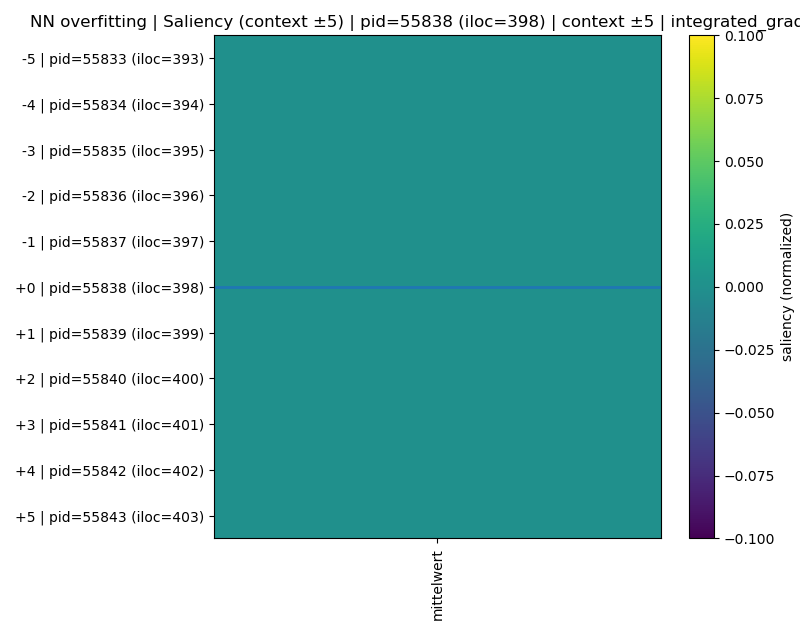

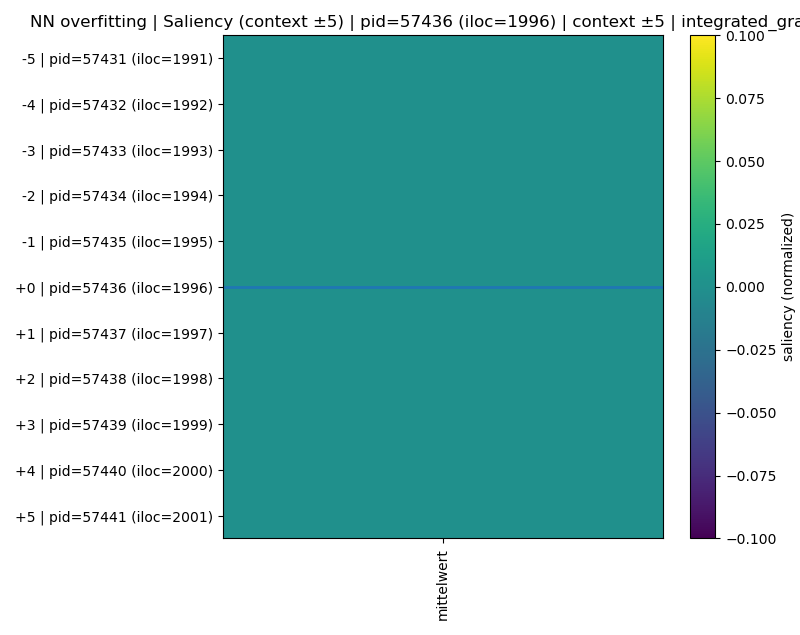

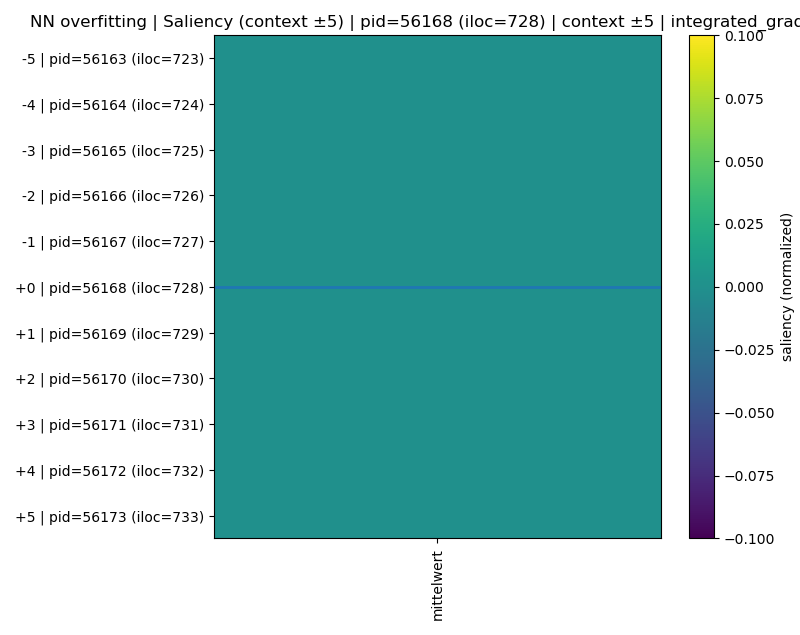


### SHAP GLOBAL (final safe): SVM overfitting | SHAP global | shift=True | bg=80 explain=150 nsamples=200 topK=15


100%|██████████| 150/150 [00:00<00:00, 3661.93it/s]


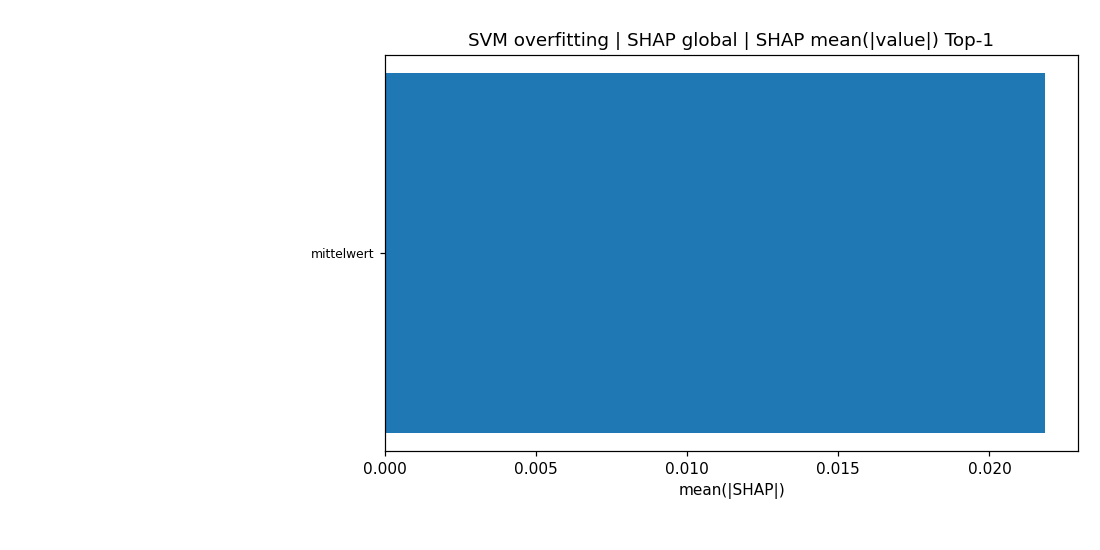


### SHAP LOCAL (final safe): SVM overfitting | SHAP local (fixed points) | shift=True | bg=60 nsamples=200 topK=15


100%|██████████| 1/1 [00:00<?, ?it/s]


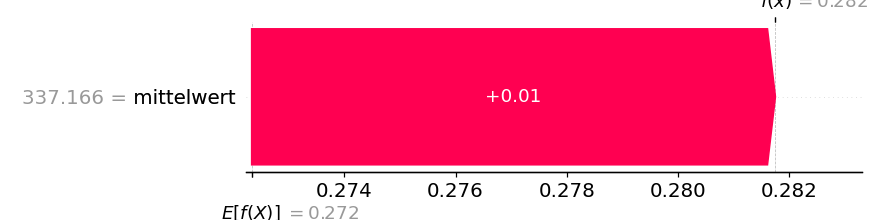

100%|██████████| 1/1 [00:00<00:00, 1003.18it/s]


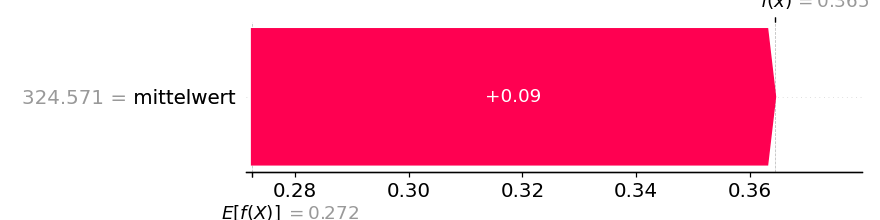

100%|██████████| 1/1 [00:00<?, ?it/s]


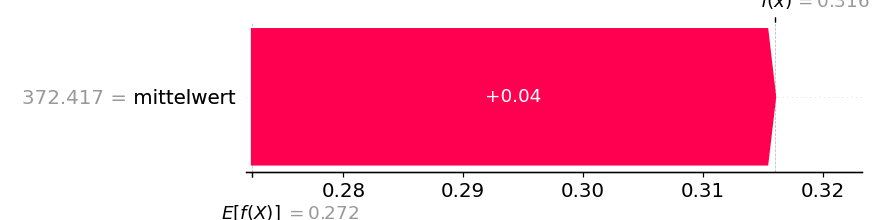


### overfitting | Prototypes & Criticisms | protos=10 crits=10 pool=5000
DONE. Scenarios: ['baseline', 'covariance_shift', 'environmental_shift', 'model_drift', 'catastrophic_forgetting', 'underfitting', 'overfitting']


In [12]:
# ============================================================
# 8) MAIN (aktivieren sobald df_base/feature_cols gesetzt sind)
#    (angepasst: DenseNN + SVM + neuer XAI-Stack)
# ============================================================
# Quelle/Originalstruktur aus deinem Block :contentReference[oaicite:0]{index=0}

df = prepare_df(df_base)

# Stable IDs for comparing the same logical point across scenarios
ID_COL = CONFIG.get("id_col", "point_id")
df = ensure_point_id(df, ID_COL)

# Domain A: zeitbasiert splitten
df_train_A, df_test_A = split_time_ordered(df, CONFIG["train_frac"])
df_tr_A, df_val_A = make_train_val(df_train_A, CONFIG["val_frac_within_train"])

# Baseline-Scaler nur aus Train (Domain A) -> für DenseNN + Prototypes/Criticisms
scaler_A = make_scaler_from_train(df_tr_A, feature_cols)

# ------------------------------------------------------------
# Train clean models (Domain A)
# ------------------------------------------------------------
# DenseNN (Keras)
nn_clean = train_dense_on_df(
    df_train=df_tr_A,
    scaler=scaler_A,
    feature_cols=feature_cols,
    label_col=label_col,
    epochs=CONFIG.get("nn_epochs", 200),
    batch_size=CONFIG.get("nn_batch_size", 32),
    seed=CONFIG["seed"],
)

# SVM Pipeline (Imputer -> Scaler -> SVC)
svm_clean = train_svm_pipeline(df_tr_A, feature_cols, label_col)

# Szenarien (CMAPSS-ähnlich)
scenarios = make_scenarios_like_cmapss(df_train_A=df_tr_A, df_test_A=df_test_A, feature_cols=feature_cols)
ALL_RESULTS = {}

# ------------------------------------------------------------
# Helper: DF hart auf feature_cols ausrichten (für alle Szenarien!)
# ------------------------------------------------------------
def align_df_to_features(df: pd.DataFrame, feature_cols, fill_value=0.0) -> pd.DataFrame:
    df = df.copy()
    # fehlende Feature-Spalten auffüllen
    missing = [c for c in feature_cols if c not in df.columns]
    for c in missing:
        df[c] = fill_value
    # Reihenfolge exakt wie feature_cols
    # (zusätzliche Spalten bleiben im DF, stören aber nicht, da wir df[feature_cols] nehmen)
    return df


# ------------------------------------------------------------
# 8.1 baseline / cov / env: evaluate-only shifts (no retraining)
# ------------------------------------------------------------
for name in ["baseline", "covariance_shift", "environmental_shift"]:
    sc = scenarios[name]

    # --- WICHTIG: prepare + ID + Feature-Alignment pro Szenario
    df_test = prepare_df(sc["test"])
    df_test = ensure_point_id(df_test, ID_COL)
    df_test = align_df_to_features(df_test, feature_cols, fill_value=0.0)

    # --- Optional: SHAP bei Shifts extra konservativ (Plots stabil halten)
    # (Wenn du das nicht willst, kannst du diesen Block entfernen.)
    if "CONFIG" in globals() and isinstance(CONFIG, dict):
        xai_cfg = CONFIG.get("xai", CONFIG)
        if name != "baseline":
            xai_cfg["shap_do_dependence_plot"] = False
            xai_cfg["shap_explain_size_global"] = min(int(xai_cfg.get("shap_explain_size_global", 300)), 150)
            xai_cfg["shap_background_size_global"] = min(int(xai_cfg.get("shap_background_size_global", 200)), 80)
            xai_cfg["shap_explain_size_local"] = min(int(xai_cfg.get("shap_explain_size_local", 100)), 80)
            xai_cfg["shap_background_size_local"] = min(int(xai_cfg.get("shap_background_size_local", 120)), 60)

    # --- Metrics
    met_nn  = eval_dense_on_df(nn_clean,  df_test, scaler_A, feature_cols, label_col)
    met_svm = eval_svm_on_df(svm_clean,   df_test, feature_cols, label_col)

    # --- XAI (jetzt wirklich mit dem Shift-DF)
    xai = run_xai_bundle_for_df(
        name=name,
        df_source=df_test,          # <-- hier das aligned scenario-DF
        feature_cols=feature_cols,
        label_col=label_col,
        scaler_A=scaler_A,
        nn_model=nn_clean,
        svm_pipeline=svm_clean,
    )

    ALL_RESULTS[name] = {
        "metrics": {"nn": met_nn, "svm": met_svm},
        "xai": xai,
        "meta": sc.get("meta", {}),
    }


# ------------------------------------------------------------
# Helper: "clone model" (tf.keras oder standalone keras)
# ------------------------------------------------------------
def _clone_keras_model(m):
    # funktioniert sowohl mit tf.keras als auch keras
    try:
        import tensorflow as tf
        if hasattr(tf, "keras"):
            cm = tf.keras.models.clone_model(m)
            cm.set_weights(m.get_weights())
            return cm
    except Exception:
        pass

    import keras
    cm = keras.models.clone_model(m)
    cm.set_weights(m.get_weights())
    return cm

def _compile_dense_like_original(m):
    # nutzt die global importierten layers/optimizers/metrics (tf.keras oder keras fallback)
    m.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[metrics.AUC(name="auc"), metrics.Precision(name="prec"), metrics.Recall(name="rec")],
    )
    return m

# ------------------------------------------------------------
# 8.2 model drift: MODEL-only (Train drifted, Test bleibt clean)
# ------------------------------------------------------------
sc = scenarios["model_drift"]

nn_drift = _clone_keras_model(nn_clean)
nn_drift = _compile_dense_like_original(nn_drift)

nn_drift = continue_train_dense(
    nn_drift,
    sc["train"],
    scaler_A,
    feature_cols,
    label_col,
    extra_epochs=CONFIG.get("drift_extra_epochs", 20),
    batch_size=CONFIG.get("nn_batch_size", 32),
)

# Für SVM gibt es kein "continue training" -> optional retrain auf drift-train
svm_drift = (
    train_svm_pipeline(sc["train"], feature_cols, label_col)
    if CONFIG.get("svm_retrain_on_drift", True)
    else svm_clean
)

met_nn  = eval_dense_on_df(nn_drift,  sc["test"], scaler_A, feature_cols, label_col)
met_svm = eval_svm_on_df(svm_drift, sc["test"], feature_cols, label_col)

xai = run_xai_bundle_for_df(
    name="model_drift",
    df_source=sc["test"],
    feature_cols=feature_cols,
    label_col=label_col,
    scaler_A=scaler_A,
    nn_model=nn_drift,
    svm_pipeline=svm_drift,
)

ALL_RESULTS["model_drift"] = {
    "metrics": {"nn": met_nn, "svm": met_svm},
    "xai": xai,
    "meta": sc.get("meta", {}),
}

# ------------------------------------------------------------
# 8.3 catastrophic forgetting: A -> train on B -> eval on A and B
# ------------------------------------------------------------
sc = scenarios["catastrophic_forgetting"]
nn_A = nn_clean
svm_A = svm_clean

nn_B = _clone_keras_model(nn_clean)
nn_B = _compile_dense_like_original(nn_B)
nn_B = continue_train_dense(
    nn_B,
    sc["train_B"],
    scaler_A,
    feature_cols,
    label_col,
    extra_epochs=CONFIG.get("forget_ft_epochs", 20),
    batch_size=CONFIG.get("nn_batch_size", 32),
)

svm_B = (
    train_svm_pipeline(sc["train_B"], feature_cols, label_col)
    if CONFIG.get("forget_svm_retrain", True)
    else svm_A
)

met_AA = {
    "nn":  eval_dense_on_df(nn_A,  sc["test_A"], scaler_A, feature_cols, label_col),
    "svm": eval_svm_on_df(svm_A, sc["test_A"], feature_cols, label_col),
}
met_BA = {
    "nn":  eval_dense_on_df(nn_B,  sc["test_A"], scaler_A, feature_cols, label_col),
    "svm": eval_svm_on_df(svm_B, sc["test_A"], feature_cols, label_col),
}
met_BB = {
    "nn":  eval_dense_on_df(nn_B,  sc["test_B"], scaler_A, feature_cols, label_col),
    "svm": eval_svm_on_df(svm_B, sc["test_B"], feature_cols, label_col),
}

xai_AA = run_xai_bundle_for_df(
    name="forgetting_A(onA)",
    df_source=sc["test_A"],
    feature_cols=feature_cols,
    label_col=label_col,
    scaler_A=scaler_A,
    nn_model=nn_A,
    svm_pipeline=svm_A,
)
xai_BA = run_xai_bundle_for_df(
    name="forgetting_B(onA)",
    df_source=sc["test_A"],
    feature_cols=feature_cols,
    label_col=label_col,
    scaler_A=scaler_A,
    nn_model=nn_B,
    svm_pipeline=svm_B,
)
xai_BB = run_xai_bundle_for_df(
    name="forgetting_B(onB)",
    df_source=sc["test_B"],
    feature_cols=feature_cols,
    label_col=label_col,
    scaler_A=scaler_A,
    nn_model=nn_B,
    svm_pipeline=svm_B,
)

ALL_RESULTS["catastrophic_forgetting"] = {
    "metrics": {"A_on_A": met_AA, "B_on_A": met_BA, "B_on_B": met_BB},
    "xai": {"A_on_A": xai_AA, "B_on_A": xai_BA, "B_on_B": xai_BB},
    "meta": sc.get("meta", {}),
}

# ------------------------------------------------------------
# 8.4 underfitting / overfitting: eigenes Training pro Szenario
# ------------------------------------------------------------
for name in ["underfitting", "overfitting"]:
    sc = scenarios[name]

    # eigener Scaler pro Under/Over-Trainset (für NN + Proto/Crit)
    scaler_local = make_scaler_from_train(sc["train"], feature_cols)

    # optional getrennte Epochs
    if name == "underfitting":
        epochs = CONFIG.get("under_epochs", CONFIG.get("underover_epochs", 120))
    else:
        epochs = CONFIG.get("over_epochs", CONFIG.get("underover_epochs", 120))

    nn_local = train_dense_on_df(
        df_train=sc["train"],
        scaler=scaler_local,
        feature_cols=feature_cols,
        label_col=label_col,
        epochs=epochs,
        batch_size=CONFIG.get("nn_batch_size", 32),
        seed=CONFIG["seed"],
    )

    svm_local = train_svm_pipeline(sc["train"], feature_cols, label_col)

    met_nn  = eval_dense_on_df(nn_local,  sc["test"], scaler_local, feature_cols, label_col)
    met_svm = eval_svm_on_df(svm_local, sc["test"], feature_cols, label_col)

    xai = run_xai_bundle_for_df(
        name=name,
        df_source=sc["test"],
        feature_cols=feature_cols,
        label_col=label_col,
        scaler_A=scaler_local,
        nn_model=nn_local,
        svm_pipeline=svm_local,
    )

    ALL_RESULTS[name] = {
        "metrics": {"nn": met_nn, "svm": met_svm},
        "xai": xai,
        "meta": sc.get("meta", {}),
    }

print("DONE. Scenarios:", list(ALL_RESULTS.keys()))


In [13]:
# ============================================================
# 9) Übersicht: XAI pro Szenario & Modell (NEU: NN + SVM + Proto/Crit + Surrogate2D)
# ============================================================
from typing import Dict, Any

def print_xai_overview(ALL_RESULTS: Dict[str, Any]):
    print("=" * 90)
    print("XAI OVERVIEW pro Szenario / Modell")
    print("=" * 90)

    def _status(x):
        if isinstance(x, dict):
            return x.get("status", "n/a")
        return "n/a"

    def _has_error(x):
        return isinstance(x, dict) and x.get("status") == "error"

    def one_bundle(name: str, bundle: Dict[str, Any]):
        print("\n" + "-" * 90)
        print("SCENARIO:", name)

        nn  = bundle.get("nn", {})
        svm = bundle.get("svm", {})
        pc  = bundle.get("proto_crit", {})

        # --- NN ---
        if nn:
            print("[NN ] SHAP(global/local), Saliency-Heatmap, 2D-SVM-Surrogate")
            sg = nn.get("shap_global", {})
            sl = nn.get("shap_local", {})
            sa = nn.get("saliency_heatmap", {})
            su = nn.get("surrogate_svm_2d", {})

            print("  SHAP global:", _status(sg),
                  "| importance_df:", "yes" if isinstance(sg, dict) and "importance_df" in sg else "no",
                  "| X_ex:", (sg.get("X_ex_shape") if isinstance(sg, dict) else None))

            # local points / per_point
            per_point = (sl.get("per_point", {}) if isinstance(sl, dict) else {})
            print("  SHAP local :", _status(sl),
                  "| explained_points:", len(per_point))

            print("  Saliency   :", _status(sa),
                  "| heatmap:", "yes" if isinstance(sa, dict) and "heatmap" in sa else "no",
                  "| n_points:", len(sa.get("pairs", [])) if isinstance(sa, dict) else 0)

            print("  Surrogate2D:", _status(su),
                  "| var_ratio:", (su.get("explained_variance_ratio") if isinstance(su, dict) else None))

            if _has_error(sg) or _has_error(sl) or _has_error(sa) or _has_error(su):
                print("  ⚠️  NN hat Fehler in mindestens einem XAI-Teil (siehe payload).")

        # --- SVM ---
        if svm:
            print("[SVM] SHAP(global/local), 2D-SVM-Surrogate")
            sg = svm.get("shap_global", {})
            sl = svm.get("shap_local", {})
            su = svm.get("surrogate_svm_2d", {})

            print("  SHAP global:", _status(sg),
                  "| importance_df:", "yes" if isinstance(sg, dict) and "importance_df" in sg else "no",
                  "| X_ex:", (sg.get("X_ex_shape") if isinstance(sg, dict) else None))

            per_point = (sl.get("per_point", {}) if isinstance(sl, dict) else {})
            print("  SHAP local :", _status(sl),
                  "| explained_points:", len(per_point))

            print("  Surrogate2D:", _status(su),
                  "| var_ratio:", (su.get("explained_variance_ratio") if isinstance(su, dict) else None))

            if _has_error(sg) or _has_error(sl) or _has_error(su):
                print("  ⚠️  SVM hat Fehler in mindestens einem XAI-Teil (siehe payload).")

        # --- Prototypes & Criticisms ---
        if pc:
            print("[PC ] Prototypes & Criticisms")
            print("  status:", _status(pc))
            print("  prototypes :", len(pc.get("prototypes", [])) if isinstance(pc, dict) else 0)
            print("  criticisms :", len(pc.get("criticisms", [])) if isinstance(pc, dict) else 0)
            if _has_error(pc):
                print("  ⚠️  Proto/Crit hat Fehler (siehe payload).")

        # --- Fixed points summary (optional)
        lp = bundle.get("local_points", None)
        if isinstance(lp, list):
            ok = sum(1 for p in lp if isinstance(p, dict) and p.get("status") == "ok")
            bad = len(lp) - ok
            print(f"[FixedLocalPoints] total={len(lp)} ok={ok} other={bad}")

    for scen, payload in ALL_RESULTS.items():
        if scen != "catastrophic_forgetting":
            one_bundle(scen, payload.get("xai", {}))
        else:
            # forgetting payload contains xai dict with subkeys
            xai = payload.get("xai", {})
            for subk in ["A_on_A", "B_on_A", "B_on_B"]:
                one_bundle(f"{scen}::{subk}", xai.get(subk, {}))

print_xai_overview(ALL_RESULTS)


XAI OVERVIEW pro Szenario / Modell

------------------------------------------------------------------------------------------
SCENARIO: baseline
[NN ] SHAP(global/local), Saliency-Heatmap, 2D-SVM-Surrogate
  SHAP global: ok | importance_df: yes | X_ex: (300, 1)
  SHAP local : ok | explained_points: 3
  Saliency   : ok | heatmap: no | n_points: 3
  Surrogate2D: skipped | var_ratio: None
[SVM] SHAP(global/local), 2D-SVM-Surrogate
  SHAP global: ok | importance_df: yes | X_ex: (300, 1)
  SHAP local : ok | explained_points: 3
  Surrogate2D: skipped | var_ratio: None
[PC ] Prototypes & Criticisms
  status: ok
  prototypes : 10
  criticisms : 10
[FixedLocalPoints] total=3 ok=3 other=0

------------------------------------------------------------------------------------------
SCENARIO: covariance_shift
[NN ] SHAP(global/local), Saliency-Heatmap, 2D-SVM-Surrogate
  SHAP global: ok | importance_df: yes | X_ex: (150, 1)
  SHAP local : ok | explained_points: 3
  Saliency   : ok | heatmap: no | n

In [14]:
# ============================================================
# 9) ÜBERSICHT (inkl. Underfitting/Overfitting) – angepasst auf NN + SVM
# ============================================================

EXPECTED_SCENARIOS = [
    "baseline",
    "covariance_shift",
    "environmental_shift",
    "model_drift",
    "catastrophic_forgetting",
    "underfitting",
    "overfitting",
]

def build_metrics_df(all_results: dict) -> pd.DataFrame:
    rows = []

    for scen, payload in all_results.items():
        met = payload.get("metrics", {})

        # catastrophic forgetting hat Sub-Sets (A_on_A, B_on_A, B_on_B)
        if scen == "catastrophic_forgetting":
            for sub, sub_met in met.items():
                for model_key in ["nn", "svm"]:
                    d = sub_met.get(model_key, {}) if isinstance(sub_met, dict) else {}
                    row = {"scenario": scen, "subset": sub, "model": model_key}

                    # eval_* liefert z.B. confusion/report/proba/decision_score:
                    # - confusion/report optional behalten oder entfernen
                    # - proba/decision_score meist raus (zu groß)
                    for k, v in (d or {}).items():
                        if k in {"proba", "decision_score"}:
                            continue
                        row[k] = v

                    rows.append(row)

        else:
            for model_key in ["nn", "svm"]:
                d = met.get(model_key, {}) if isinstance(met, dict) else {}
                row = {"scenario": scen, "subset": "-", "model": model_key}

                for k, v in (d or {}).items():
                    if k in {"proba", "decision_score"}:
                        continue
                    row[k] = v

                rows.append(row)

    df = pd.DataFrame(rows)

    # Platzhalter, damit Szenarien auch sichtbar sind, wenn ein Run abbricht
    present = set(df["scenario"].tolist()) if "scenario" in df.columns else set()
    for s in EXPECTED_SCENARIOS:
        if s not in present:
            for model_key in ["nn", "svm"]:
                df = pd.concat(
                    [df, pd.DataFrame([{"scenario": s, "subset": "-", "model": model_key}])],
                    ignore_index=True,
                )

    scen_order = {s: i for i, s in enumerate(EXPECTED_SCENARIOS)}
    df["scenario_order"] = df["scenario"].map(lambda s: scen_order.get(s, 999))
    df = (
        df.sort_values(["scenario_order", "scenario", "subset", "model"])
          .drop(columns=["scenario_order"])
          .reset_index(drop=True)
    )
    return df

metrics_df = build_metrics_df(ALL_RESULTS)
pd.options.display.float_format = "{:.6f}".format
metrics_df


,scenario,subset,model,roc_auc,confusion,report
0,baseline,-,nn,0.966622,"[[13853, 2237], [415, 7256]]","{'0': {'precision': 0.9709139332772638, 'recal..."
1,baseline,-,svm,0.966736,"[[15145, 945], [477, 7194]]","{'0': {'precision': 0.9694661374983997, 'recal..."
2,covariance_shift,-,nn,0.260368,"[[0, 16090], [0, 7671]]","{'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc..."
3,covariance_shift,-,svm,0.754320,"[[0, 16090], [0, 7671]]","{'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc..."
4,environmental_shift,-,nn,0.961423,"[[14423, 1667], [410, 7261]]","{'0': {'precision': 0.9723589294141441, 'recal..."
5,environmental_shift,-,svm,0.965070,"[[15625, 465], [867, 6804]]","{'0': {'precision': 0.9474290565122484, 'recal..."
6,model_drift,-,nn,0.500000,"[[0, 16090], [0, 7671]]","{'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc..."
7,model_drift,-,svm,0.657463,"[[0, 16090], [0, 7671]]","{'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc..."
8,catastrophic_forgetting,A_on_A,nn,0.966622,"[[13853, 2237], [415, 7256]]","{'0': {'precision': 0.9709139332772638, 'recal..."
9,catastrophic_forgetting,A_on_A,svm,0.966736,"[[15145, 945], [477, 7194]]","{'0': {'precision': 0.9694661374983997, 'recal..."


In [15]:
import os
from pprint import pformat

def _safe_str(obj, max_chars=12000):
    try:
        s = pformat(obj, width=120)
    except Exception:
        try:
            s = str(obj)
        except Exception:
            s = repr(obj)
    if len(s) > max_chars:
        s = s[:max_chars] + "\n... [TRUNCATED] ..."
    return s


def _iter_scenarios_with_xai(all_results: dict):
    """
    Yields tuples: (scenario_label, payload_like)
    Berücksichtigt catastrophic_forgetting Subsets.
    """
    for scen, payload in all_results.items():
        if scen != "catastrophic_forgetting":
            yield scen, payload
        else:
            xai = payload.get("xai", {}) or {}
            met = payload.get("metrics", {}) or {}
            meta = payload.get("meta", None)
            for subk in ["A_on_A", "B_on_A", "B_on_B"]:
                yield f"{scen}::{subk}", {
                    "xai": xai.get(subk, {}),
                    "metrics": met.get(subk, {}),
                    "meta": meta,
                }


def export_xai_results_to_txt(all_results: dict, out_path: str = "XAI_RESULTS_NN_SVM.txt"):
    """
    Schreibt eine lesbare TXT:
    SCENARIO -> MODEL (nn/svm/proto_crit) -> METHOD -> point_id (falls vorhanden)
    """
    lines = []

    for scen_label, payload in _iter_scenarios_with_xai(all_results):
        lines.append("=" * 90)
        lines.append(f"SCENARIO: {scen_label}")
        lines.append("=" * 90)

        xai = payload.get("xai", None)
        if not isinstance(xai, dict):
            lines.append("[WARN] No xai dict found.\n")
            continue

        # Neue Struktur: nn/svm/proto_crit + optional local_points
        model_blocks = []
        for k in ["nn", "svm", "proto_crit"]:
            if k in xai:
                model_blocks.append((k, xai.get(k)))
        # Fallback: falls anders aufgebaut
        if not model_blocks:
            model_blocks = [("xai", xai)]

        # FixedLocalPoints Overview
        lp = xai.get("local_points", None)
        if isinstance(lp, list):
            ok = sum(1 for p in lp if isinstance(p, dict) and p.get("status") == "ok")
            lines.append(f"\n[FixedLocalPoints] total={len(lp)} ok={ok} other={len(lp)-ok}")

        for model_name, model_xai in model_blocks:
            lines.append(f"\n--- MODEL: {model_name} ---")

            if not isinstance(model_xai, dict):
                lines.append(_safe_str(model_xai))
                continue

            # Methoden sortiert ausgeben
            for method_name in sorted(model_xai.keys()):
                lines.append(f"\n[METHOD] {method_name}")
                val = model_xai[method_name]

                # 1) SHAP local Struktur: {"per_point": {pid: {...}}}
                if isinstance(val, dict) and "per_point" in val and isinstance(val["per_point"], dict):
                    per_point = val["per_point"]
                    lines.append(f"  status: {val.get('status', 'n/a')}")
                    for pid in sorted(per_point.keys()):
                        lines.append(f"\n  point_id={pid}")
                        lines.append(_safe_str(per_point[pid]))
                    continue

                # 2) dict keyed by int point_id (selten bei unserem neuen Code, aber unterstützend)
                if isinstance(val, dict) and val and all(isinstance(k, int) for k in val.keys()):
                    for pid in sorted(val.keys()):
                        lines.append(f"\n  point_id={pid}")
                        lines.append(_safe_str(val[pid]))
                    continue

                # 3) normaler dump
                lines.append(_safe_str(val))

        # Metrics optional (kurz)
        met = payload.get("metrics", None)
        if met is not None:
            lines.append("\n--- METRICS (raw) ---")
            lines.append(_safe_str(met))

        # Meta optional
        meta = payload.get("meta", None)
        if meta is not None:
            lines.append("\n--- META ---")
            lines.append(_safe_str(meta))

        lines.append("\n")

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print(f"Wrote: {os.path.abspath(out_path)}")


# Beispiel:
export_xai_results_to_txt(ALL_RESULTS, "XAI_RESULTS_NN_SVM.txt")


Wrote: C:\Users\ko\XAI_RESULTS_NN_SVM.txt


In [16]:
def print_local_xai_point_ids(ALL_RESULTS):
    for scen, payload in ALL_RESULTS.items():

        # catastrophic_forgetting hat Subsets
        if scen == "catastrophic_forgetting":
            for subk in ["A_on_A", "B_on_A", "B_on_B"]:
                xai = (payload.get("xai", {}) or {}).get(subk, {})
                print("\n====", f"{scen}::{subk}", "====")
                _print_one_xai_block(xai)
            continue

        xai = payload.get("xai", {})
        print("\n====", scen, "====")
        _print_one_xai_block(xai)


def _print_one_xai_block(xai: dict):
    # local points
    lp = xai.get("local_points", [])
    print("Local points:", lp)

    # NN
    if "nn" in xai:
        nn = xai["nn"]

        # SHAP local
        sl = nn.get("shap_local", {})
        per = sl.get("per_point", {}) if isinstance(sl, dict) else {}
        print("NN SHAP local point_ids:", list(per.keys()))

        # Saliency points (pairs = (pid, iloc))
        sa = nn.get("saliency_heatmap", {})
        pairs = sa.get("pairs", []) if isinstance(sa, dict) else []
        print("NN Saliency point_ids:", [pid for pid, _ in pairs])

    # SVM
    if "svm" in xai:
        svm = xai["svm"]

        sl = svm.get("shap_local", {})
        per = sl.get("per_point", {}) if isinstance(sl, dict) else {}
        print("SVM SHAP local point_ids:", list(per.keys()))

    # Prototypes/Criticisms
    if "proto_crit" in xai:
        pc = xai["proto_crit"] or {}
        protos = pc.get("prototypes", []) if isinstance(pc, dict) else []
        crits  = pc.get("criticisms", []) if isinstance(pc, dict) else []
        print("Proto point_ids:", [p.get("point_id") for p in protos if isinstance(p, dict)])
        print("Crit  point_ids:", [c.get("point_id") for c in crits  if isinstance(c, dict)])


# Aufruf
print_local_xai_point_ids(ALL_RESULTS)



==== baseline ====
Local points: [{'point_id': 55838, 'iloc': 398, 'y_true': 0, 'status': 'ok'}, {'point_id': 57436, 'iloc': 1996, 'y_true': 1, 'status': 'ok'}, {'point_id': 56168, 'iloc': 728, 'y_true': 1, 'status': 'ok'}]
NN SHAP local point_ids: [55838, 57436, 56168]
NN Saliency point_ids: [55838, 57436, 56168]
SVM SHAP local point_ids: [55838, 57436, 56168]
Proto point_ids: [72150, 68114, 67898, 70050, 71969, 74330, 59335, 77531, 59055, 69691]
Crit  point_ids: [71895, 57436, 77499, 72085, 60579, 69199, 69774, 66392, 69773, 59299]

==== covariance_shift ====
Local points: [{'point_id': 55838, 'iloc': 398, 'y_true': 0, 'status': 'ok'}, {'point_id': 57436, 'iloc': 1996, 'y_true': 1, 'status': 'ok'}, {'point_id': 56168, 'iloc': 728, 'y_true': 1, 'status': 'ok'}]
NN SHAP local point_ids: [55838, 57436, 56168]
NN Saliency point_ids: [55838, 57436, 56168]
SVM SHAP local point_ids: [55838, 57436, 56168]
Proto point_ids: [72150, 68114, 67898, 70050, 71969, 74330, 59335, 77531, 59055, 69691